In [1]:
# Cell 0: Imports and Setup
# Phase 2: Feature Extraction
# Purpose: Load all necessary libraries and configurations

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("\n" + "="*80)
print("PHASE 2: FEATURE EXTRACTION NOTEBOOK")
print("="*80)

print(f"\n✓ LIBRARIES IMPORTED:")
print(f"  numpy: {np.__version__}")
print(f"  pandas: {pd.__version__}")
print(f"  librosa: {librosa.__version__}")
print(f"  matplotlib: {plt.matplotlib.__version__}")

# Import scipy version differently
import scipy
print(f"  scipy: {scipy.__version__}")

print(f"\n✓ VISUALIZATION STYLE SET")
print(f"  Style: seaborn-v0_8-darkgrid")
print(f"  Palette: husl")

print(f"\n✓ ENVIRONMENT READY FOR PHASE 2")
print("="*80)


PHASE 2: FEATURE EXTRACTION NOTEBOOK

✓ LIBRARIES IMPORTED:
  numpy: 2.4.3
  pandas: 3.0.1
  librosa: 0.11.0
  matplotlib: 3.10.8
  scipy: 1.17.1

✓ VISUALIZATION STYLE SET
  Style: seaborn-v0_8-darkgrid
  Palette: husl

✓ ENVIRONMENT READY FOR PHASE 2


In [2]:
# Cell 1: Load Phase 1 Data and Setup Paths
# Purpose: Load cleaned dataset (294 validated recordings) from Phase 1
# This ensures Phase 2 uses exactly the validated data from Phase 1

import sys
sys.path.insert(0, r'C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2')

from config import PHASE1_OUTPUT

print("\n" + "="*80)
print("CELL 1: LOAD PHASE 1 DATA")
print("="*80)

# Define paths
PHASE1_OUTPUTS_DIR = Path(r"C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase1_outputs")
PHASE2_OUTPUT = Path(r"C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features")

print(f"\n✓ DEFINING PATHS:")
print(f"  Phase 1 outputs: {PHASE1_OUTPUTS_DIR}")
print(f"  Phase 2 output: {PHASE2_OUTPUT}")

# Create Phase 2 output directory
PHASE2_OUTPUT.mkdir(parents=True, exist_ok=True)
print(f"  Phase 2 directory created: {PHASE2_OUTPUT.exists()}")

# ============================================================
# LOAD 1: Load df_meta from CSV
# ============================================================
print(f"\n✓ LOADING PHASE 1 DATA:")
print(f"  Loading df_meta.csv...")

df_meta_path = PHASE1_OUTPUTS_DIR / "df_meta.csv"

if not df_meta_path.exists():
    print(f"  ✗ ERROR: {df_meta_path} not found!")
    print(f"  Make sure you ran Cell 21 in Phase1_EDA.ipynb")
else:
    df_meta = pd.read_csv(df_meta_path)
    print(f"    ✓ Loaded: {len(df_meta)} records")
    print(f"    Columns: {list(df_meta.columns)}")

# ============================================================
# LOAD 2: Load audio_files from pickle
# ============================================================
print(f"\n  Loading audio_files.pkl...")

audio_files_path = PHASE1_OUTPUTS_DIR / "audio_files.pkl"

if not audio_files_path.exists():
    print(f"  ✗ ERROR: {audio_files_path} not found!")
    print(f"  Make sure you ran Cell 21 in Phase1_EDA.ipynb")
else:
    with open(audio_files_path, 'rb') as f:
        audio_files = pickle.load(f)
    print(f"    ✓ Loaded: {len(audio_files)} audio files")

# ============================================================
# LOAD 3: Load dataset summary
# ============================================================
print(f"\n  Loading dataset_summary.txt...")

summary_path = PHASE1_OUTPUTS_DIR / "dataset_summary.txt"

if summary_path.exists():
    with open(summary_path, 'r', encoding='utf-8') as f:
        summary_content = f.read()
    print(f"    ✓ Summary document loaded")
else:
    print(f"  ✗ Summary not found (non-critical)")

# ============================================================
# VERIFICATION
# ============================================================
print(f"\n✓ DATA VERIFICATION:")
print(f"  df_meta shape: {df_meta.shape}")
print(f"  df_meta records: {len(df_meta)}")
print(f"  audio_files count: {len(audio_files)}")
print(f"  Unique IDs in df_meta: {df_meta['unique_id'].nunique()}")

# Check consistency
if len(df_meta) == len(audio_files):
    print(f"  ✓ Consistency check PASSED: {len(df_meta)} == {len(audio_files)}")
else:
    print(f"  ✗ Consistency check FAILED: {len(df_meta)} != {len(audio_files)}")

# Class distribution
print(f"\n✓ CLASS DISTRIBUTION:")
class_dist = df_meta['class'].value_counts()
for cls, count in class_dist.items():
    pct = count / len(df_meta) * 100
    print(f"  {cls}: {count} recordings ({pct:.1f}%)")

# Duration statistics
print(f"\n✓ DURATION STATISTICS:")
print(f"  Min: {df_meta['duration_seconds'].min():.2f}s")
print(f"  Max: {df_meta['duration_seconds'].max():.2f}s")
print(f"  Mean: {df_meta['duration_seconds'].mean():.2f}s")
print(f"  Std: {df_meta['duration_seconds'].std():.2f}s")

# Audio structure check
print(f"\n✓ AUDIO DATA STRUCTURE:")
sample = audio_files[0]
print(f"  Sample audio shape: {sample['audio'].shape}")
print(f"  Sampling rate: {sample['sr']} Hz")
print(f"  Duration: {len(sample['audio']) / sample['sr']:.2f} seconds")
print(f"  Data type: {sample['audio'].dtype}")

# Sampling rate consistency
sr_values = set([audio['sr'] for audio in audio_files])
print(f"  Unique sampling rates: {sr_values}")

if sr_values == {32000}:
    print(f"  ✓ All files at 32kHz (consistent)")
    SR = 32000
else:
    print(f"  ✗ WARNING: Mixed sampling rates found!")
    SR = 32000  # Default

print(f"\n✓ PHASE 1 DATA LOADED SUCCESSFULLY")
print(f"  Ready for feature extraction")

print("\n" + "="*80)

[OK] Config loaded successfully
  Cargo path: C:\Users\Syed Ittisaf Tazwar\Desktop\Deepship\Cargo\Cargo
  Passenger path: C:\Users\Syed Ittisaf Tazwar\Desktop\Deepship\Passengership\Passengership
  Total recordings: 294
  Phase 2 Output: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features
  Phase 3 Output: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase3_models

CELL 1: LOAD PHASE 1 DATA

✓ DEFINING PATHS:
  Phase 1 outputs: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase1_outputs
  Phase 2 output: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features
  Phase 2 directory created: True

✓ LOADING PHASE 1 DATA:
  Loading df_meta.csv...
    ✓ Loaded: 294 records
    Columns: ['unique_id', 'class', 'folder', 'filename', 'duration_seconds', 'num_samples', 'sampling_rate', 'rms_energy']

  Loading audio_files.pkl...
    ✓ Loaded: 294 audio files

  Loading dataset_summary.txt...
    ✓ Summar

In [3]:
# Cell 21: Prepare Phase 2 Environment
# Purpose: Initialize Phase 2, verify Phase 1 data, set parameters
# Supervisor Requirement: Document method parameters

print("\n" + "="*80)
print("PHASE 2: FEATURE EXTRACTION - INITIALIZATION")
print("="*80)

# Verify Phase 1 data is in memory
print(f"\n✓ PHASE 1 DATA VERIFICATION:")
print(f"  Metadata records (df_meta): {len(df_meta)}")
print(f"  Audio files loaded (audio_files): {len(audio_files)}")
print(f"  Unique IDs in metadata: {df_meta['unique_id'].nunique()}")

# Data consistency check
if len(audio_files) == len(df_meta) == df_meta['unique_id'].nunique():
    print(f"  ✓ Data consistency verified: All checks passed")
else:
    print(f"  ⚠️ WARNING: Data mismatch detected")

# Class distribution from Phase 1 (using validated df_meta)
print(f"\n✓ CLASS DISTRIBUTION (From Phase 1 - Validated):")
class_dist = df_meta['class'].value_counts()
for cls, count in class_dist.items():
    pct = count / len(df_meta) * 100
    print(f"  {cls}: {count} recordings ({pct:.1f}%)")

# Define feature extraction parameters (DOCUMENT FOR SUPERVISOR)
FRAME_LENGTH = 2048      # ~64ms at 32kHz
HOP_LENGTH = 512         # ~16ms at 32kHz (75% overlap)
N_MFCC = 13              # Standard MFCC coefficients
N_CHROMA = 12            # Musical pitch classes
SR = 32000               # Sampling rate (from Phase 1)

print(f"\n✓ FEATURE EXTRACTION PARAMETERS (FOR SUPERVISOR):")
print(f"  Frame length: {FRAME_LENGTH} samples (~{FRAME_LENGTH/SR*1000:.1f}ms)")
print(f"  Hop length: {HOP_LENGTH} samples (~{HOP_LENGTH/SR*1000:.1f}ms)")
print(f"  Frame overlap: {(1 - HOP_LENGTH/FRAME_LENGTH)*100:.0f}%")
print(f"  Sampling rate: {SR} Hz")
print(f"  MFCC coefficients: {N_MFCC}")
print(f"  Chroma bins: {N_CHROMA}")

# Why per-frame approach (from Phase 1 finding)
print(f"\n✓ METHOD JUSTIFICATION (Per-Frame Approach):")
print(f"  Phase 1 Finding: Duration ranges from 6s to 1887s")
print(f"  Problem: Global statistics confounded with duration")
print(f"  Solution: Per-frame statistics (duration-normalized)")
print(f"  Benefit: All recordings produce same feature dimensionality")
print(f"  Example:")
print(f"    6s clip → ~23 frames → aggregate to 7 RMS features")
print(f"    1887s clip → ~7350 frames → aggregate to SAME 7 RMS features")
print(f"  Result: Duration has NO EFFECT on feature values")

# Verify audio structure
print(f"\n✓ AUDIO DATA STRUCTURE VERIFICATION:")
sample = audio_files[0]
print(f"  Sample audio shape: {sample['audio'].shape}")
print(f"  Sampling rate: {sample['sr']} Hz")
print(f"  Duration: {len(sample['audio']) / sample['sr']:.2f} seconds")
print(f"  Data type: {sample['audio'].dtype}")

# Duration range in dataset
print(f"\n✓ DURATION RANGE IN DATASET:")
min_duration = df_meta['duration_seconds'].min()
max_duration = df_meta['duration_seconds'].max()
print(f"  Shortest: {min_duration:.2f}s")
print(f"  Longest: {max_duration:.2f}s")
print(f"  Ratio: {max_duration/min_duration:.1f}x")
print(f"  Per-frame approach handles this variation")

# Verify output directory
print(f"\n✓ OUTPUT DIRECTORY:")
print(f"  Location: {PHASE2_OUTPUT}")
print(f"  Exists: {PHASE2_OUTPUT.exists()}")

# Summary of what we're about to do
print(f"\n✓ PHASE 2 PLAN:")
print(f"  Cell 22: Extract ZCR features (7 per recording)")
print(f"  Cell 23: Extract RMS features (9 per recording)")
print(f"  Cell 24: Extract MFCC features (65 per recording)")
print(f"  Cell 25: Extract CHROMA features (48 per recording)")
print(f"  Total: 129 features per recording")
print(f"  From: 294 recordings")
print(f"  Result: 294 × 129 feature matrix")

print(f"\n✓ READY FOR FEATURE EXTRACTION")
print("="*80)


PHASE 2: FEATURE EXTRACTION - INITIALIZATION

✓ PHASE 1 DATA VERIFICATION:
  Metadata records (df_meta): 294
  Audio files loaded (audio_files): 294
  Unique IDs in metadata: 294
  ✓ Data consistency verified: All checks passed

✓ CLASS DISTRIBUTION (From Phase 1 - Validated):
  Passenger: 185 recordings (62.9%)
  Cargo: 109 recordings (37.1%)

✓ FEATURE EXTRACTION PARAMETERS (FOR SUPERVISOR):
  Frame length: 2048 samples (~64.0ms)
  Hop length: 512 samples (~16.0ms)
  Frame overlap: 75%
  Sampling rate: 32000 Hz
  MFCC coefficients: 13
  Chroma bins: 12

✓ METHOD JUSTIFICATION (Per-Frame Approach):
  Phase 1 Finding: Duration ranges from 6s to 1887s
  Problem: Global statistics confounded with duration
  Solution: Per-frame statistics (duration-normalized)
  Benefit: All recordings produce same feature dimensionality
  Example:
    6s clip → ~23 frames → aggregate to 7 RMS features
    1887s clip → ~7350 frames → aggregate to SAME 7 RMS features
  Result: Duration has NO EFFECT on fe

In [4]:
# Cell 22: Extract ZCR (Zero Crossing Rate) Features
# Purpose: Calculate per-frame ZCR and aggregate statistics
# Supervisor Requirement: Statistical grounding for acoustic analysis
# Method: Per-frame approach (duration-normalized)

print("\n" + "="*80)
print("CELL 22: ZCR (ZERO CROSSING RATE) FEATURE EXTRACTION")
print("="*80)

print(f"\n✓ ZCR DEFINITION & METHOD:")
print(f"  ZCR = frequency of zero-crossings in audio signal")
print(f"  Interpretation: Higher ZCR = higher frequency content")
print(f"  Ship relevance: Engine frequency characteristics")
print(f"  Extraction: Per-frame ZCR from {FRAME_LENGTH}-sample windows")
print(f"  Aggregation: mean, std, max, min, median, Q1, Q3")

zcr_features_list = []
failed_zcr = 0
processed_ids = []

print(f"\n✓ PROCESSING {len(audio_files)} VALIDATED RECORDINGS:")

for idx, audio_data in enumerate(audio_files):
    try:
        audio = audio_data['audio']
        unique_id = audio_data['class'] + '_' + audio_data['folder'] + '_' + audio_data['filename']
        
        # Verify this ID is in validated set
        if unique_id not in df_meta['unique_id'].values:
            print(f"  ✗ Recording {idx + 1}: {unique_id} NOT in validated set - SKIPPING")
            continue
        
        # Extract ZCR per frame
        zcr_per_frame = librosa.feature.zero_crossing_rate(
            y=audio,
            frame_length=FRAME_LENGTH,
            hop_length=HOP_LENGTH
        )[0]
        
        # Aggregate statistics
        zcr_stats = {
            'zcr_mean': np.mean(zcr_per_frame),
            'zcr_std': np.std(zcr_per_frame),
            'zcr_max': np.max(zcr_per_frame),
            'zcr_min': np.min(zcr_per_frame),
            'zcr_median': np.median(zcr_per_frame),
            'zcr_q1': np.percentile(zcr_per_frame, 25),
            'zcr_q3': np.percentile(zcr_per_frame, 75),
            'unique_id': unique_id,
            'class': audio_data['class'],
            'num_frames': len(zcr_per_frame)
        }
        
        zcr_features_list.append(zcr_stats)
        processed_ids.append(unique_id)
        
        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(audio_files)} recordings")
    
    except Exception as e:
        failed_zcr += 1
        print(f"  ✗ Error on recording {idx + 1}: {str(e)}")

df_zcr = pd.DataFrame(zcr_features_list)

print(f"\n✓ ZCR EXTRACTION RESULTS:")
print(f"  Successfully processed: {len(df_zcr)}/{len(audio_files)}")
print(f"  Expected: 294")
print(f"  Failed: {failed_zcr}")

# Verify we got all expected recordings
if len(df_zcr) == 294:
    print(f"  ✓ SUCCESS: All 294 valid recordings processed")
else:
    print(f"  ⚠️ WARNING: Expected 294, got {len(df_zcr)}")

# Extract feature columns
zcr_cols = [col for col in df_zcr.columns if col.startswith('zcr_')]

print(f"\n✓ ZCR FEATURE MATRIX:")
print(f"  Shape: {df_zcr.shape}")
print(f"  ZCR features per recording: {len(zcr_cols)}")
print(f"  Features: {sorted(zcr_cols)}")

# Statistical summary
print(f"\n✓ ZCR STATISTICS (ALL {len(df_zcr)} RECORDINGS):")
stats_df = df_zcr[[col for col in zcr_cols if col != 'num_frames']]
print(stats_df.describe().round(6))

# Verify per-frame approach (duration normalization)
print(f"\n✓ DURATION NORMALIZATION VERIFICATION (Per-Frame):")
print(f"  Min frames in any recording: {df_zcr['num_frames'].min()}")
print(f"  Max frames in any recording: {df_zcr['num_frames'].max()}")
print(f"  Mean frames: {df_zcr['num_frames'].mean():.0f}")
print(f"  ✓ Different durations → different frame counts → aggregated to SAME feature count")

# Class comparison
print(f"\n✓ ZCR BY CLASS:")
cargo_zcr = df_zcr[df_zcr['class'] == 'Cargo']
passenger_zcr = df_zcr[df_zcr['class'] == 'Passenger']

print(f"\n  CARGO ({len(cargo_zcr)} recordings):")
print(f"    ZCR mean: {cargo_zcr['zcr_mean'].mean():.6f} ± {cargo_zcr['zcr_mean'].std():.6f}")
print(f"    ZCR std: {cargo_zcr['zcr_std'].mean():.6f} ± {cargo_zcr['zcr_std'].std():.6f}")

print(f"\n  PASSENGER ({len(passenger_zcr)} recordings):")
print(f"    ZCR mean: {passenger_zcr['zcr_mean'].mean():.6f} ± {passenger_zcr['zcr_mean'].std():.6f}")
print(f"    ZCR std: {passenger_zcr['zcr_std'].mean():.6f} ± {passenger_zcr['zcr_std'].std():.6f}")

print(f"\n✓ ZCR FEATURE EXTRACTION COMPLETE")
print("="*80)


CELL 22: ZCR (ZERO CROSSING RATE) FEATURE EXTRACTION

✓ ZCR DEFINITION & METHOD:
  ZCR = frequency of zero-crossings in audio signal
  Interpretation: Higher ZCR = higher frequency content
  Ship relevance: Engine frequency characteristics
  Extraction: Per-frame ZCR from 2048-sample windows
  Aggregation: mean, std, max, min, median, Q1, Q3

✓ PROCESSING 294 VALIDATED RECORDINGS:
  Processed 50/294 recordings
  Processed 100/294 recordings
  Processed 150/294 recordings
  Processed 200/294 recordings
  Processed 250/294 recordings

✓ ZCR EXTRACTION RESULTS:
  Successfully processed: 294/294
  Expected: 294
  Failed: 0
  ✓ SUCCESS: All 294 valid recordings processed

✓ ZCR FEATURE MATRIX:
  Shape: (294, 10)
  ZCR features per recording: 7
  Features: ['zcr_max', 'zcr_mean', 'zcr_median', 'zcr_min', 'zcr_q1', 'zcr_q3', 'zcr_std']

✓ ZCR STATISTICS (ALL 294 RECORDINGS):
         zcr_mean     zcr_std     zcr_max  zcr_min  zcr_median      zcr_q1  \
count  294.000000  294.000000  294.00000


CELL 22B: ZCR CARGO HISTOGRAMS

✓ ZCR CARGO DATA ANALYSIS:
  Total Cargo recordings: 109


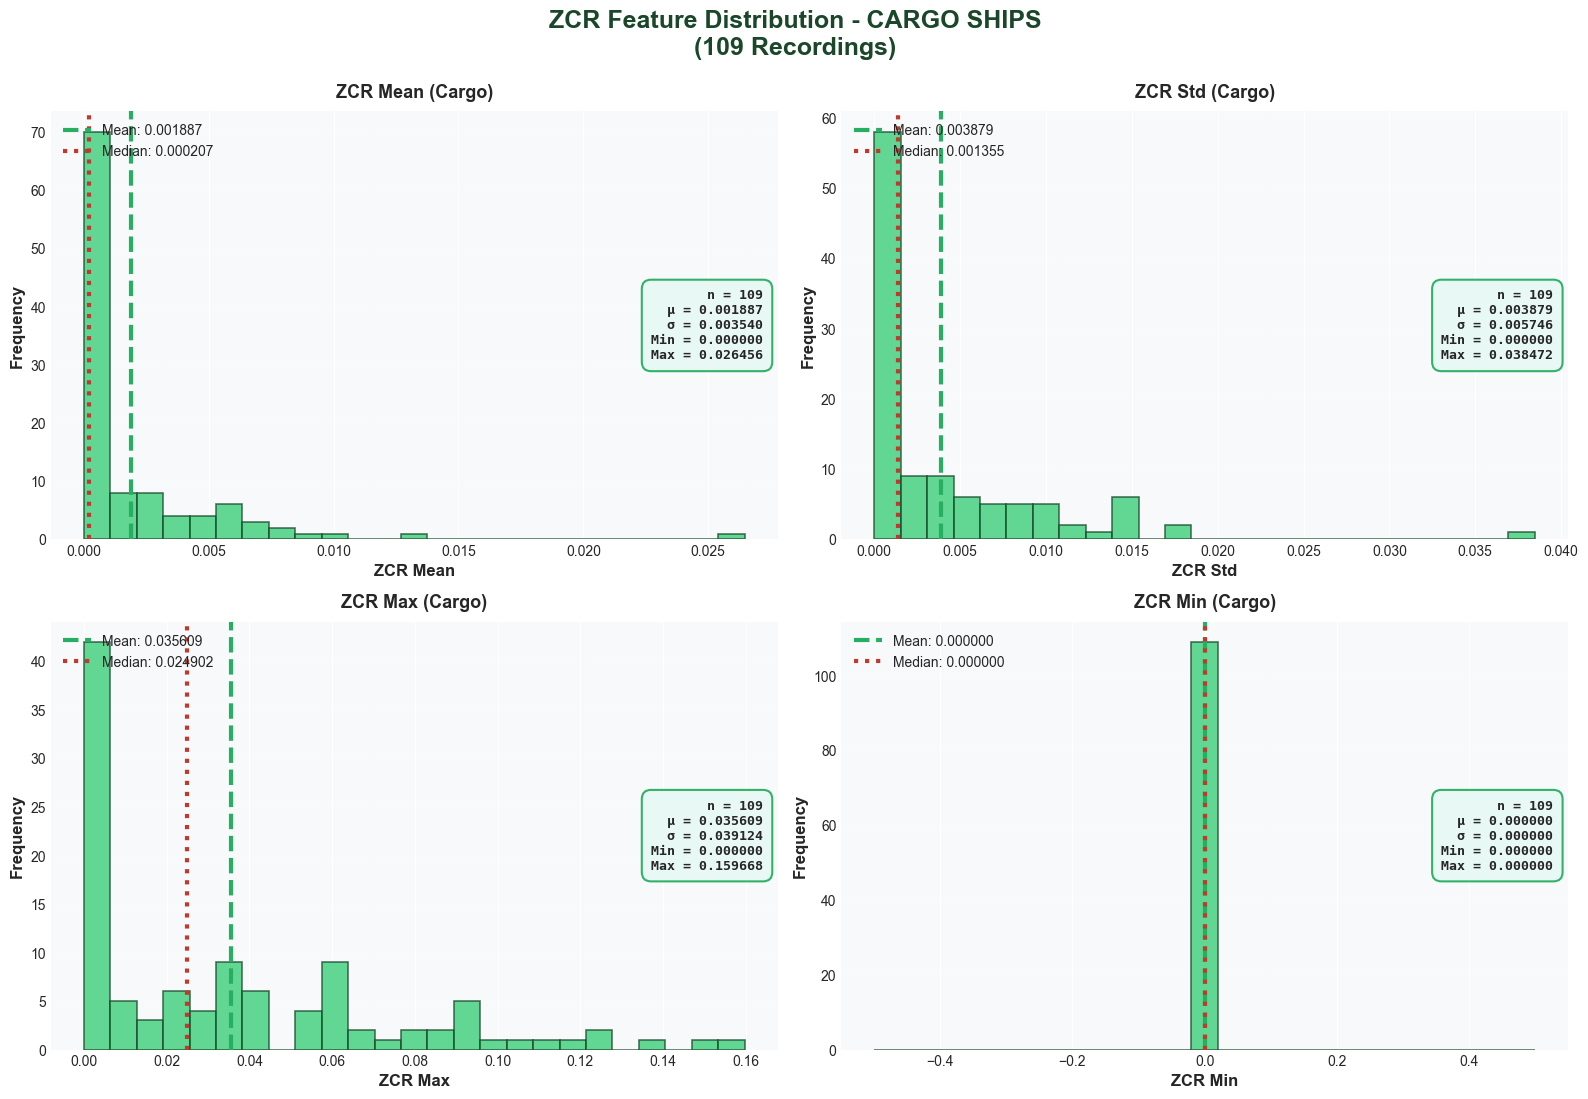


✓ CARGO HISTOGRAMS SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/22B_zcr_cargo_histograms.png

✓ CARGO ZCR STATISTICS:
  ZCR Mean: μ=0.001887, σ=0.003540
  ZCR Std: μ=0.003879, σ=0.005746
  ZCR Max: μ=0.035609, σ=0.039124
  ZCR Min: μ=0.000000, σ=0.000000



In [5]:
# Cell 22B: ZCR Cargo Histograms (Enhanced Visualization - Fixed Layout)
# Purpose: Show ZCR feature distribution for Cargo ships only
# Enhanced: Better colors, fonts, layout - Statistics boxes middle-right

print("\n" + "="*80)
print("CELL 22B: ZCR CARGO HISTOGRAMS")
print("="*80)

if 'df_zcr' not in locals():
    print("⚠️ ERROR: df_zcr not found. Run Cell 22 first.")
else:
    print(f"\n✓ ZCR CARGO DATA ANALYSIS:")
    cargo_zcr = df_zcr[df_zcr['class'] == 'Cargo']
    print(f"  Total Cargo recordings: {len(cargo_zcr)}")
    
    # Create figure with enhanced styling
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle('ZCR Feature Distribution - CARGO SHIPS\n(109 Recordings)', 
                 fontsize=18, fontweight='bold', color='#1a472a', y=0.995)
    
    # Color scheme
    bar_color = '#2ecc71'
    mean_color = '#27ae60'
    median_color = '#c0392b'
    
    # ============================================================
    # SUBPLOT 1: ZCR Mean
    # ============================================================
    ax1 = axes[0, 0]
    cargo_zcr_mean = cargo_zcr['zcr_mean'].values
    
    ax1.hist(cargo_zcr_mean, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#1a472a', linewidth=1.2)
    ax1.axvline(cargo_zcr_mean.mean(), color=mean_color, linestyle='--', 
                linewidth=3, label=f'Mean: {cargo_zcr_mean.mean():.6f}', zorder=5)
    ax1.axvline(np.median(cargo_zcr_mean), color=median_color, linestyle=':', 
                linewidth=3, label=f'Median: {np.median(cargo_zcr_mean):.6f}', zorder=5)
    
    ax1.set_xlabel('ZCR Mean', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax1.set_title('ZCR Mean (Cargo)', fontweight='bold', fontsize=13, pad=10)
    ax1.legend(fontsize=10, loc='upper left', framealpha=0.95)
    ax1.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax1.set_facecolor('#f8f9fa')
    
    # Statistics box - middle right
    stats_text1 = f"n = {len(cargo_zcr_mean)}\nμ = {cargo_zcr_mean.mean():.6f}\nσ = {cargo_zcr_mean.std():.6f}\nMin = {cargo_zcr_mean.min():.6f}\nMax = {cargo_zcr_mean.max():.6f}"
    ax1.text(0.98, 0.50, stats_text1, transform=ax1.transAxes, fontsize=9.5, 
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.7', facecolor='#e8f8f5', 
                      edgecolor='#27ae60', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 2: ZCR Std
    # ============================================================
    ax2 = axes[0, 1]
    cargo_zcr_std = cargo_zcr['zcr_std'].values
    
    ax2.hist(cargo_zcr_std, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#1a472a', linewidth=1.2)
    ax2.axvline(cargo_zcr_std.mean(), color=mean_color, linestyle='--', 
                linewidth=3, label=f'Mean: {cargo_zcr_std.mean():.6f}', zorder=5)
    ax2.axvline(np.median(cargo_zcr_std), color=median_color, linestyle=':', 
                linewidth=3, label=f'Median: {np.median(cargo_zcr_std):.6f}', zorder=5)
    
    ax2.set_xlabel('ZCR Std', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax2.set_title('ZCR Std (Cargo)', fontweight='bold', fontsize=13, pad=10)
    ax2.legend(fontsize=10, loc='upper left', framealpha=0.95)
    ax2.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax2.set_facecolor('#f8f9fa')
    
    # Statistics box - middle right
    stats_text2 = f"n = {len(cargo_zcr_std)}\nμ = {cargo_zcr_std.mean():.6f}\nσ = {cargo_zcr_std.std():.6f}\nMin = {cargo_zcr_std.min():.6f}\nMax = {cargo_zcr_std.max():.6f}"
    ax2.text(0.98, 0.50, stats_text2, transform=ax2.transAxes, fontsize=9.5, 
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.7', facecolor='#e8f8f5', 
                      edgecolor='#27ae60', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 3: ZCR Max
    # ============================================================
    ax3 = axes[1, 0]
    cargo_zcr_max = cargo_zcr['zcr_max'].values
    
    ax3.hist(cargo_zcr_max, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#1a472a', linewidth=1.2)
    ax3.axvline(cargo_zcr_max.mean(), color=mean_color, linestyle='--', 
                linewidth=3, label=f'Mean: {cargo_zcr_max.mean():.6f}', zorder=5)
    ax3.axvline(np.median(cargo_zcr_max), color=median_color, linestyle=':', 
                linewidth=3, label=f'Median: {np.median(cargo_zcr_max):.6f}', zorder=5)
    
    ax3.set_xlabel('ZCR Max', fontweight='bold', fontsize=12)
    ax3.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax3.set_title('ZCR Max (Cargo)', fontweight='bold', fontsize=13, pad=10)
    ax3.legend(fontsize=10, loc='upper left', framealpha=0.95)
    ax3.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax3.set_facecolor('#f8f9fa')
    
    # Statistics box - middle right
    stats_text3 = f"n = {len(cargo_zcr_max)}\nμ = {cargo_zcr_max.mean():.6f}\nσ = {cargo_zcr_max.std():.6f}\nMin = {cargo_zcr_max.min():.6f}\nMax = {cargo_zcr_max.max():.6f}"
    ax3.text(0.98, 0.50, stats_text3, transform=ax3.transAxes, fontsize=9.5, 
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.7', facecolor='#e8f8f5', 
                      edgecolor='#27ae60', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 4: ZCR Min
    # ============================================================
    ax4 = axes[1, 1]
    cargo_zcr_min = cargo_zcr['zcr_min'].values
    
    ax4.hist(cargo_zcr_min, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#1a472a', linewidth=1.2)
    ax4.axvline(cargo_zcr_min.mean(), color=mean_color, linestyle='--', 
                linewidth=3, label=f'Mean: {cargo_zcr_min.mean():.6f}', zorder=5)
    ax4.axvline(np.median(cargo_zcr_min), color=median_color, linestyle=':', 
                linewidth=3, label=f'Median: {np.median(cargo_zcr_min):.6f}', zorder=5)
    
    ax4.set_xlabel('ZCR Min', fontweight='bold', fontsize=12)
    ax4.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax4.set_title('ZCR Min (Cargo)', fontweight='bold', fontsize=13, pad=10)
    ax4.legend(fontsize=10, loc='upper left', framealpha=0.95)
    ax4.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax4.set_facecolor('#f8f9fa')
    
    # Statistics box - middle right
    stats_text4 = f"n = {len(cargo_zcr_min)}\nμ = {cargo_zcr_min.mean():.6f}\nσ = {cargo_zcr_min.std():.6f}\nMin = {cargo_zcr_min.min():.6f}\nMax = {cargo_zcr_min.max():.6f}"
    ax4.text(0.98, 0.50, stats_text4, transform=ax4.transAxes, fontsize=9.5, 
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.7', facecolor='#e8f8f5', 
                      edgecolor='#27ae60', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/22B_zcr_cargo_histograms.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ CARGO HISTOGRAMS SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/22B_zcr_cargo_histograms.png")
    print(f"\n✓ CARGO ZCR STATISTICS:")
    print(f"  ZCR Mean: μ={cargo_zcr_mean.mean():.6f}, σ={cargo_zcr_mean.std():.6f}")
    print(f"  ZCR Std: μ={cargo_zcr_std.mean():.6f}, σ={cargo_zcr_std.std():.6f}")
    print(f"  ZCR Max: μ={cargo_zcr_max.mean():.6f}, σ={cargo_zcr_max.std():.6f}")
    print(f"  ZCR Min: μ={cargo_zcr_min.mean():.6f}, σ={cargo_zcr_min.std():.6f}")

print("\n" + "="*80)


CELL 22C: ZCR PASSENGER HISTOGRAMS

✓ ZCR PASSENGER DATA ANALYSIS:
  Total Passenger recordings: 185


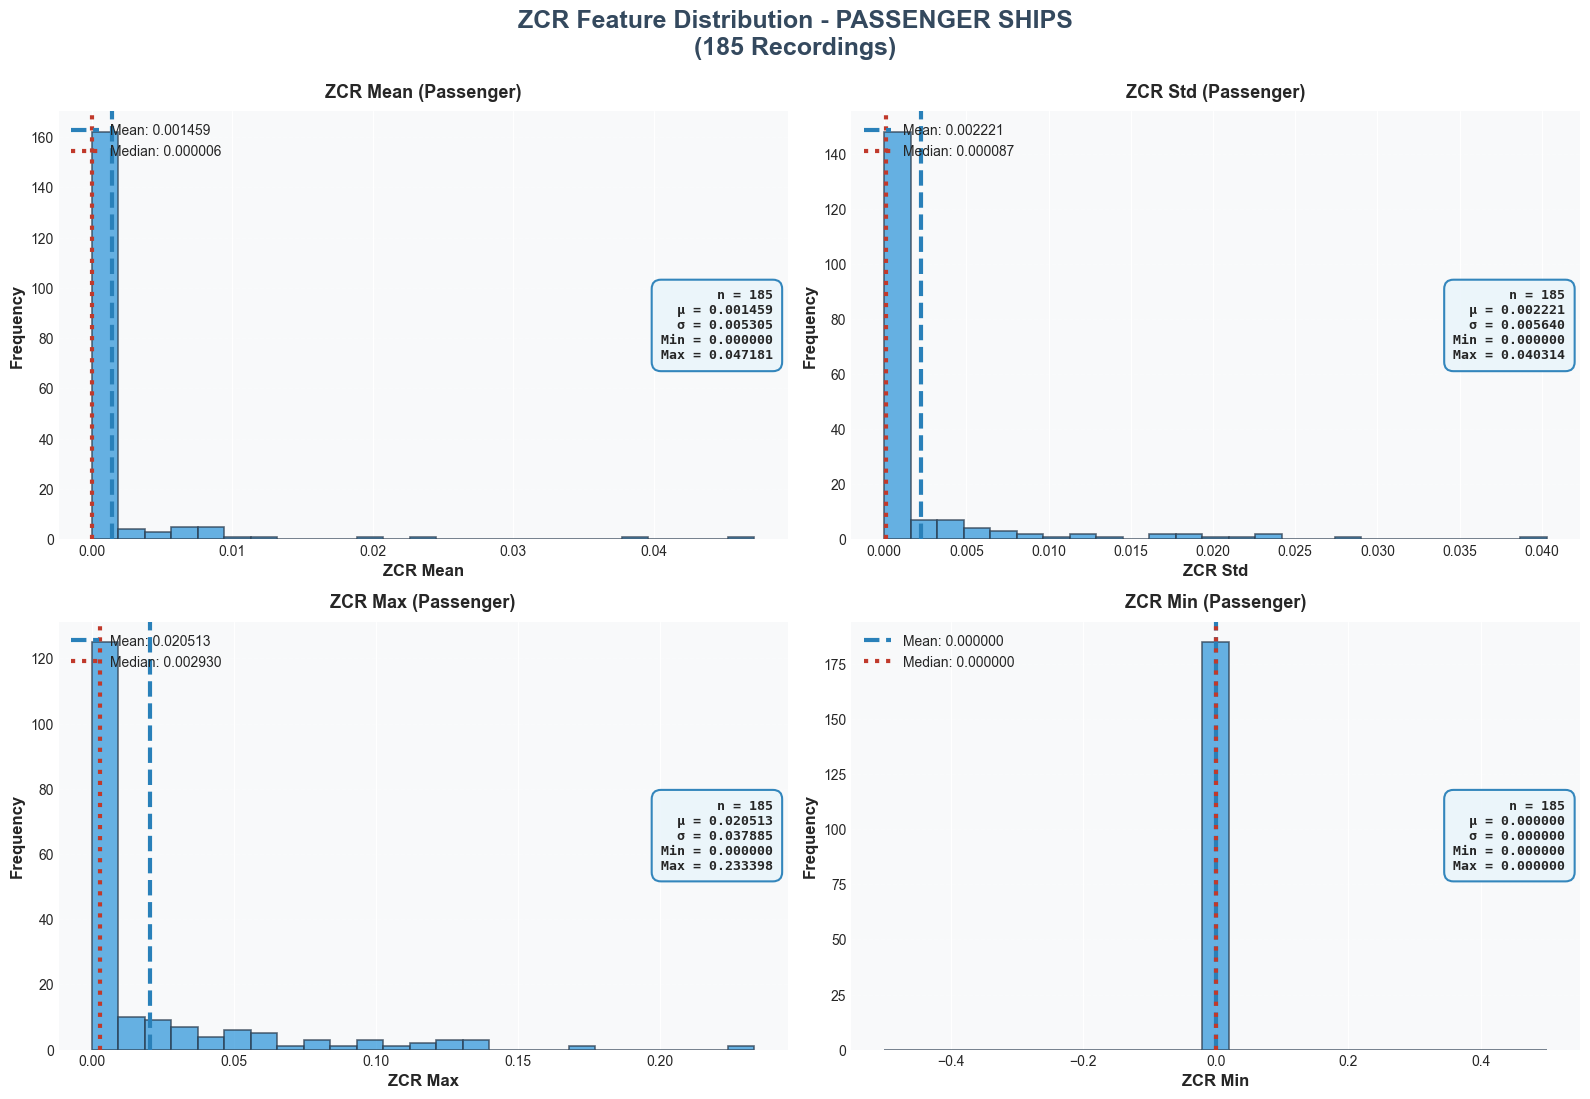


✓ PASSENGER HISTOGRAMS SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/22C_zcr_passenger_histograms.png

✓ PASSENGER ZCR STATISTICS:
  ZCR Mean: μ=0.001459, σ=0.005305
  ZCR Std: μ=0.002221, σ=0.005640
  ZCR Max: μ=0.020513, σ=0.037885
  ZCR Min: μ=0.000000, σ=0.000000



In [6]:
# Cell 22C: ZCR Passenger Histograms (Enhanced Visualization)
# Purpose: Show ZCR feature distribution for Passenger ships only
# Enhanced: Better colors, fonts, layout - Statistics boxes middle-right

print("\n" + "="*80)
print("CELL 22C: ZCR PASSENGER HISTOGRAMS")
print("="*80)

if 'df_zcr' not in locals():
    print("⚠️ ERROR: df_zcr not found. Run Cell 22 first.")
else:
    print(f"\n✓ ZCR PASSENGER DATA ANALYSIS:")
    passenger_zcr = df_zcr[df_zcr['class'] == 'Passenger']
    print(f"  Total Passenger recordings: {len(passenger_zcr)}")
    
    # Create figure with enhanced styling
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle('ZCR Feature Distribution - PASSENGER SHIPS\n(185 Recordings)', 
                 fontsize=18, fontweight='bold', color='#34495e', y=0.995)
    
    # Color scheme - Passenger (from Cell 12)
    bar_color = '#3498db'
    mean_color = '#2980b9'
    median_color = '#c0392b'
    
    # ============================================================
    # SUBPLOT 1: ZCR Mean
    # ============================================================
    ax1 = axes[0, 0]
    passenger_zcr_mean = passenger_zcr['zcr_mean'].values
    
    ax1.hist(passenger_zcr_mean, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#2c3e50', linewidth=1.2)
    ax1.axvline(passenger_zcr_mean.mean(), color=mean_color, linestyle='--', 
                linewidth=3, label=f'Mean: {passenger_zcr_mean.mean():.6f}', zorder=5)
    ax1.axvline(np.median(passenger_zcr_mean), color=median_color, linestyle=':', 
                linewidth=3, label=f'Median: {np.median(passenger_zcr_mean):.6f}', zorder=5)
    
    ax1.set_xlabel('ZCR Mean', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax1.set_title('ZCR Mean (Passenger)', fontweight='bold', fontsize=13, pad=10)
    ax1.legend(fontsize=10, loc='upper left', framealpha=0.95)
    ax1.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax1.set_facecolor('#f8f9fa')
    
    # Statistics box - middle right
    stats_text1 = f"n = {len(passenger_zcr_mean)}\nμ = {passenger_zcr_mean.mean():.6f}\nσ = {passenger_zcr_mean.std():.6f}\nMin = {passenger_zcr_mean.min():.6f}\nMax = {passenger_zcr_mean.max():.6f}"
    ax1.text(0.98, 0.50, stats_text1, transform=ax1.transAxes, fontsize=9.5, 
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.7', facecolor='#ebf5fb', 
                      edgecolor='#2980b9', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 2: ZCR Std
    # ============================================================
    ax2 = axes[0, 1]
    passenger_zcr_std = passenger_zcr['zcr_std'].values
    
    ax2.hist(passenger_zcr_std, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#2c3e50', linewidth=1.2)
    ax2.axvline(passenger_zcr_std.mean(), color=mean_color, linestyle='--', 
                linewidth=3, label=f'Mean: {passenger_zcr_std.mean():.6f}', zorder=5)
    ax2.axvline(np.median(passenger_zcr_std), color=median_color, linestyle=':', 
                linewidth=3, label=f'Median: {np.median(passenger_zcr_std):.6f}', zorder=5)
    
    ax2.set_xlabel('ZCR Std', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax2.set_title('ZCR Std (Passenger)', fontweight='bold', fontsize=13, pad=10)
    ax2.legend(fontsize=10, loc='upper left', framealpha=0.95)
    ax2.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax2.set_facecolor('#f8f9fa')
    
    # Statistics box - middle right
    stats_text2 = f"n = {len(passenger_zcr_std)}\nμ = {passenger_zcr_std.mean():.6f}\nσ = {passenger_zcr_std.std():.6f}\nMin = {passenger_zcr_std.min():.6f}\nMax = {passenger_zcr_std.max():.6f}"
    ax2.text(0.98, 0.50, stats_text2, transform=ax2.transAxes, fontsize=9.5, 
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.7', facecolor='#ebf5fb', 
                      edgecolor='#2980b9', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 3: ZCR Max
    # ============================================================
    ax3 = axes[1, 0]
    passenger_zcr_max = passenger_zcr['zcr_max'].values
    
    ax3.hist(passenger_zcr_max, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#2c3e50', linewidth=1.2)
    ax3.axvline(passenger_zcr_max.mean(), color=mean_color, linestyle='--', 
                linewidth=3, label=f'Mean: {passenger_zcr_max.mean():.6f}', zorder=5)
    ax3.axvline(np.median(passenger_zcr_max), color=median_color, linestyle=':', 
                linewidth=3, label=f'Median: {np.median(passenger_zcr_max):.6f}', zorder=5)
    
    ax3.set_xlabel('ZCR Max', fontweight='bold', fontsize=12)
    ax3.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax3.set_title('ZCR Max (Passenger)', fontweight='bold', fontsize=13, pad=10)
    ax3.legend(fontsize=10, loc='upper left', framealpha=0.95)
    ax3.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax3.set_facecolor('#f8f9fa')
    
    # Statistics box - middle right
    stats_text3 = f"n = {len(passenger_zcr_max)}\nμ = {passenger_zcr_max.mean():.6f}\nσ = {passenger_zcr_max.std():.6f}\nMin = {passenger_zcr_max.min():.6f}\nMax = {passenger_zcr_max.max():.6f}"
    ax3.text(0.98, 0.50, stats_text3, transform=ax3.transAxes, fontsize=9.5, 
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.7', facecolor='#ebf5fb', 
                      edgecolor='#2980b9', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 4: ZCR Min
    # ============================================================
    ax4 = axes[1, 1]
    passenger_zcr_min = passenger_zcr['zcr_min'].values
    
    ax4.hist(passenger_zcr_min, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#2c3e50', linewidth=1.2)
    ax4.axvline(passenger_zcr_min.mean(), color=mean_color, linestyle='--', 
                linewidth=3, label=f'Mean: {passenger_zcr_min.mean():.6f}', zorder=5)
    ax4.axvline(np.median(passenger_zcr_min), color=median_color, linestyle=':', 
                linewidth=3, label=f'Median: {np.median(passenger_zcr_min):.6f}', zorder=5)
    
    ax4.set_xlabel('ZCR Min', fontweight='bold', fontsize=12)
    ax4.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax4.set_title('ZCR Min (Passenger)', fontweight='bold', fontsize=13, pad=10)
    ax4.legend(fontsize=10, loc='upper left', framealpha=0.95)
    ax4.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax4.set_facecolor('#f8f9fa')
    
    # Statistics box - middle right
    stats_text4 = f"n = {len(passenger_zcr_min)}\nμ = {passenger_zcr_min.mean():.6f}\nσ = {passenger_zcr_min.std():.6f}\nMin = {passenger_zcr_min.min():.6f}\nMax = {passenger_zcr_min.max():.6f}"
    ax4.text(0.98, 0.50, stats_text4, transform=ax4.transAxes, fontsize=9.5, 
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.7', facecolor='#ebf5fb', 
                      edgecolor='#2980b9', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/22C_zcr_passenger_histograms.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ PASSENGER HISTOGRAMS SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/22C_zcr_passenger_histograms.png")
    print(f"\n✓ PASSENGER ZCR STATISTICS:")
    print(f"  ZCR Mean: μ={passenger_zcr_mean.mean():.6f}, σ={passenger_zcr_mean.std():.6f}")
    print(f"  ZCR Std: μ={passenger_zcr_std.mean():.6f}, σ={passenger_zcr_std.std():.6f}")
    print(f"  ZCR Max: μ={passenger_zcr_max.mean():.6f}, σ={passenger_zcr_max.std():.6f}")
    print(f"  ZCR Min: μ={passenger_zcr_min.mean():.6f}, σ={passenger_zcr_min.std():.6f}")

print("\n" + "="*80)


CELL 22D: ZCR COMBINED HISTOGRAMS (CARGO vs PASSENGER)

✓ ZCR COMBINED DATA ANALYSIS:
  Cargo recordings: 109
  Passenger recordings: 185


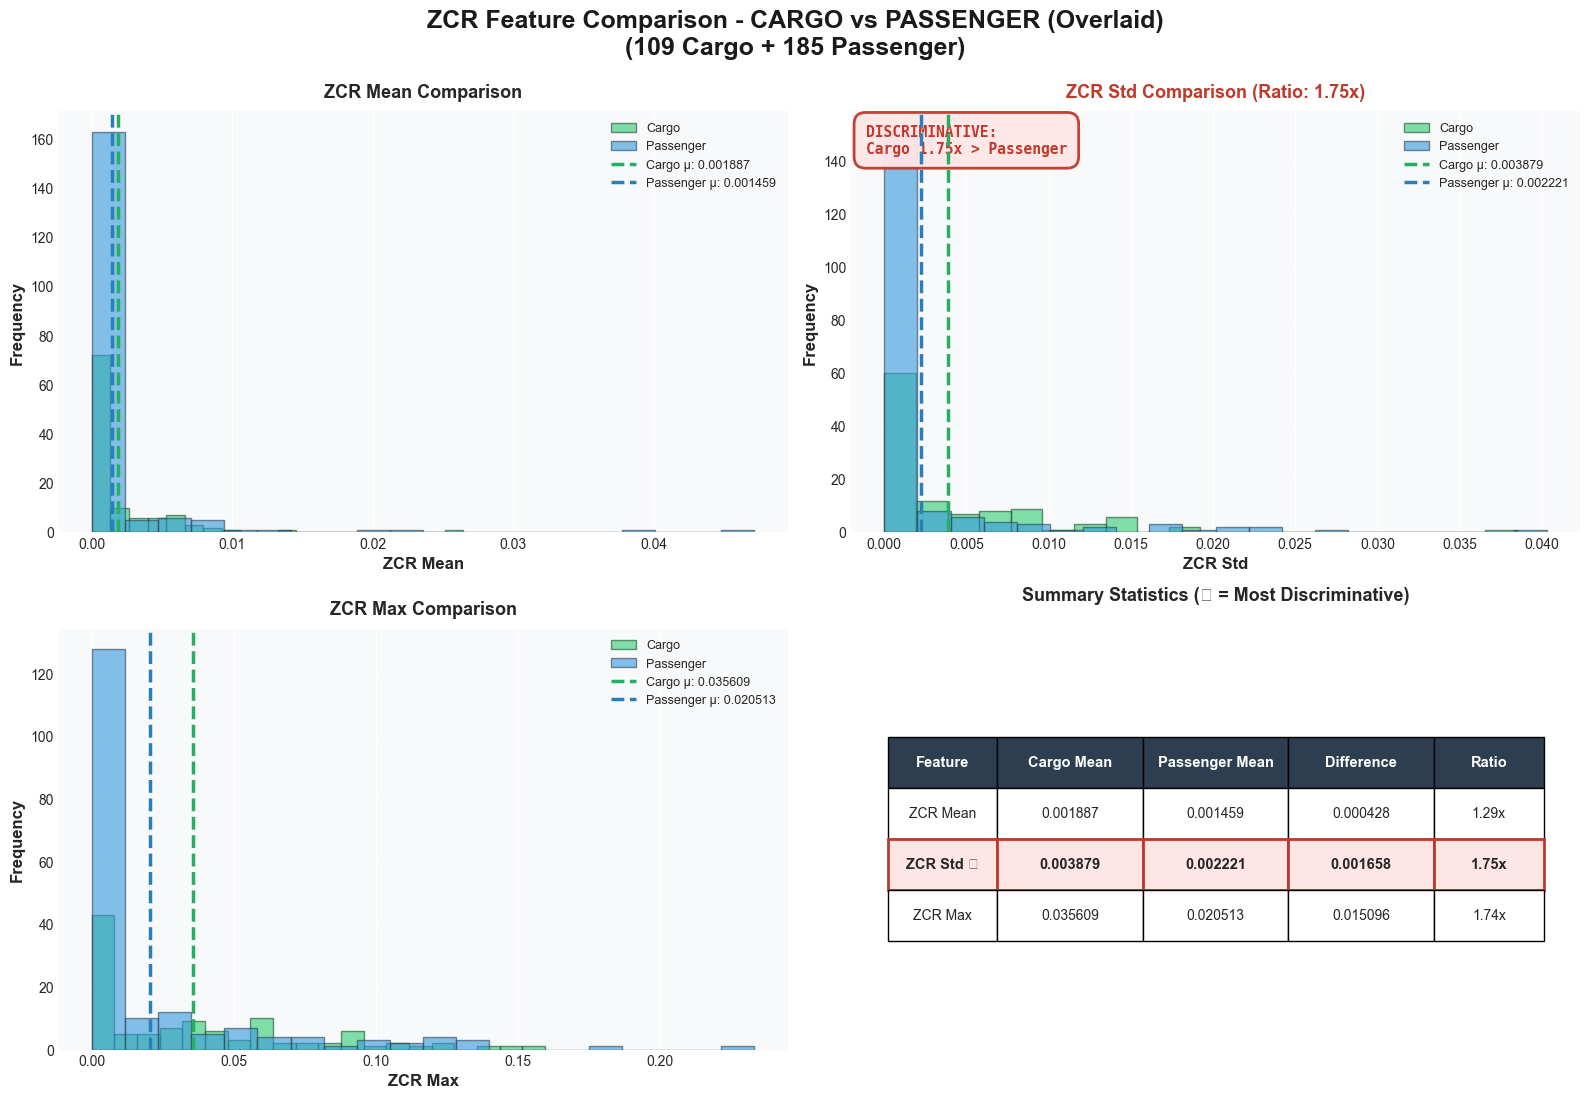


✓ COMBINED HISTOGRAMS SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/22D_zcr_combined_histograms.png

✓ ZCR COMPARISON SUMMARY:
  ZCR Mean Ratio (Cargo/Passenger): 1.29x
  ZCR Std Ratio (Cargo/Passenger): 1.75x ★ DISCRIMINATIVE
  ZCR Max Ratio (Cargo/Passenger): 1.74x



In [7]:
# Cell 22D: ZCR Combined Histograms (Both Classes Overlaid)
# Purpose: Compare ZCR feature distributions between Cargo and Passenger
# Enhanced: Better colors, fonts, layout

print("\n" + "="*80)
print("CELL 22D: ZCR COMBINED HISTOGRAMS (CARGO vs PASSENGER)")
print("="*80)

if 'df_zcr' not in locals():
    print("⚠️ ERROR: df_zcr not found. Run Cell 22 first.")
else:
    print(f"\n✓ ZCR COMBINED DATA ANALYSIS:")
    cargo_zcr = df_zcr[df_zcr['class'] == 'Cargo']
    passenger_zcr = df_zcr[df_zcr['class'] == 'Passenger']
    
    print(f"  Cargo recordings: {len(cargo_zcr)}")
    print(f"  Passenger recordings: {len(passenger_zcr)}")
    
    # Create figure with subplots for combined comparison
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle('ZCR Feature Comparison - CARGO vs PASSENGER (Overlaid)\n(109 Cargo + 185 Passenger)', 
                 fontsize=18, fontweight='bold', color='#1a1a1a', y=0.995)
    
    # Color scheme
    cargo_color = '#2ecc71'
    passenger_color = '#3498db'
    
    # ============================================================
    # SUBPLOT 1: ZCR Mean (Combined)
    # ============================================================
    ax1 = axes[0, 0]
    
    ax1.hist(cargo_zcr['zcr_mean'], bins=20, alpha=0.6, label='Cargo', 
             color=cargo_color, edgecolor='#1a472a', linewidth=1)
    ax1.hist(passenger_zcr['zcr_mean'], bins=20, alpha=0.6, label='Passenger', 
             color=passenger_color, edgecolor='#2c3e50', linewidth=1)
    
    ax1.axvline(cargo_zcr['zcr_mean'].mean(), color='#27ae60', linestyle='--', 
                linewidth=2.5, label=f'Cargo μ: {cargo_zcr["zcr_mean"].mean():.6f}', zorder=5)
    ax1.axvline(passenger_zcr['zcr_mean'].mean(), color='#2980b9', linestyle='--', 
                linewidth=2.5, label=f'Passenger μ: {passenger_zcr["zcr_mean"].mean():.6f}', zorder=5)
    
    ax1.set_xlabel('ZCR Mean', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax1.set_title('ZCR Mean Comparison', fontweight='bold', fontsize=13, pad=10)
    ax1.legend(fontsize=9, loc='upper right', framealpha=0.95)
    ax1.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax1.set_facecolor('#f8f9fa')
    
    # ============================================================
    # SUBPLOT 2: ZCR Std (Combined) - KEY FEATURE
    # ============================================================
    ax2 = axes[0, 1]
    
    ax2.hist(cargo_zcr['zcr_std'], bins=20, alpha=0.6, label='Cargo', 
             color=cargo_color, edgecolor='#1a472a', linewidth=1)
    ax2.hist(passenger_zcr['zcr_std'], bins=20, alpha=0.6, label='Passenger', 
             color=passenger_color, edgecolor='#2c3e50', linewidth=1)
    
    cargo_std_mean = cargo_zcr['zcr_std'].mean()
    passenger_std_mean = passenger_zcr['zcr_std'].mean()
    ratio_std = cargo_std_mean / passenger_std_mean
    
    ax2.axvline(cargo_std_mean, color='#27ae60', linestyle='--', 
                linewidth=2.5, label=f'Cargo μ: {cargo_std_mean:.6f}', zorder=5)
    ax2.axvline(passenger_std_mean, color='#2980b9', linestyle='--', 
                linewidth=2.5, label=f'Passenger μ: {passenger_std_mean:.6f}', zorder=5)
    
    ax2.set_xlabel('ZCR Std', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax2.set_title(f'ZCR Std Comparison (Ratio: {ratio_std:.2f}x)', 
                  fontweight='bold', fontsize=13, pad=10, color='#c0392b')
    ax2.legend(fontsize=9, loc='upper right', framealpha=0.95)
    ax2.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax2.set_facecolor('#f8f9fa')
    
    # Highlight box
    highlight_text = f'DISCRIMINATIVE:\nCargo {ratio_std:.2f}x > Passenger'
    ax2.text(0.02, 0.97, highlight_text, transform=ax2.transAxes, fontsize=10.5, 
             verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ffe6e6', 
                      edgecolor='#c0392b', linewidth=2, alpha=0.95), 
             family='monospace', fontweight='bold', color='#c0392b')
    
    # ============================================================
    # SUBPLOT 3: ZCR Max (Combined)
    # ============================================================
    ax3 = axes[1, 0]
    
    ax3.hist(cargo_zcr['zcr_max'], bins=20, alpha=0.6, label='Cargo', 
             color=cargo_color, edgecolor='#1a472a', linewidth=1)
    ax3.hist(passenger_zcr['zcr_max'], bins=20, alpha=0.6, label='Passenger', 
             color=passenger_color, edgecolor='#2c3e50', linewidth=1)
    
    ax3.axvline(cargo_zcr['zcr_max'].mean(), color='#27ae60', linestyle='--', 
                linewidth=2.5, label=f'Cargo μ: {cargo_zcr["zcr_max"].mean():.6f}', zorder=5)
    ax3.axvline(passenger_zcr['zcr_max'].mean(), color='#2980b9', linestyle='--', 
                linewidth=2.5, label=f'Passenger μ: {passenger_zcr["zcr_max"].mean():.6f}', zorder=5)
    
    ax3.set_xlabel('ZCR Max', fontweight='bold', fontsize=12)
    ax3.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax3.set_title('ZCR Max Comparison', fontweight='bold', fontsize=13, pad=10)
    ax3.legend(fontsize=9, loc='upper right', framealpha=0.95)
    ax3.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax3.set_facecolor('#f8f9fa')
    
    # ============================================================
    # SUBPLOT 4: Summary Statistics Table
    # ============================================================
    ax4 = axes[1, 1]
    ax4.axis('tight')
    ax4.axis('off')
    
    # Create summary statistics
    summary_data = [
        ['Feature', 'Cargo Mean', 'Passenger Mean', 'Difference', 'Ratio'],
        ['ZCR Mean', f"{cargo_zcr['zcr_mean'].mean():.6f}", 
         f"{passenger_zcr['zcr_mean'].mean():.6f}",
         f"{abs(cargo_zcr['zcr_mean'].mean() - passenger_zcr['zcr_mean'].mean()):.6f}",
         f"{cargo_zcr['zcr_mean'].mean() / passenger_zcr['zcr_mean'].mean():.2f}x"],
        ['ZCR Std ★', f"{cargo_std_mean:.6f}", 
         f"{passenger_std_mean:.6f}",
         f"{abs(cargo_std_mean - passenger_std_mean):.6f}",
         f"{ratio_std:.2f}x"],
        ['ZCR Max', f"{cargo_zcr['zcr_max'].mean():.6f}", 
         f"{passenger_zcr['zcr_max'].mean():.6f}",
         f"{abs(cargo_zcr['zcr_max'].mean() - passenger_zcr['zcr_max'].mean()):.6f}",
         f"{cargo_zcr['zcr_max'].mean() / passenger_zcr['zcr_max'].mean():.2f}x"],
    ]
    
    table = ax4.table(cellText=summary_data, cellLoc='center', loc='center',
                      colWidths=[0.15, 0.2, 0.2, 0.2, 0.15])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.8)
    
    # Style header row
    for i in range(5):
        table[(0, i)].set_facecolor('#2c3e50')
        table[(0, i)].set_text_props(weight='bold', color='white', fontsize=10.5)
    
    # Highlight ZCR Std row (most discriminative)
    for i in range(5):
        table[(2, i)].set_facecolor('#ffe6e6')
        table[(2, i)].set_text_props(weight='bold', fontsize=10.5)
        table[(2, i)].set_edgecolor('#c0392b')
        table[(2, i)].set_linewidth(2)
    
    # Alternate row colors for others
    for i in [1, 3]:
        for j in range(5):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#ecf0f1')
            else:
                table[(i, j)].set_facecolor('#ffffff')
    
    ax4.set_title('Summary Statistics (★ = Most Discriminative)', 
                  fontweight='bold', fontsize=13, pad=20)
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/22D_zcr_combined_histograms.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ COMBINED HISTOGRAMS SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/22D_zcr_combined_histograms.png")
    print(f"\n✓ ZCR COMPARISON SUMMARY:")
    print(f"  ZCR Mean Ratio (Cargo/Passenger): {cargo_zcr['zcr_mean'].mean() / passenger_zcr['zcr_mean'].mean():.2f}x")
    print(f"  ZCR Std Ratio (Cargo/Passenger): {ratio_std:.2f}x ★ DISCRIMINATIVE")
    print(f"  ZCR Max Ratio (Cargo/Passenger): {cargo_zcr['zcr_max'].mean() / passenger_zcr['zcr_max'].mean():.2f}x")

print("\n" + "="*80)


CELL 22E: ZCR BOXPLOT COMPARISON

✓ ZCR BOXPLOT DATA:
  Cargo recordings: 109
  Passenger recordings: 185


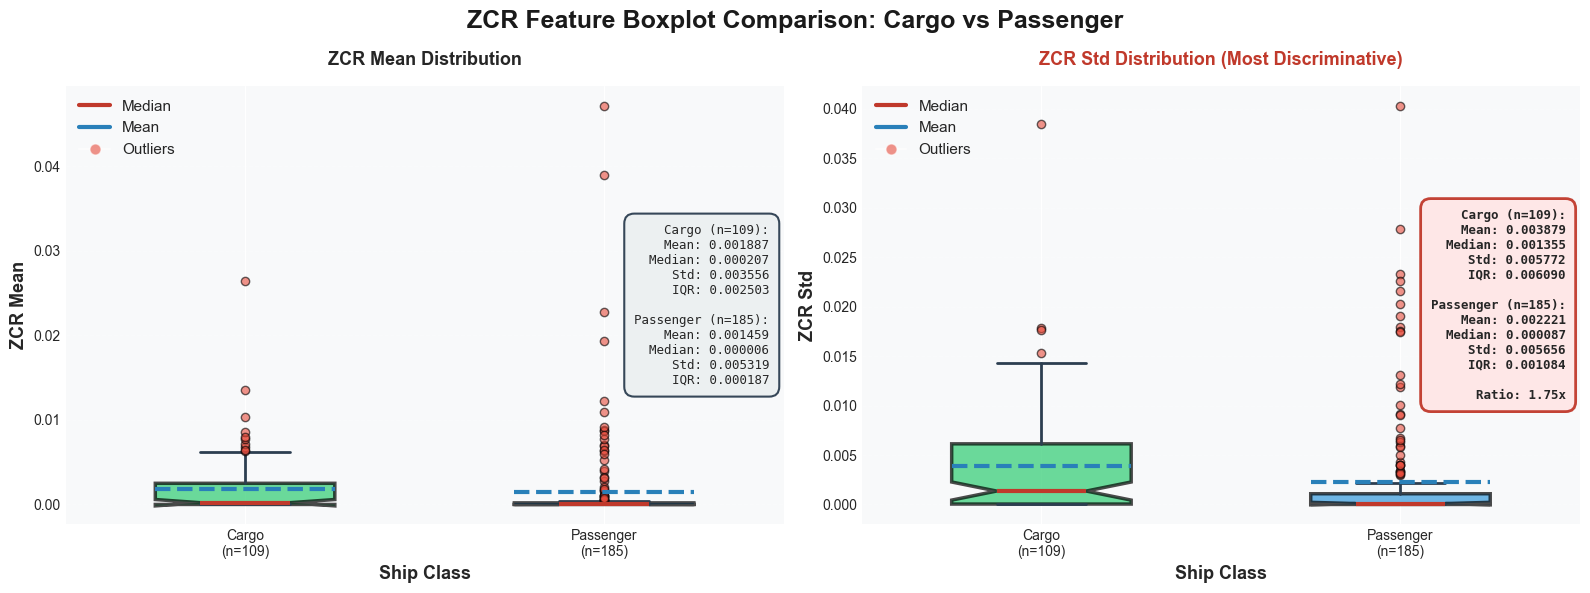


✓ BOXPLOT VISUALIZATION SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/22E_zcr_boxplot_comparison.png

✓ ZCR BOXPLOT SUMMARY:
  ZCR Mean - Cargo Median: 0.000207, Passenger Median: 0.000006
  ZCR Std - Cargo Median: 0.001355, Passenger Median: 0.000087
  ZCR Std Ratio (Cargo/Passenger): 1.75x ★ MOST DISCRIMINATIVE



In [8]:
# Cell 22E: ZCR Boxplot Comparison - Statistical Summary
# Purpose: Show ZCR feature distributions with quartiles and outliers
# Enhanced: Better styling and layout

print("\n" + "="*80)
print("CELL 22E: ZCR BOXPLOT COMPARISON")
print("="*80)

if 'df_zcr' not in locals():
    print("⚠️ ERROR: df_zcr not found. Run Cell 22 first.")
else:
    print(f"\n✓ ZCR BOXPLOT DATA:")
    cargo_zcr = df_zcr[df_zcr['class'] == 'Cargo']
    passenger_zcr = df_zcr[df_zcr['class'] == 'Passenger']
    
    print(f"  Cargo recordings: {len(cargo_zcr)}")
    print(f"  Passenger recordings: {len(passenger_zcr)}")
    
    # Create figure with boxplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle('ZCR Feature Boxplot Comparison: Cargo vs Passenger', 
                 fontsize=18, fontweight='bold', color='#1a1a1a', y=0.98)
    
    # Color scheme
    cargo_color = '#2ecc71'
    passenger_color = '#3498db'
    
    # ============================================================
    # BOXPLOT 1: ZCR MEAN
    # ============================================================
    ax1 = axes[0]
    
    bp1 = ax1.boxplot([cargo_zcr['zcr_mean'], passenger_zcr['zcr_mean']], 
                       labels=['Cargo\n(n=109)', 'Passenger\n(n=185)'],
                       patch_artist=True,
                       widths=0.5,
                       showmeans=True,
                       meanline=True,
                       notch=True)
    
    # Styling for Boxplot 1
    colors = [cargo_color, passenger_color]
    
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_linewidth(2.5)
        patch.set_alpha(0.7)
    
    for whisker in bp1['whiskers']:
        whisker.set_linewidth(2)
        whisker.set_color('#2c3e50')
    
    for cap in bp1['caps']:
        cap.set_linewidth(2)
        cap.set_color('#2c3e50')
    
    for median in bp1['medians']:
        median.set_color('#c0392b')
        median.set_linewidth(3)
    
    for mean in bp1['means']:
        mean.set_color('#2980b9')
        mean.set_linewidth(3)
    
    for flier in bp1['fliers']:
        flier.set_markerfacecolor('#e74c3c')
        flier.set_marker('o')
        flier.set_markersize=6
        flier.set_alpha(0.6)
    
    ax1.set_ylabel('ZCR Mean', fontweight='bold', fontsize=13)
    ax1.set_xlabel('Ship Class', fontweight='bold', fontsize=13)
    ax1.set_title('ZCR Mean Distribution', fontweight='bold', fontsize=13, pad=15)
    ax1.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax1.set_facecolor('#f8f9fa')
    
    # Add statistics text for ZCR Mean
    cargo_mean_val = cargo_zcr['zcr_mean'].mean()
    passenger_mean_val = passenger_zcr['zcr_mean'].mean()
    cargo_median_val = cargo_zcr['zcr_mean'].median()
    passenger_median_val = passenger_zcr['zcr_mean'].median()
    
    stats_text1 = (
        f"Cargo (n=109):\n"
        f"  Mean: {cargo_mean_val:.6f}\n"
        f"  Median: {cargo_median_val:.6f}\n"
        f"  Std: {cargo_zcr['zcr_mean'].std():.6f}\n"
        f"  IQR: {cargo_zcr['zcr_mean'].quantile(0.75) - cargo_zcr['zcr_mean'].quantile(0.25):.6f}\n\n"
        f"Passenger (n=185):\n"
        f"  Mean: {passenger_mean_val:.6f}\n"
        f"  Median: {passenger_median_val:.6f}\n"
        f"  Std: {passenger_zcr['zcr_mean'].std():.6f}\n"
        f"  IQR: {passenger_zcr['zcr_mean'].quantile(0.75) - passenger_zcr['zcr_mean'].quantile(0.25):.6f}"
    )
    
    ax1.text(0.98, 0.50, stats_text1, transform=ax1.transAxes,
             fontsize=9, verticalalignment='center', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ecf0f1', 
                      edgecolor='#2c3e50', linewidth=1.5, alpha=0.95),
             family='monospace')
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='#c0392b', lw=3, label='Median'),
        Line2D([0], [0], color='#2980b9', lw=3, label='Mean'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', 
               markersize=8, label='Outliers', alpha=0.6)
    ]
    ax1.legend(handles=legend_elements, fontsize=11, loc='upper left', framealpha=0.95)
    
    # ============================================================
    # BOXPLOT 2: ZCR STD (MOST DISCRIMINATIVE!)
    # ============================================================
    ax2 = axes[1]
    
    bp2 = ax2.boxplot([cargo_zcr['zcr_std'], passenger_zcr['zcr_std']], 
                       labels=['Cargo\n(n=109)', 'Passenger\n(n=185)'],
                       patch_artist=True,
                       widths=0.5,
                       showmeans=True,
                       meanline=True,
                       notch=True)
    
    # Styling for Boxplot 2
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_linewidth(2.5)
        patch.set_alpha(0.7)
    
    for whisker in bp2['whiskers']:
        whisker.set_linewidth(2)
        whisker.set_color('#2c3e50')
    
    for cap in bp2['caps']:
        cap.set_linewidth(2)
        cap.set_color('#2c3e50')
    
    for median in bp2['medians']:
        median.set_color('#c0392b')
        median.set_linewidth(3)
    
    for mean in bp2['means']:
        mean.set_color('#2980b9')
        mean.set_linewidth(3)
    
    for flier in bp2['fliers']:
        flier.set_markerfacecolor('#e74c3c')
        flier.set_marker('o')
        flier.set_markersize(6)
        flier.set_alpha(0.6)
    
    ax2.set_ylabel('ZCR Std', fontweight='bold', fontsize=13)
    ax2.set_xlabel('Ship Class', fontweight='bold', fontsize=13)
    ax2.set_title('ZCR Std Distribution (Most Discriminative)', fontweight='bold', 
                  fontsize=13, pad=15, color='#c0392b')
    ax2.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax2.set_facecolor('#f8f9fa')
    
    # Add statistics text for ZCR Std
    cargo_std_val = cargo_zcr['zcr_std'].mean()
    passenger_std_val = passenger_zcr['zcr_std'].mean()
    cargo_std_median = cargo_zcr['zcr_std'].median()
    passenger_std_median = passenger_zcr['zcr_std'].median()
    ratio = cargo_std_val / passenger_std_val
    
    stats_text2 = (
        f"Cargo (n=109):\n"
        f"  Mean: {cargo_std_val:.6f}\n"
        f"  Median: {cargo_std_median:.6f}\n"
        f"  Std: {cargo_zcr['zcr_std'].std():.6f}\n"
        f"  IQR: {cargo_zcr['zcr_std'].quantile(0.75) - cargo_zcr['zcr_std'].quantile(0.25):.6f}\n\n"
        f"Passenger (n=185):\n"
        f"  Mean: {passenger_std_val:.6f}\n"
        f"  Median: {passenger_std_median:.6f}\n"
        f"  Std: {passenger_zcr['zcr_std'].std():.6f}\n"
        f"  IQR: {passenger_zcr['zcr_std'].quantile(0.75) - passenger_zcr['zcr_std'].quantile(0.25):.6f}\n\n"
        f"Ratio: {ratio:.2f}x"
    )
    
    ax2.text(0.98, 0.50, stats_text2, transform=ax2.transAxes,
             fontsize=9, verticalalignment='center', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ffe6e6', 
                      edgecolor='#c0392b', linewidth=2, alpha=0.95),
             family='monospace', fontweight='bold')
    
    ax2.legend(handles=legend_elements, fontsize=11, loc='upper left', framealpha=0.95)
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/22E_zcr_boxplot_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ BOXPLOT VISUALIZATION SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/22E_zcr_boxplot_comparison.png")
    print(f"\n✓ ZCR BOXPLOT SUMMARY:")
    print(f"  ZCR Mean - Cargo Median: {cargo_zcr['zcr_mean'].median():.6f}, Passenger Median: {passenger_zcr['zcr_mean'].median():.6f}")
    print(f"  ZCR Std - Cargo Median: {cargo_zcr['zcr_std'].median():.6f}, Passenger Median: {passenger_zcr['zcr_std'].median():.6f}")
    print(f"  ZCR Std Ratio (Cargo/Passenger): {ratio:.2f}x ★ MOST DISCRIMINATIVE")

print("\n" + "="*80)


CELL 22E: ZCR BOXPLOT COMPARISON

✓ ZCR BOXPLOT DATA:
  Cargo recordings: 109
  Passenger recordings: 185


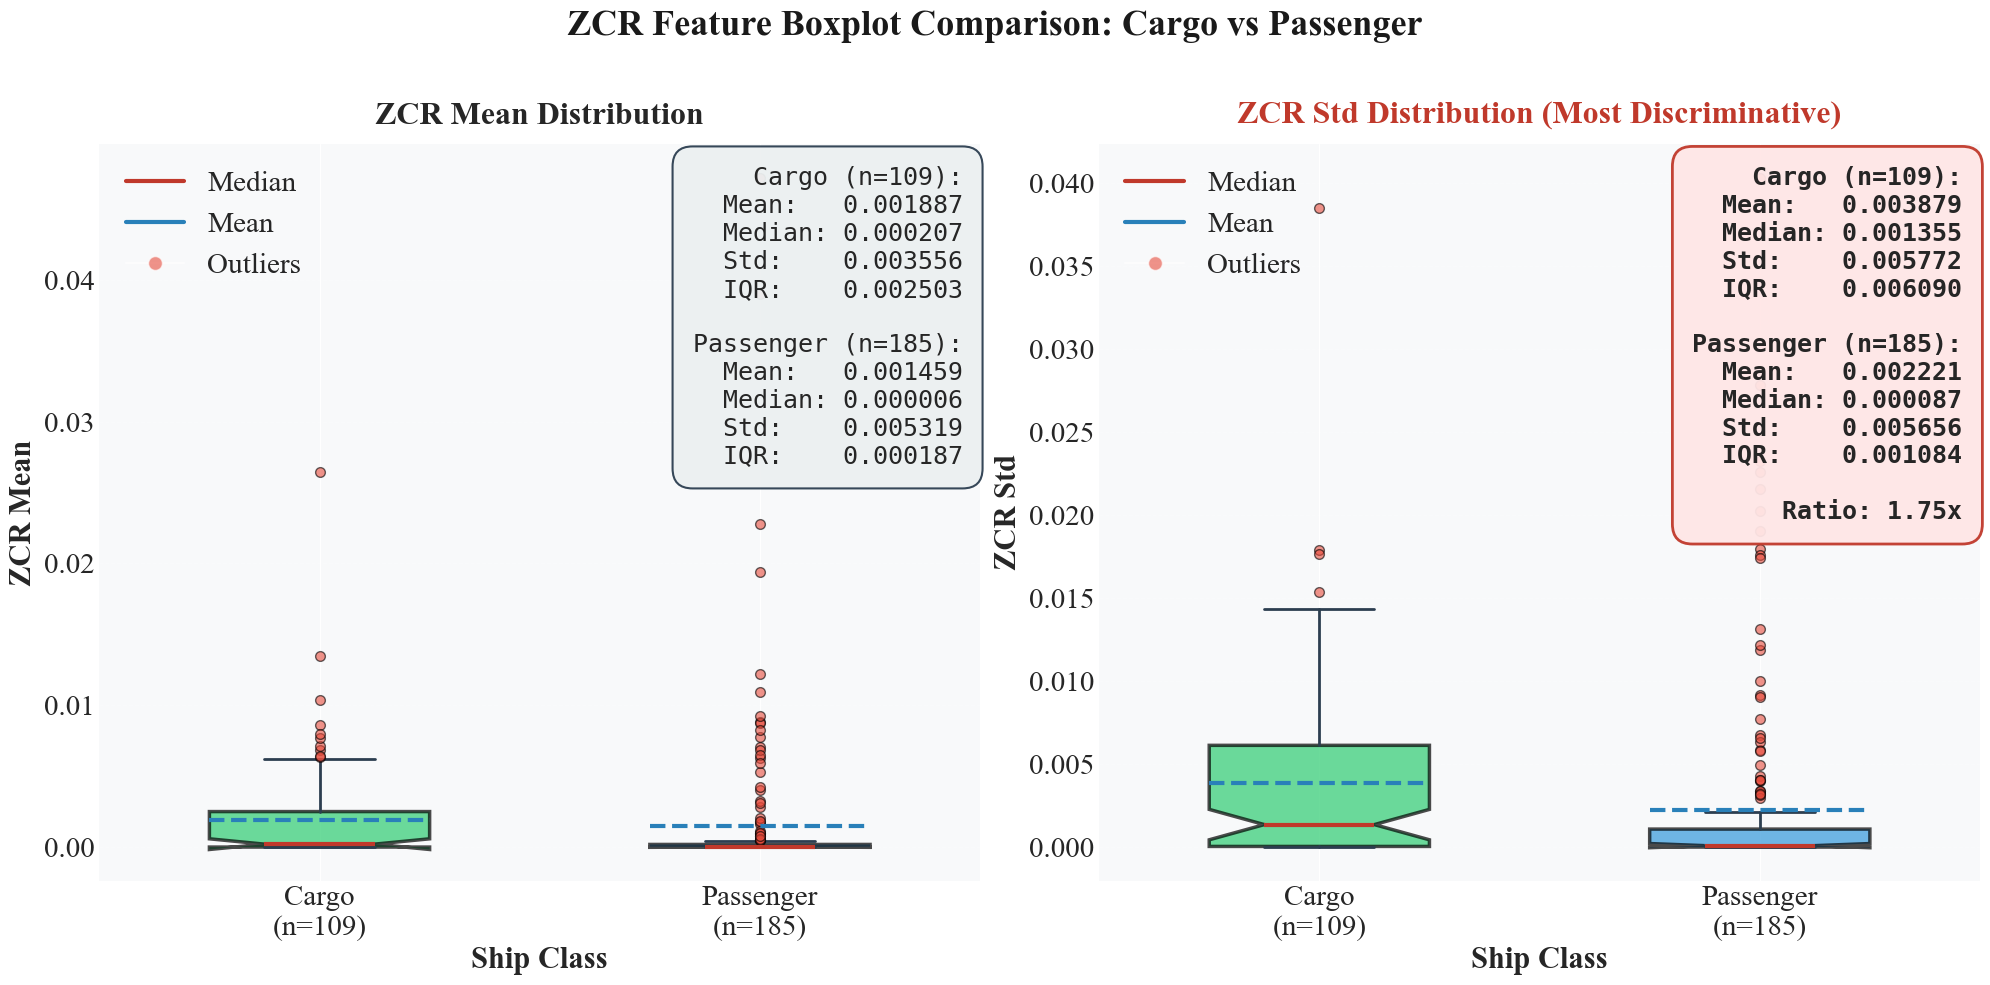


✓ BOXPLOT VISUALIZATION SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/22E_zcr_boxplot_comparison.png

✓ ZCR BOXPLOT SUMMARY:
  ZCR Mean - Cargo Median: 0.000207, Passenger Median: 0.000006
  ZCR Std  - Cargo Median: 0.001355, Passenger Median: 0.000087
  ZCR Std Ratio (Cargo/Passenger): 1.75x ★ MOST DISCRIMINATIVE



In [9]:
# Cell 22E: ZCR Boxplot Comparison - Statistical Summary
# Purpose: Show ZCR feature distributions with quartiles and outliers
# Enhanced: Times New Roman, larger fonts (21-24), improved layout

import matplotlib as mpl
from matplotlib.lines import Line2D

print("\n" + "="*80)
print("CELL 22E: ZCR BOXPLOT COMPARISON")
print("="*80)

if 'df_zcr' not in locals():
    print("⚠️ ERROR: df_zcr not found. Run Cell 22 first.")
else:
    print(f"\n✓ ZCR BOXPLOT DATA:")
    cargo_zcr = df_zcr[df_zcr['class'] == 'Cargo']
    passenger_zcr = df_zcr[df_zcr['class'] == 'Passenger']

    print(f"  Cargo recordings: {len(cargo_zcr)}")
    print(f"  Passenger recordings: {len(passenger_zcr)}")

    # ============================================================
    # GLOBAL FONT SETTINGS — Times New Roman throughout
    # ============================================================
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
    mpl.rcParams['mathtext.fontset'] = 'stix'

    # Font size hierarchy (21-24 range as requested)
    FS_SUPTITLE = 26
    FS_TITLE    = 23
    FS_LABEL    = 22
    FS_TICK     = 21
    FS_LEGEND   = 21
    FS_STATS    = 18   # monospace stats box — kept slightly smaller for column alignment

    # Create figure — larger canvas for big-font breathing room
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle('ZCR Feature Boxplot Comparison: Cargo vs Passenger',
                 fontsize=FS_SUPTITLE, fontweight='bold', color='#1a1a1a', y=0.98)

    # Color scheme
    cargo_color = '#2ecc71'
    passenger_color = '#3498db'
    colors = [cargo_color, passenger_color]

    # ----- Helper to apply consistent boxplot styling -----
    def style_boxplot(bp):
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_linewidth(2.5)
            patch.set_alpha(0.7)
        for whisker in bp['whiskers']:
            whisker.set_linewidth(2)
            whisker.set_color('#2c3e50')
        for cap in bp['caps']:
            cap.set_linewidth(2)
            cap.set_color('#2c3e50')
        for median in bp['medians']:
            median.set_color('#c0392b')
            median.set_linewidth(3)
        for mean in bp['means']:
            mean.set_color('#2980b9')
            mean.set_linewidth(3)
        for flier in bp['fliers']:
            flier.set_markerfacecolor('#e74c3c')
            flier.set_marker('o')
            flier.set_markersize(7)   # FIX: was '=' assignment in original
            flier.set_alpha(0.6)

    # Shared legend handles
    legend_elements = [
        Line2D([0], [0], color='#c0392b', lw=3, label='Median'),
        Line2D([0], [0], color='#2980b9', lw=3, label='Mean'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
               markersize=10, label='Outliers', alpha=0.6)
    ]

    # ============================================================
    # BOXPLOT 1: ZCR MEAN
    # ============================================================
    ax1 = axes[0]

    bp1 = ax1.boxplot([cargo_zcr['zcr_mean'], passenger_zcr['zcr_mean']],
                       tick_labels=['Cargo\n(n=109)', 'Passenger\n(n=185)'],
                       patch_artist=True, widths=0.5,
                       showmeans=True, meanline=True, notch=True)
    style_boxplot(bp1)

    ax1.set_ylabel('ZCR Mean', fontweight='bold', fontsize=FS_LABEL)
    ax1.set_xlabel('Ship Class', fontweight='bold', fontsize=FS_LABEL)
    ax1.set_title('ZCR Mean Distribution', fontweight='bold',
                  fontsize=FS_TITLE, pad=15)
    ax1.tick_params(axis='both', labelsize=FS_TICK)
    ax1.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax1.set_facecolor('#f8f9fa')

    # Stats text for ZCR Mean
    cargo_mean_val = cargo_zcr['zcr_mean'].mean()
    passenger_mean_val = passenger_zcr['zcr_mean'].mean()
    cargo_median_val = cargo_zcr['zcr_mean'].median()
    passenger_median_val = passenger_zcr['zcr_mean'].median()

    stats_text1 = (
        f"Cargo (n=109):\n"
        f"  Mean:   {cargo_mean_val:.6f}\n"
        f"  Median: {cargo_median_val:.6f}\n"
        f"  Std:    {cargo_zcr['zcr_mean'].std():.6f}\n"
        f"  IQR:    {cargo_zcr['zcr_mean'].quantile(0.75) - cargo_zcr['zcr_mean'].quantile(0.25):.6f}\n\n"
        f"Passenger (n=185):\n"
        f"  Mean:   {passenger_mean_val:.6f}\n"
        f"  Median: {passenger_median_val:.6f}\n"
        f"  Std:    {passenger_zcr['zcr_mean'].std():.6f}\n"
        f"  IQR:    {passenger_zcr['zcr_mean'].quantile(0.75) - passenger_zcr['zcr_mean'].quantile(0.25):.6f}"
    )

    ax1.text(0.98, 0.97, stats_text1, transform=ax1.transAxes,
             fontsize=FS_STATS, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ecf0f1',
                      edgecolor='#2c3e50', linewidth=1.5, alpha=0.95),
             family='monospace')

    ax1.legend(handles=legend_elements, fontsize=FS_LEGEND,
               loc='upper left', framealpha=0.95)

    # ============================================================
    # BOXPLOT 2: ZCR STD (MOST DISCRIMINATIVE)
    # ============================================================
    ax2 = axes[1]

    bp2 = ax2.boxplot([cargo_zcr['zcr_std'], passenger_zcr['zcr_std']],
                       tick_labels=['Cargo\n(n=109)', 'Passenger\n(n=185)'],
                       patch_artist=True, widths=0.5,
                       showmeans=True, meanline=True, notch=True)
    style_boxplot(bp2)

    ax2.set_ylabel('ZCR Std', fontweight='bold', fontsize=FS_LABEL)
    ax2.set_xlabel('Ship Class', fontweight='bold', fontsize=FS_LABEL)
    ax2.set_title('ZCR Std Distribution (Most Discriminative)', fontweight='bold',
                  fontsize=FS_TITLE, pad=15, color='#c0392b')
    ax2.tick_params(axis='both', labelsize=FS_TICK)
    ax2.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax2.set_facecolor('#f8f9fa')

    # Stats text for ZCR Std
    cargo_std_val = cargo_zcr['zcr_std'].mean()
    passenger_std_val = passenger_zcr['zcr_std'].mean()
    cargo_std_median = cargo_zcr['zcr_std'].median()
    passenger_std_median = passenger_zcr['zcr_std'].median()
    ratio = cargo_std_val / passenger_std_val

    stats_text2 = (
        f"Cargo (n=109):\n"
        f"  Mean:   {cargo_std_val:.6f}\n"
        f"  Median: {cargo_std_median:.6f}\n"
        f"  Std:    {cargo_zcr['zcr_std'].std():.6f}\n"
        f"  IQR:    {cargo_zcr['zcr_std'].quantile(0.75) - cargo_zcr['zcr_std'].quantile(0.25):.6f}\n\n"
        f"Passenger (n=185):\n"
        f"  Mean:   {passenger_std_val:.6f}\n"
        f"  Median: {passenger_std_median:.6f}\n"
        f"  Std:    {passenger_zcr['zcr_std'].std():.6f}\n"
        f"  IQR:    {passenger_zcr['zcr_std'].quantile(0.75) - passenger_zcr['zcr_std'].quantile(0.25):.6f}\n\n"
        f"Ratio: {ratio:.2f}x"
    )

    ax2.text(0.98, 0.97, stats_text2, transform=ax2.transAxes,
             fontsize=FS_STATS, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ffe6e6',
                      edgecolor='#c0392b', linewidth=2, alpha=0.95),
             family='monospace', fontweight='bold')

    ax2.legend(handles=legend_elements, fontsize=FS_LEGEND,
               loc='upper left', framealpha=0.95)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f'{PHASE2_OUTPUT}/22E_zcr_boxplot_comparison.png',
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"\n✓ BOXPLOT VISUALIZATION SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/22E_zcr_boxplot_comparison.png")
    print(f"\n✓ ZCR BOXPLOT SUMMARY:")
    print(f"  ZCR Mean - Cargo Median: {cargo_zcr['zcr_mean'].median():.6f}, Passenger Median: {passenger_zcr['zcr_mean'].median():.6f}")
    print(f"  ZCR Std  - Cargo Median: {cargo_zcr['zcr_std'].median():.6f}, Passenger Median: {passenger_zcr['zcr_std'].median():.6f}")
    print(f"  ZCR Std Ratio (Cargo/Passenger): {ratio:.2f}x ★ MOST DISCRIMINATIVE")

print("\n" + "="*80)

In [9]:
# Cell 23: Extract RMS (Root Mean Square Energy) Features
# Purpose: Calculate per-frame RMS and aggregate statistics
# Supervisor Requirement: Most discriminative feature (Phase 1 finding)
# Method: Per-frame approach from STFT
# CRITICAL: RMS_std was 1.86× different between classes in Phase 1

print("\n" + "="*80)
print("CELL 23: RMS (ROOT MEAN SQUARE ENERGY) FEATURE EXTRACTION")
print("="*80)

print(f"\n✓ RMS DEFINITION & METHOD:")
print(f"  RMS = Root Mean Square energy (sound intensity/loudness)")
print(f"  Calculation: Per-frame RMS from STFT magnitude")
print(f"  Ship relevance: Engine power and operational intensity")
print(f"  CRITICAL FINDING (Phase 1): RMS_std 1.86× different between classes")
print(f"  Aggregation: mean, std, max, min, median, Q1, Q3, IQR, range")

rms_features_list = []
failed_rms = 0
processed_ids = []

print(f"\n✓ PROCESSING {len(audio_files)} VALIDATED RECORDINGS:")

for idx, audio_data in enumerate(audio_files):
    try:
        audio = audio_data['audio']
        sr = audio_data['sr']
        unique_id = audio_data['class'] + '_' + audio_data['folder'] + '_' + audio_data['filename']
        
        # Verify this ID is in validated set
        if unique_id not in df_meta['unique_id'].values:
            print(f"  ✗ Recording {idx + 1}: {unique_id} NOT in validated set - SKIPPING")
            continue
        
        # Compute STFT
        S = librosa.stft(audio, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)
        
        # Extract RMS per frame from STFT
        rms_per_frame = librosa.feature.rms(S=S)[0]
        
        # Aggregate statistics
        rms_stats = {
            'rms_mean': np.mean(rms_per_frame),
            'rms_std': np.std(rms_per_frame),           # MOST DISCRIMINATIVE!
            'rms_max': np.max(rms_per_frame),
            'rms_min': np.min(rms_per_frame),
            'rms_median': np.median(rms_per_frame),
            'rms_q1': np.percentile(rms_per_frame, 25),
            'rms_q3': np.percentile(rms_per_frame, 75),
            'rms_iqr': np.percentile(rms_per_frame, 75) - np.percentile(rms_per_frame, 25),
            'rms_range': np.max(rms_per_frame) - np.min(rms_per_frame),
            'unique_id': unique_id,
            'class': audio_data['class'],
            'num_frames': len(rms_per_frame)
        }
        
        rms_features_list.append(rms_stats)
        processed_ids.append(unique_id)
        
        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(audio_files)} recordings")
    
    except Exception as e:
        failed_rms += 1
        print(f"  ✗ Error on recording {idx + 1}: {str(e)}")

df_rms = pd.DataFrame(rms_features_list)

print(f"\n✓ RMS EXTRACTION RESULTS:")
print(f"  Successfully processed: {len(df_rms)}/{len(audio_files)}")
print(f"  Expected: 294")
print(f"  Failed: {failed_rms}")

# Verify we got all expected recordings
if len(df_rms) == 294:
    print(f"  ✓ SUCCESS: All 294 valid recordings processed")
else:
    print(f"  ⚠️ WARNING: Expected 294, got {len(df_rms)}")

rms_cols = [col for col in df_rms.columns if col.startswith('rms_')]

print(f"\n✓ RMS FEATURE MATRIX:")
print(f"  Shape: {df_rms.shape}")
print(f"  RMS features per recording: {len(rms_cols)}")
print(f"  Features: {sorted(rms_cols)}")

# Statistical summary
print(f"\n✓ RMS STATISTICS (ALL {len(df_rms)} RECORDINGS):")
stats_df = df_rms[[col for col in rms_cols if col != 'num_frames']]
print(stats_df.describe().round(6))

# Verify per-frame approach (duration normalization)
print(f"\n✓ DURATION NORMALIZATION VERIFICATION (Per-Frame):")
print(f"  Min frames in any recording: {df_rms['num_frames'].min()}")
print(f"  Max frames in any recording: {df_rms['num_frames'].max()}")
print(f"  Mean frames: {df_rms['num_frames'].mean():.0f}")
print(f"  ✓ Different durations → different frame counts → aggregated to SAME feature count")

# Class comparison
print(f"\n✓ RMS BY CLASS:")
cargo_rms = df_rms[df_rms['class'] == 'Cargo']
passenger_rms = df_rms[df_rms['class'] == 'Passenger']

print(f"\n  CARGO ({len(cargo_rms)} recordings):")
print(f"    RMS mean: {cargo_rms['rms_mean'].mean():.6f} ± {cargo_rms['rms_mean'].std():.6f}")
print(f"    RMS std: {cargo_rms['rms_std'].mean():.6f} ± {cargo_rms['rms_std'].std():.6f}")
print(f"    RMS range: {cargo_rms['rms_min'].mean():.6f} to {cargo_rms['rms_max'].mean():.6f}")

print(f"\n  PASSENGER ({len(passenger_rms)} recordings):")
print(f"    RMS mean: {passenger_rms['rms_mean'].mean():.6f} ± {passenger_rms['rms_mean'].std():.6f}")
print(f"    RMS std: {passenger_rms['rms_std'].mean():.6f} ± {passenger_rms['rms_std'].std():.6f}")
print(f"    RMS range: {passenger_rms['rms_min'].mean():.6f} to {passenger_rms['rms_max'].mean():.6f}")

# CRITICAL: Verify Phase 1 finding (RMS_std discriminative)
print(f"\n✓ PHASE 1 FINDING VERIFICATION: RMS_STD DISCRIMINATIVE POWER")
cargo_rms_std_mean = cargo_rms['rms_std'].mean()
passenger_rms_std_mean = passenger_rms['rms_std'].mean()
ratio = cargo_rms_std_mean / passenger_rms_std_mean

print(f"\n  CARGO RMS_std: {cargo_rms_std_mean:.6f} (avg per recording)")
print(f"  PASSENGER RMS_std: {passenger_rms_std_mean:.6f} (avg per recording)")
print(f"  Ratio: {ratio:.2f}×")
print(f"  Phase 1 Expected: ~1.86×")
print(f"  ✓ VERIFICATION: {'✓ CONFIRMED' if 1.5 < ratio < 2.5 else '⚠ DIFFERENT'}")

print(f"\n✓ RMS FEATURE EXTRACTION COMPLETE")
print("="*80)


CELL 23: RMS (ROOT MEAN SQUARE ENERGY) FEATURE EXTRACTION

✓ RMS DEFINITION & METHOD:
  RMS = Root Mean Square energy (sound intensity/loudness)
  Calculation: Per-frame RMS from STFT magnitude
  Ship relevance: Engine power and operational intensity
  CRITICAL FINDING (Phase 1): RMS_std 1.86× different between classes
  Aggregation: mean, std, max, min, median, Q1, Q3, IQR, range

✓ PROCESSING 294 VALIDATED RECORDINGS:
  Processed 50/294 recordings
  Processed 100/294 recordings
  Processed 150/294 recordings
  Processed 200/294 recordings
  Processed 250/294 recordings

✓ RMS EXTRACTION RESULTS:
  Successfully processed: 294/294
  Expected: 294
  Failed: 0
  ✓ SUCCESS: All 294 valid recordings processed

✓ RMS FEATURE MATRIX:
  Shape: (294, 12)
  RMS features per recording: 9
  Features: ['rms_iqr', 'rms_max', 'rms_mean', 'rms_median', 'rms_min', 'rms_q1', 'rms_q3', 'rms_range', 'rms_std']

✓ RMS STATISTICS (ALL 294 RECORDINGS):
         rms_mean     rms_std     rms_max     rms_min 


CELL 23B: RMS CARGO HISTOGRAMS

✓ RMS CARGO DATA ANALYSIS:
  Total Cargo recordings: 109


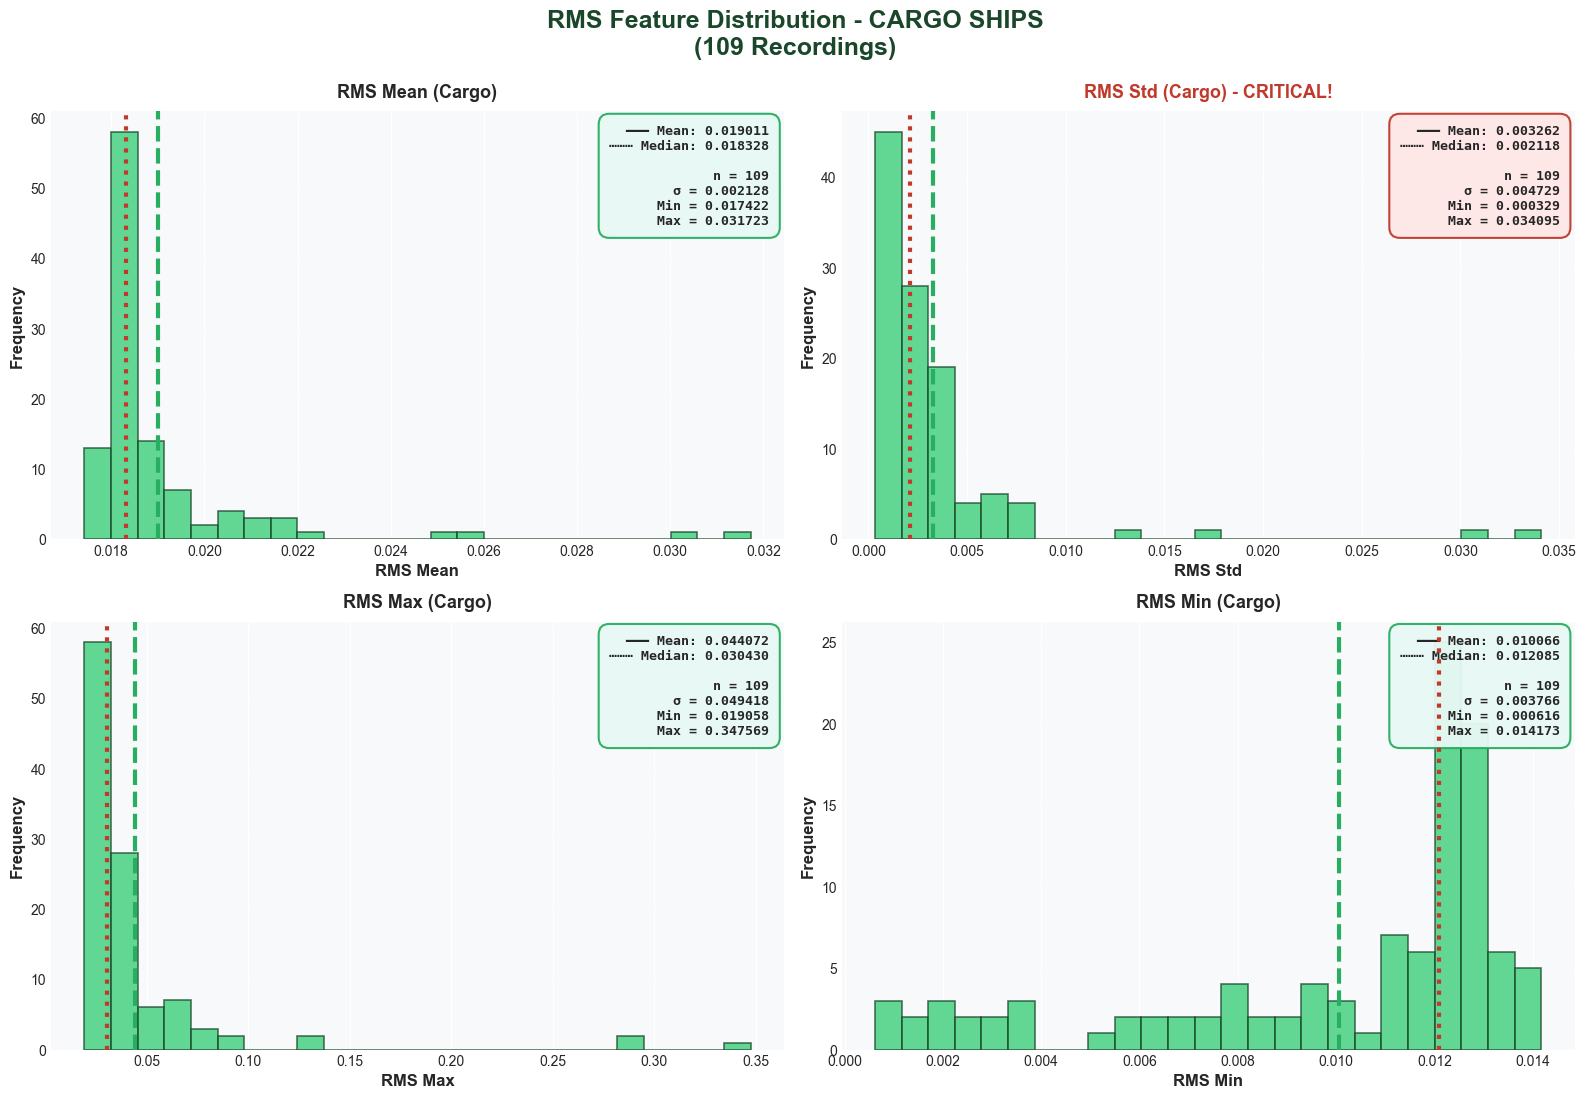


✓ CARGO HISTOGRAMS SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/23B_rms_cargo_histograms.png

✓ CARGO RMS STATISTICS:
  RMS Mean: μ=0.019011, σ=0.002128
  RMS Std: μ=0.003262, σ=0.004729
  RMS Max: μ=0.044072, σ=0.049418
  RMS Min: μ=0.010066, σ=0.003766



In [10]:
# Cell 23B: RMS Cargo Histograms (Enhanced Visualization - Combined Box)
# Purpose: Show RMS feature distribution for Cargo ships only
# Enhanced: Combined legend and statistics in top-right corner

print("\n" + "="*80)
print("CELL 23B: RMS CARGO HISTOGRAMS")
print("="*80)

if 'df_rms' not in locals():
    print("⚠️ ERROR: df_rms not found. Run Cell 23 first.")
else:
    print(f"\n✓ RMS CARGO DATA ANALYSIS:")
    cargo_rms = df_rms[df_rms['class'] == 'Cargo']
    print(f"  Total Cargo recordings: {len(cargo_rms)}")
    
    # Create figure with enhanced styling
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle('RMS Feature Distribution - CARGO SHIPS\n(109 Recordings)', 
                 fontsize=18, fontweight='bold', color='#1a472a', y=0.995)
    
    # Color scheme
    bar_color = '#2ecc71'
    mean_color = '#27ae60'
    median_color = '#c0392b'
    
    # ============================================================
    # SUBPLOT 1: RMS Mean
    # ============================================================
    ax1 = axes[0, 0]
    cargo_rms_mean = cargo_rms['rms_mean'].values
    
    ax1.hist(cargo_rms_mean, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#1a472a', linewidth=1.2)
    ax1.axvline(cargo_rms_mean.mean(), color=mean_color, linestyle='--', 
                linewidth=3, zorder=5)
    ax1.axvline(np.median(cargo_rms_mean), color=median_color, linestyle=':', 
                linewidth=3, zorder=5)
    
    ax1.set_xlabel('RMS Mean', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax1.set_title('RMS Mean (Cargo)', fontweight='bold', fontsize=13, pad=10)
    ax1.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax1.set_facecolor('#f8f9fa')
    
    # Combined statistics + legend box - top right
    stats_text1 = (
        f"━━━ Mean: {cargo_rms_mean.mean():.6f}\n"
        f"⋯⋯⋯ Median: {np.median(cargo_rms_mean):.6f}\n"
        f"\n"
        f"n = {len(cargo_rms_mean)}\n"
        f"σ = {cargo_rms_mean.std():.6f}\n"
        f"Min = {cargo_rms_mean.min():.6f}\n"
        f"Max = {cargo_rms_mean.max():.6f}"
    )
    ax1.text(0.98, 0.97, stats_text1, transform=ax1.transAxes, fontsize=9.5, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#e8f8f5', 
                      edgecolor='#27ae60', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 2: RMS Std (MOST DISCRIMINATIVE!)
    # ============================================================
    ax2 = axes[0, 1]
    cargo_rms_std = cargo_rms['rms_std'].values
    
    ax2.hist(cargo_rms_std, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#1a472a', linewidth=1.2)
    ax2.axvline(cargo_rms_std.mean(), color=mean_color, linestyle='--', 
                linewidth=3, zorder=5)
    ax2.axvline(np.median(cargo_rms_std), color=median_color, linestyle=':', 
                linewidth=3, zorder=5)
    
    ax2.set_xlabel('RMS Std', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax2.set_title('RMS Std (Cargo) - CRITICAL!', fontweight='bold', fontsize=13, pad=10, color='#c0392b')
    ax2.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax2.set_facecolor('#f8f9fa')
    
    # Combined statistics + legend box - top right
    stats_text2 = (
        f"━━━ Mean: {cargo_rms_std.mean():.6f}\n"
        f"⋯⋯⋯ Median: {np.median(cargo_rms_std):.6f}\n"
        f"\n"
        f"n = {len(cargo_rms_std)}\n"
        f"σ = {cargo_rms_std.std():.6f}\n"
        f"Min = {cargo_rms_std.min():.6f}\n"
        f"Max = {cargo_rms_std.max():.6f}"
    )
    ax2.text(0.98, 0.97, stats_text2, transform=ax2.transAxes, fontsize=9.5, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ffe6e6', 
                      edgecolor='#c0392b', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 3: RMS Max
    # ============================================================
    ax3 = axes[1, 0]
    cargo_rms_max = cargo_rms['rms_max'].values
    
    ax3.hist(cargo_rms_max, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#1a472a', linewidth=1.2)
    ax3.axvline(cargo_rms_max.mean(), color=mean_color, linestyle='--', 
                linewidth=3, zorder=5)
    ax3.axvline(np.median(cargo_rms_max), color=median_color, linestyle=':', 
                linewidth=3, zorder=5)
    
    ax3.set_xlabel('RMS Max', fontweight='bold', fontsize=12)
    ax3.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax3.set_title('RMS Max (Cargo)', fontweight='bold', fontsize=13, pad=10)
    ax3.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax3.set_facecolor('#f8f9fa')
    
    # Combined statistics + legend box - top right
    stats_text3 = (
        f"━━━ Mean: {cargo_rms_max.mean():.6f}\n"
        f"⋯⋯⋯ Median: {np.median(cargo_rms_max):.6f}\n"
        f"\n"
        f"n = {len(cargo_rms_max)}\n"
        f"σ = {cargo_rms_max.std():.6f}\n"
        f"Min = {cargo_rms_max.min():.6f}\n"
        f"Max = {cargo_rms_max.max():.6f}"
    )
    ax3.text(0.98, 0.97, stats_text3, transform=ax3.transAxes, fontsize=9.5, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#e8f8f5', 
                      edgecolor='#27ae60', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 4: RMS Min
    # ============================================================
    ax4 = axes[1, 1]
    cargo_rms_min = cargo_rms['rms_min'].values
    
    ax4.hist(cargo_rms_min, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#1a472a', linewidth=1.2)
    ax4.axvline(cargo_rms_min.mean(), color=mean_color, linestyle='--', 
                linewidth=3, zorder=5)
    ax4.axvline(np.median(cargo_rms_min), color=median_color, linestyle=':', 
                linewidth=3, zorder=5)
    
    ax4.set_xlabel('RMS Min', fontweight='bold', fontsize=12)
    ax4.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax4.set_title('RMS Min (Cargo)', fontweight='bold', fontsize=13, pad=10)
    ax4.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax4.set_facecolor('#f8f9fa')
    
    # Combined statistics + legend box - top right
    stats_text4 = (
        f"━━━ Mean: {cargo_rms_min.mean():.6f}\n"
        f"⋯⋯⋯ Median: {np.median(cargo_rms_min):.6f}\n"
        f"\n"
        f"n = {len(cargo_rms_min)}\n"
        f"σ = {cargo_rms_min.std():.6f}\n"
        f"Min = {cargo_rms_min.min():.6f}\n"
        f"Max = {cargo_rms_min.max():.6f}"
    )
    ax4.text(0.98, 0.97, stats_text4, transform=ax4.transAxes, fontsize=9.5, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#e8f8f5', 
                      edgecolor='#27ae60', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/23B_rms_cargo_histograms.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ CARGO HISTOGRAMS SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/23B_rms_cargo_histograms.png")
    print(f"\n✓ CARGO RMS STATISTICS:")
    print(f"  RMS Mean: μ={cargo_rms_mean.mean():.6f}, σ={cargo_rms_mean.std():.6f}")
    print(f"  RMS Std: μ={cargo_rms_std.mean():.6f}, σ={cargo_rms_std.std():.6f}")
    print(f"  RMS Max: μ={cargo_rms_max.mean():.6f}, σ={cargo_rms_max.std():.6f}")
    print(f"  RMS Min: μ={cargo_rms_min.mean():.6f}, σ={cargo_rms_min.std():.6f}")

print("\n" + "="*80)


CELL 23C: RMS PASSENGER HISTOGRAMS

✓ RMS PASSENGER DATA ANALYSIS:
  Total Passenger recordings: 185


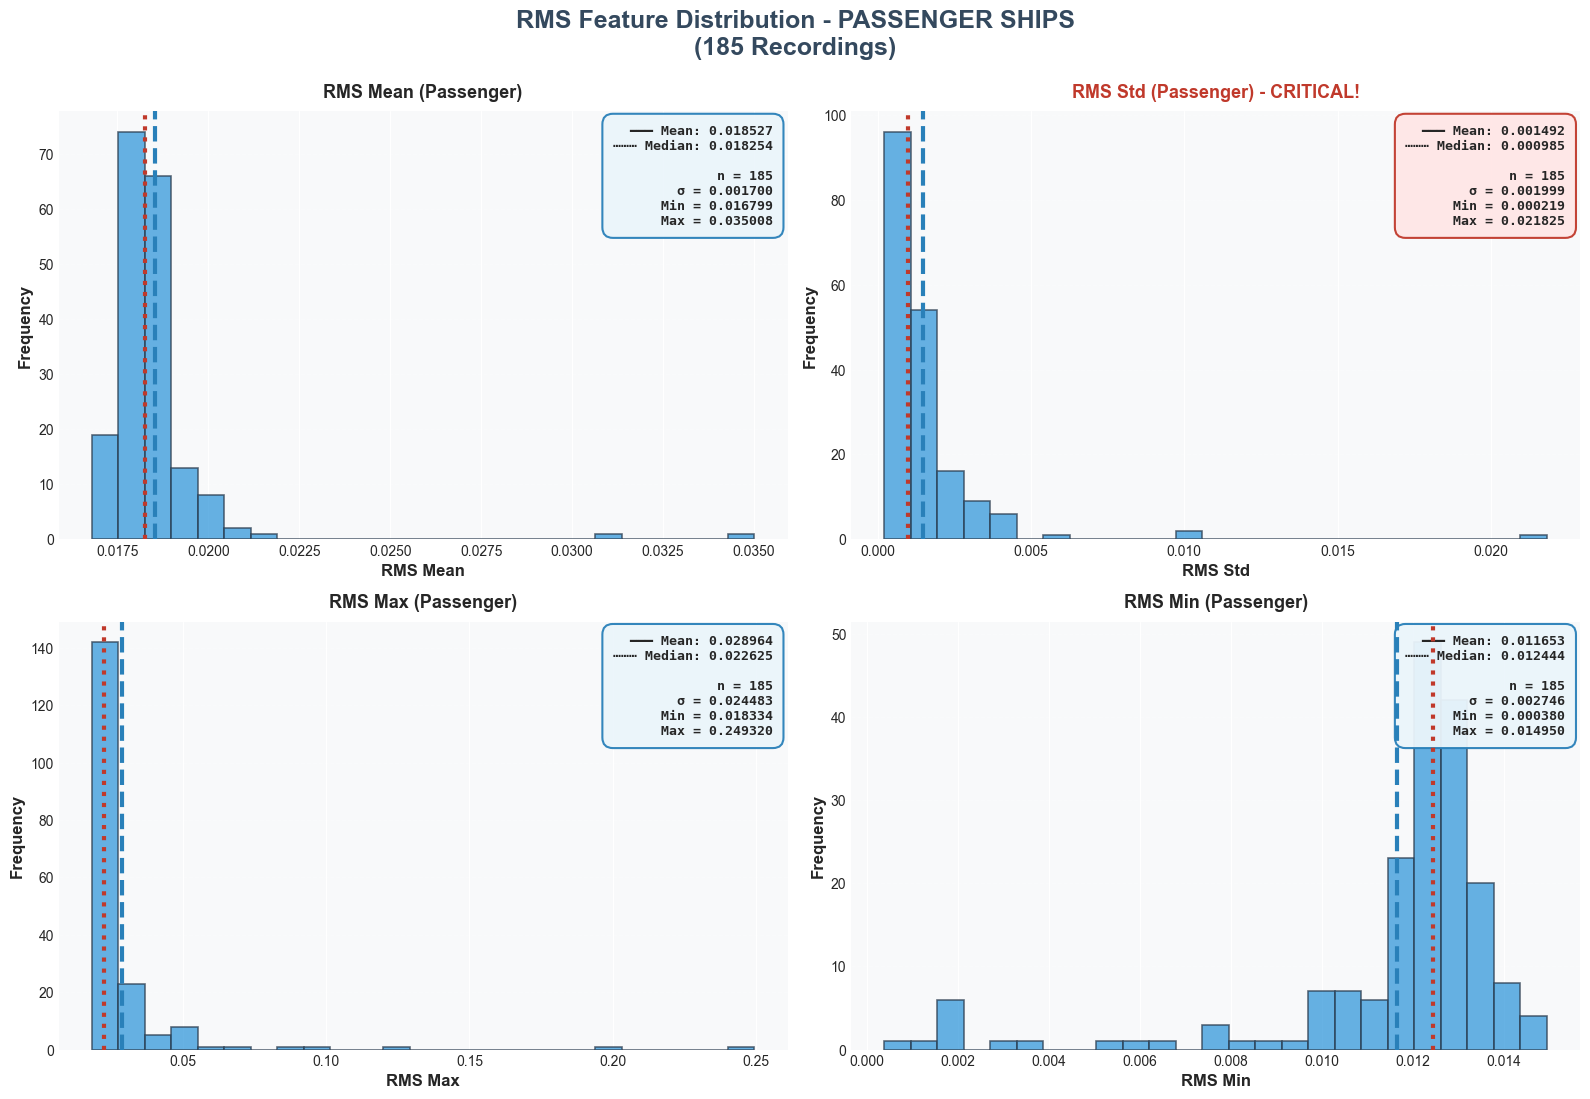


✓ PASSENGER HISTOGRAMS SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/23C_rms_passenger_histograms.png

✓ PASSENGER RMS STATISTICS:
  RMS Mean: μ=0.018527, σ=0.001700
  RMS Std: μ=0.001492, σ=0.001999
  RMS Max: μ=0.028964, σ=0.024483
  RMS Min: μ=0.011653, σ=0.002746



In [11]:
# Cell 23C: RMS Passenger Histograms (Enhanced Visualization - Combined Box)
# Purpose: Show RMS feature distribution for Passenger ships only
# Enhanced: Combined legend and statistics in top-right corner

print("\n" + "="*80)
print("CELL 23C: RMS PASSENGER HISTOGRAMS")
print("="*80)

if 'df_rms' not in locals():
    print("⚠️ ERROR: df_rms not found. Run Cell 23 first.")
else:
    print(f"\n✓ RMS PASSENGER DATA ANALYSIS:")
    passenger_rms = df_rms[df_rms['class'] == 'Passenger']
    print(f"  Total Passenger recordings: {len(passenger_rms)}")
    
    # Create figure with enhanced styling
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle('RMS Feature Distribution - PASSENGER SHIPS\n(185 Recordings)', 
                 fontsize=18, fontweight='bold', color='#34495e', y=0.995)
    
    # Color scheme - Passenger
    bar_color = '#3498db'
    mean_color = '#2980b9'
    median_color = '#c0392b'
    
    # ============================================================
    # SUBPLOT 1: RMS Mean
    # ============================================================
    ax1 = axes[0, 0]
    passenger_rms_mean = passenger_rms['rms_mean'].values
    
    ax1.hist(passenger_rms_mean, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#2c3e50', linewidth=1.2)
    ax1.axvline(passenger_rms_mean.mean(), color=mean_color, linestyle='--', 
                linewidth=3, zorder=5)
    ax1.axvline(np.median(passenger_rms_mean), color=median_color, linestyle=':', 
                linewidth=3, zorder=5)
    
    ax1.set_xlabel('RMS Mean', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax1.set_title('RMS Mean (Passenger)', fontweight='bold', fontsize=13, pad=10)
    ax1.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax1.set_facecolor('#f8f9fa')
    
    # Combined statistics + legend box - top right
    stats_text1 = (
        f"━━━ Mean: {passenger_rms_mean.mean():.6f}\n"
        f"⋯⋯⋯ Median: {np.median(passenger_rms_mean):.6f}\n"
        f"\n"
        f"n = {len(passenger_rms_mean)}\n"
        f"σ = {passenger_rms_mean.std():.6f}\n"
        f"Min = {passenger_rms_mean.min():.6f}\n"
        f"Max = {passenger_rms_mean.max():.6f}"
    )
    ax1.text(0.98, 0.97, stats_text1, transform=ax1.transAxes, fontsize=9.5, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ebf5fb', 
                      edgecolor='#2980b9', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 2: RMS Std (MOST DISCRIMINATIVE!)
    # ============================================================
    ax2 = axes[0, 1]
    passenger_rms_std = passenger_rms['rms_std'].values
    
    ax2.hist(passenger_rms_std, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#2c3e50', linewidth=1.2)
    ax2.axvline(passenger_rms_std.mean(), color=mean_color, linestyle='--', 
                linewidth=3, zorder=5)
    ax2.axvline(np.median(passenger_rms_std), color=median_color, linestyle=':', 
                linewidth=3, zorder=5)
    
    ax2.set_xlabel('RMS Std', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax2.set_title('RMS Std (Passenger) - CRITICAL!', fontweight='bold', fontsize=13, pad=10, color='#c0392b')
    ax2.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax2.set_facecolor('#f8f9fa')
    
    # Combined statistics + legend box - top right
    stats_text2 = (
        f"━━━ Mean: {passenger_rms_std.mean():.6f}\n"
        f"⋯⋯⋯ Median: {np.median(passenger_rms_std):.6f}\n"
        f"\n"
        f"n = {len(passenger_rms_std)}\n"
        f"σ = {passenger_rms_std.std():.6f}\n"
        f"Min = {passenger_rms_std.min():.6f}\n"
        f"Max = {passenger_rms_std.max():.6f}"
    )
    ax2.text(0.98, 0.97, stats_text2, transform=ax2.transAxes, fontsize=9.5, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ffe6e6', 
                      edgecolor='#c0392b', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 3: RMS Max
    # ============================================================
    ax3 = axes[1, 0]
    passenger_rms_max = passenger_rms['rms_max'].values
    
    ax3.hist(passenger_rms_max, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#2c3e50', linewidth=1.2)
    ax3.axvline(passenger_rms_max.mean(), color=mean_color, linestyle='--', 
                linewidth=3, zorder=5)
    ax3.axvline(np.median(passenger_rms_max), color=median_color, linestyle=':', 
                linewidth=3, zorder=5)
    
    ax3.set_xlabel('RMS Max', fontweight='bold', fontsize=12)
    ax3.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax3.set_title('RMS Max (Passenger)', fontweight='bold', fontsize=13, pad=10)
    ax3.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax3.set_facecolor('#f8f9fa')
    
    # Combined statistics + legend box - top right
    stats_text3 = (
        f"━━━ Mean: {passenger_rms_max.mean():.6f}\n"
        f"⋯⋯⋯ Median: {np.median(passenger_rms_max):.6f}\n"
        f"\n"
        f"n = {len(passenger_rms_max)}\n"
        f"σ = {passenger_rms_max.std():.6f}\n"
        f"Min = {passenger_rms_max.min():.6f}\n"
        f"Max = {passenger_rms_max.max():.6f}"
    )
    ax3.text(0.98, 0.97, stats_text3, transform=ax3.transAxes, fontsize=9.5, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ebf5fb', 
                      edgecolor='#2980b9', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 4: RMS Min
    # ============================================================
    ax4 = axes[1, 1]
    passenger_rms_min = passenger_rms['rms_min'].values
    
    ax4.hist(passenger_rms_min, bins=25, color=bar_color, alpha=0.75, 
             edgecolor='#2c3e50', linewidth=1.2)
    ax4.axvline(passenger_rms_min.mean(), color=mean_color, linestyle='--', 
                linewidth=3, zorder=5)
    ax4.axvline(np.median(passenger_rms_min), color=median_color, linestyle=':', 
                linewidth=3, zorder=5)
    
    ax4.set_xlabel('RMS Min', fontweight='bold', fontsize=12)
    ax4.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax4.set_title('RMS Min (Passenger)', fontweight='bold', fontsize=13, pad=10)
    ax4.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax4.set_facecolor('#f8f9fa')
    
    # Combined statistics + legend box - top right
    stats_text4 = (
        f"━━━ Mean: {passenger_rms_min.mean():.6f}\n"
        f"⋯⋯⋯ Median: {np.median(passenger_rms_min):.6f}\n"
        f"\n"
        f"n = {len(passenger_rms_min)}\n"
        f"σ = {passenger_rms_min.std():.6f}\n"
        f"Min = {passenger_rms_min.min():.6f}\n"
        f"Max = {passenger_rms_min.max():.6f}"
    )
    ax4.text(0.98, 0.97, stats_text4, transform=ax4.transAxes, fontsize=9.5, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ebf5fb', 
                      edgecolor='#2980b9', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/23C_rms_passenger_histograms.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ PASSENGER HISTOGRAMS SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/23C_rms_passenger_histograms.png")
    print(f"\n✓ PASSENGER RMS STATISTICS:")
    print(f"  RMS Mean: μ={passenger_rms_mean.mean():.6f}, σ={passenger_rms_mean.std():.6f}")
    print(f"  RMS Std: μ={passenger_rms_std.mean():.6f}, σ={passenger_rms_std.std():.6f}")
    print(f"  RMS Max: μ={passenger_rms_max.mean():.6f}, σ={passenger_rms_max.std():.6f}")
    print(f"  RMS Min: μ={passenger_rms_min.mean():.6f}, σ={passenger_rms_min.std():.6f}")

print("\n" + "="*80)


CELL 23D: RMS COMBINED HISTOGRAMS (CARGO vs PASSENGER)

✓ RMS COMBINED DATA ANALYSIS:
  Cargo recordings: 109
  Passenger recordings: 185


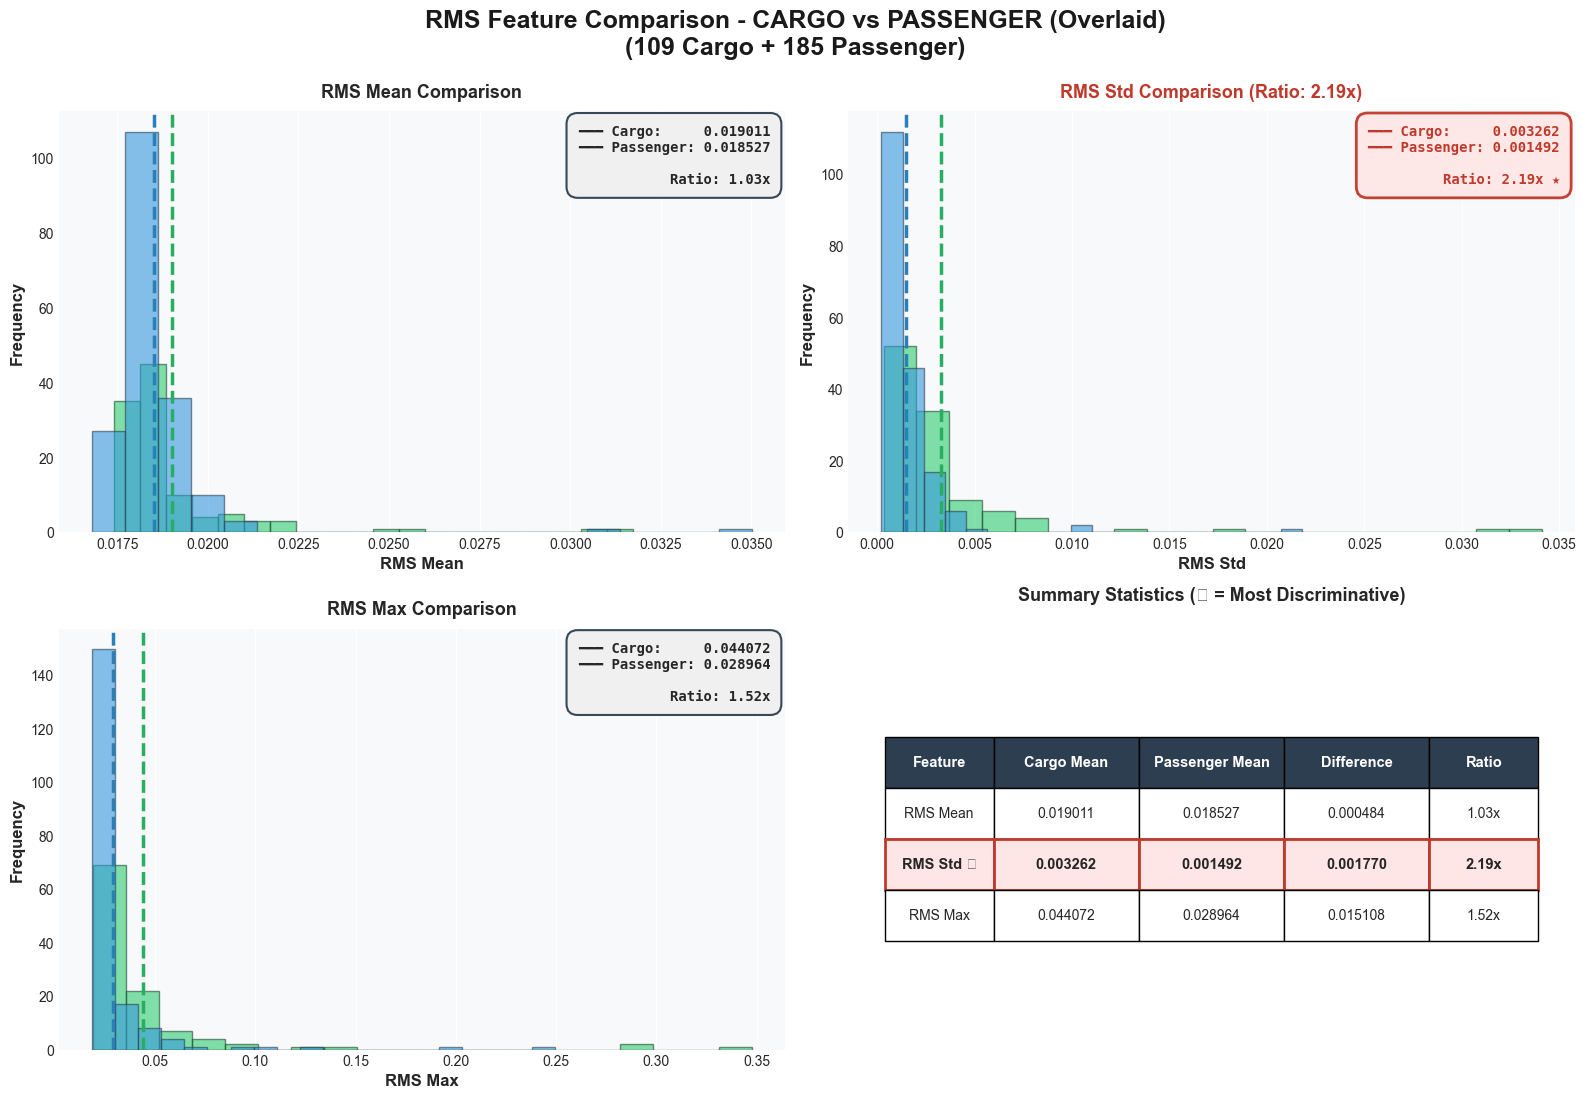


✓ COMBINED HISTOGRAMS SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/23D_rms_combined_histograms.png

✓ RMS COMPARISON SUMMARY:
  RMS Mean Ratio (Cargo/Passenger): 1.03x
  RMS Std Ratio (Cargo/Passenger): 2.19x ★ MOST DISCRIMINATIVE
  RMS Max Ratio (Cargo/Passenger): 1.52x



In [12]:
# Cell 23D: RMS Combined Histograms (Both Classes Overlaid)
# Purpose: Compare RMS feature distributions between Cargo and Passenger
# Enhanced: Better colors, fonts, layout - Combined legend + statistics

print("\n" + "="*80)
print("CELL 23D: RMS COMBINED HISTOGRAMS (CARGO vs PASSENGER)")
print("="*80)

if 'df_rms' not in locals():
    print("⚠️ ERROR: df_rms not found. Run Cell 23 first.")
else:
    print(f"\n✓ RMS COMBINED DATA ANALYSIS:")
    cargo_rms = df_rms[df_rms['class'] == 'Cargo']
    passenger_rms = df_rms[df_rms['class'] == 'Passenger']
    
    print(f"  Cargo recordings: {len(cargo_rms)}")
    print(f"  Passenger recordings: {len(passenger_rms)}")
    
    # Create figure with subplots for combined comparison
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle('RMS Feature Comparison - CARGO vs PASSENGER (Overlaid)\n(109 Cargo + 185 Passenger)', 
                 fontsize=18, fontweight='bold', color='#1a1a1a', y=0.995)
    
    # Color scheme
    cargo_color = '#2ecc71'
    passenger_color = '#3498db'
    
    # ============================================================
    # SUBPLOT 1: RMS Mean (Combined)
    # ============================================================
    ax1 = axes[0, 0]
    
    ax1.hist(cargo_rms['rms_mean'], bins=20, alpha=0.6, label='Cargo', 
             color=cargo_color, edgecolor='#1a472a', linewidth=1)
    ax1.hist(passenger_rms['rms_mean'], bins=20, alpha=0.6, label='Passenger', 
             color=passenger_color, edgecolor='#2c3e50', linewidth=1)
    
    ax1.axvline(cargo_rms['rms_mean'].mean(), color='#27ae60', linestyle='--', 
                linewidth=2.5, zorder=5)
    ax1.axvline(passenger_rms['rms_mean'].mean(), color='#2980b9', linestyle='--', 
                linewidth=2.5, zorder=5)
    
    ax1.set_xlabel('RMS Mean', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax1.set_title('RMS Mean Comparison', fontweight='bold', fontsize=13, pad=10)
    ax1.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax1.set_facecolor('#f8f9fa')
    
    # Combined box - top right
    stats_box1 = (
        f"━━━ Cargo:     {cargo_rms['rms_mean'].mean():.6f}\n"
        f"━━━ Passenger: {passenger_rms['rms_mean'].mean():.6f}\n"
        f"\n"
        f"Ratio: {cargo_rms['rms_mean'].mean() / passenger_rms['rms_mean'].mean():.2f}x"
    )
    ax1.text(0.98, 0.97, stats_box1, transform=ax1.transAxes, fontsize=10, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#f0f0f0', 
                      edgecolor='#2c3e50', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 2: RMS Std (Combined) - MOST DISCRIMINATIVE!!!
    # ============================================================
    ax2 = axes[0, 1]
    
    ax2.hist(cargo_rms['rms_std'], bins=20, alpha=0.6, label='Cargo', 
             color=cargo_color, edgecolor='#1a472a', linewidth=1)
    ax2.hist(passenger_rms['rms_std'], bins=20, alpha=0.6, label='Passenger', 
             color=passenger_color, edgecolor='#2c3e50', linewidth=1)
    
    cargo_std_mean = cargo_rms['rms_std'].mean()
    passenger_std_mean = passenger_rms['rms_std'].mean()
    ratio_std = cargo_std_mean / passenger_std_mean
    
    ax2.axvline(cargo_std_mean, color='#27ae60', linestyle='--', 
                linewidth=2.5, zorder=5)
    ax2.axvline(passenger_std_mean, color='#2980b9', linestyle='--', 
                linewidth=2.5, zorder=5)
    
    ax2.set_xlabel('RMS Std', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax2.set_title(f'RMS Std Comparison (Ratio: {ratio_std:.2f}x)', 
                  fontweight='bold', fontsize=13, pad=10, color='#c0392b')
    ax2.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax2.set_facecolor('#f8f9fa')
    
    # Combined box - top right (highlighted)
    stats_box2 = (
        f"━━━ Cargo:     {cargo_std_mean:.6f}\n"
        f"━━━ Passenger: {passenger_std_mean:.6f}\n"
        f"\n"
        f"Ratio: {ratio_std:.2f}x ★"
    )
    ax2.text(0.98, 0.97, stats_box2, transform=ax2.transAxes, fontsize=10, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ffe6e6', 
                      edgecolor='#c0392b', linewidth=2, alpha=0.95), 
             family='monospace', fontweight='bold', color='#c0392b')
    
    # ============================================================
    # SUBPLOT 3: RMS Max (Combined)
    # ============================================================
    ax3 = axes[1, 0]
    
    ax3.hist(cargo_rms['rms_max'], bins=20, alpha=0.6, label='Cargo', 
             color=cargo_color, edgecolor='#1a472a', linewidth=1)
    ax3.hist(passenger_rms['rms_max'], bins=20, alpha=0.6, label='Passenger', 
             color=passenger_color, edgecolor='#2c3e50', linewidth=1)
    
    ax3.axvline(cargo_rms['rms_max'].mean(), color='#27ae60', linestyle='--', 
                linewidth=2.5, zorder=5)
    ax3.axvline(passenger_rms['rms_max'].mean(), color='#2980b9', linestyle='--', 
                linewidth=2.5, zorder=5)
    
    ax3.set_xlabel('RMS Max', fontweight='bold', fontsize=12)
    ax3.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax3.set_title('RMS Max Comparison', fontweight='bold', fontsize=13, pad=10)
    ax3.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax3.set_facecolor('#f8f9fa')
    
    # Combined box - top right
    stats_box3 = (
        f"━━━ Cargo:     {cargo_rms['rms_max'].mean():.6f}\n"
        f"━━━ Passenger: {passenger_rms['rms_max'].mean():.6f}\n"
        f"\n"
        f"Ratio: {cargo_rms['rms_max'].mean() / passenger_rms['rms_max'].mean():.2f}x"
    )
    ax3.text(0.98, 0.97, stats_box3, transform=ax3.transAxes, fontsize=10, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#f0f0f0', 
                      edgecolor='#2c3e50', linewidth=1.5, alpha=0.95), 
             family='monospace', fontweight='bold')
    
    # ============================================================
    # SUBPLOT 4: Summary Statistics Table
    # ============================================================
    ax4 = axes[1, 1]
    ax4.axis('tight')
    ax4.axis('off')
    
    # Create summary statistics
    summary_data = [
        ['Feature', 'Cargo Mean', 'Passenger Mean', 'Difference', 'Ratio'],
        ['RMS Mean', f"{cargo_rms['rms_mean'].mean():.6f}", 
         f"{passenger_rms['rms_mean'].mean():.6f}",
         f"{abs(cargo_rms['rms_mean'].mean() - passenger_rms['rms_mean'].mean()):.6f}",
         f"{cargo_rms['rms_mean'].mean() / passenger_rms['rms_mean'].mean():.2f}x"],
        ['RMS Std ★', f"{cargo_std_mean:.6f}", 
         f"{passenger_std_mean:.6f}",
         f"{abs(cargo_std_mean - passenger_std_mean):.6f}",
         f"{ratio_std:.2f}x"],
        ['RMS Max', f"{cargo_rms['rms_max'].mean():.6f}", 
         f"{passenger_rms['rms_max'].mean():.6f}",
         f"{abs(cargo_rms['rms_max'].mean() - passenger_rms['rms_max'].mean()):.6f}",
         f"{cargo_rms['rms_max'].mean() / passenger_rms['rms_max'].mean():.2f}x"],
    ]
    
    table = ax4.table(cellText=summary_data, cellLoc='center', loc='center',
                      colWidths=[0.15, 0.2, 0.2, 0.2, 0.15])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.8)
    
    # Style header row
    for i in range(5):
        table[(0, i)].set_facecolor('#2c3e50')
        table[(0, i)].set_text_props(weight='bold', color='white', fontsize=10.5)
    
    # Highlight RMS Std row (most discriminative)
    for i in range(5):
        table[(2, i)].set_facecolor('#ffe6e6')
        table[(2, i)].set_text_props(weight='bold', fontsize=10.5)
        table[(2, i)].set_edgecolor('#c0392b')
        table[(2, i)].set_linewidth(2)
    
    # Alternate row colors for others
    for i in [1, 3]:
        for j in range(5):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#ecf0f1')
            else:
                table[(i, j)].set_facecolor('#ffffff')
    
    ax4.set_title('Summary Statistics (★ = Most Discriminative)', 
                  fontweight='bold', fontsize=13, pad=20)
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/23D_rms_combined_histograms.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ COMBINED HISTOGRAMS SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/23D_rms_combined_histograms.png")
    print(f"\n✓ RMS COMPARISON SUMMARY:")
    print(f"  RMS Mean Ratio (Cargo/Passenger): {cargo_rms['rms_mean'].mean() / passenger_rms['rms_mean'].mean():.2f}x")
    print(f"  RMS Std Ratio (Cargo/Passenger): {ratio_std:.2f}x ★ MOST DISCRIMINATIVE")
    print(f"  RMS Max Ratio (Cargo/Passenger): {cargo_rms['rms_max'].mean() / passenger_rms['rms_max'].mean():.2f}x")

print("\n" + "="*80)


CELL 23E: RMS BOXPLOT COMPARISON

✓ RMS BOXPLOT DATA:
  Cargo recordings: 109
  Passenger recordings: 185


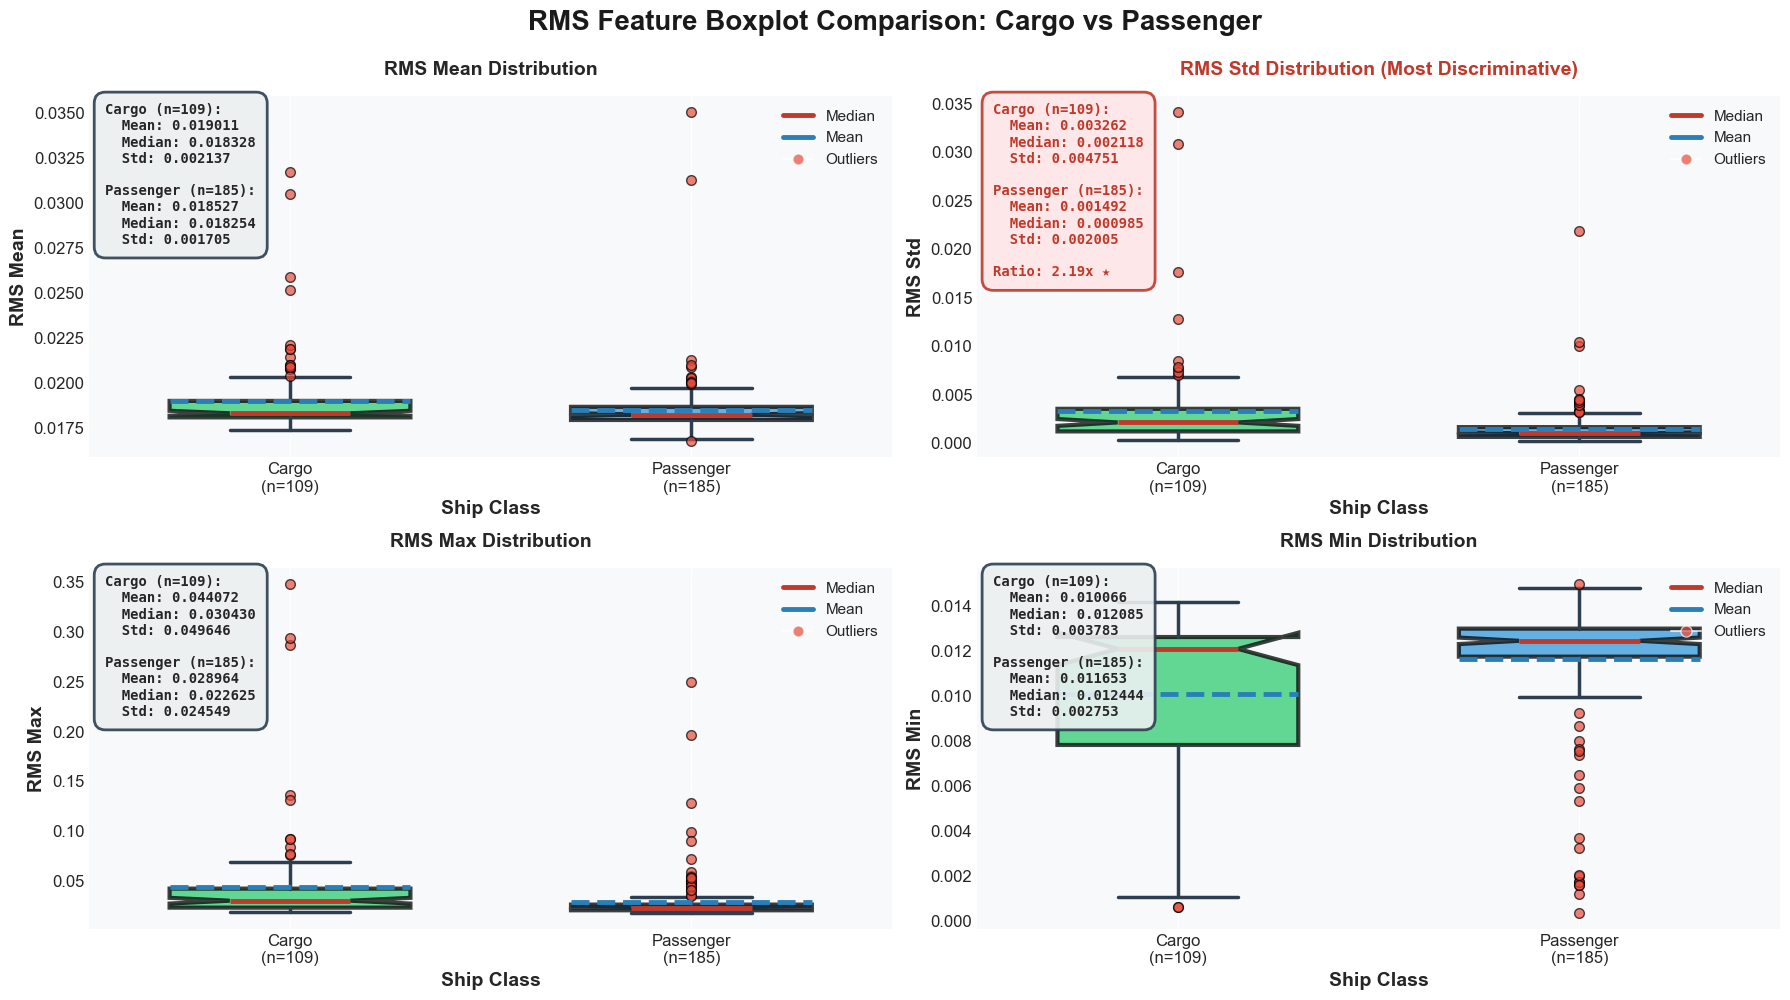


✓ BOXPLOT VISUALIZATION SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/23E_rms_boxplot_comparison.png

✓ RMS BOXPLOT SUMMARY:
  RMS Mean - Cargo Median: 0.018328, Passenger Median: 0.018254
  RMS Std - Cargo Median: 0.002118, Passenger Median: 0.000985
  RMS Std Ratio (Cargo/Passenger): 2.19x ★ MOST DISCRIMINATIVE
  RMS Max - Cargo Median: 0.030430, Passenger Median: 0.022625
  RMS Min - Cargo Median: 0.012085, Passenger Median: 0.012444



In [13]:
# Cell 23E: RMS Boxplot Comparison - Statistical Summary (Improved Design)
# Purpose: Show RMS feature distributions with quartiles and outliers
# Enhanced: Better styling, larger boxes, improved readability

print("\n" + "="*80)
print("CELL 23E: RMS BOXPLOT COMPARISON")
print("="*80)

if 'df_rms' not in locals():
    print("⚠️ ERROR: df_rms not found. Run Cell 23 first.")
else:
    print(f"\n✓ RMS BOXPLOT DATA:")
    cargo_rms = df_rms[df_rms['class'] == 'Cargo']
    passenger_rms = df_rms[df_rms['class'] == 'Passenger']
    
    print(f"  Cargo recordings: {len(cargo_rms)}")
    print(f"  Passenger recordings: {len(passenger_rms)}")
    
    # Create figure with boxplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle('RMS Feature Boxplot Comparison: Cargo vs Passenger', 
                 fontsize=20, fontweight='bold', color='#1a1a1a', y=0.995)
    
    # Color scheme
    cargo_color = '#2ecc71'
    passenger_color = '#3498db'
    
    # ============================================================
    # BOXPLOT 1: RMS MEAN
    # ============================================================
    ax1 = axes[0, 0]
    
    bp1 = ax1.boxplot([cargo_rms['rms_mean'], passenger_rms['rms_mean']], 
                       labels=['Cargo\n(n=109)', 'Passenger\n(n=185)'],
                       patch_artist=True,
                       widths=0.6,
                       showmeans=True,
                       meanline=True,
                       notch=True,
                       showcaps=True,
                       boxprops=dict(linewidth=2.5),
                       whiskerprops=dict(linewidth=2.5),
                       capprops=dict(linewidth=2.5),
                       medianprops=dict(linewidth=3),
                       meanprops=dict(linewidth=3))
    
    # Styling for Boxplot 1
    colors = [cargo_color, passenger_color]
    
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_linewidth(3)
        patch.set_alpha(0.75)
    
    for whisker in bp1['whiskers']:
        whisker.set_linewidth(2.5)
        whisker.set_color('#2c3e50')
    
    for cap in bp1['caps']:
        cap.set_linewidth(2.5)
        cap.set_color('#2c3e50')
    
    for median in bp1['medians']:
        median.set_color('#c0392b')
        median.set_linewidth(3.5)
    
    for mean in bp1['means']:
        mean.set_color('#2980b9')
        mean.set_linewidth(3.5)
    
    for flier in bp1['fliers']:
        flier.set_markerfacecolor('#e74c3c')
        flier.set_marker('o')
        flier.set_markersize(7)
        flier.set_alpha(0.7)
    
    ax1.set_ylabel('RMS Mean', fontweight='bold', fontsize=14)
    ax1.set_xlabel('Ship Class', fontweight='bold', fontsize=14)
    ax1.set_title('RMS Mean Distribution', fontweight='bold', fontsize=14, pad=15)
    ax1.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=1)
    ax1.set_facecolor('#f8f9fa')
    ax1.tick_params(labelsize=12)
    
    # Add statistics text for RMS Mean - bottom left
    cargo_mean_val = cargo_rms['rms_mean'].mean()
    passenger_mean_val = passenger_rms['rms_mean'].mean()
    cargo_median_val = cargo_rms['rms_mean'].median()
    passenger_median_val = passenger_rms['rms_mean'].median()
    
    stats_text1 = (
        f"Cargo (n=109):\n"
        f"  Mean: {cargo_mean_val:.6f}\n"
        f"  Median: {cargo_median_val:.6f}\n"
        f"  Std: {cargo_rms['rms_mean'].std():.6f}\n\n"
        f"Passenger (n=185):\n"
        f"  Mean: {passenger_mean_val:.6f}\n"
        f"  Median: {passenger_median_val:.6f}\n"
        f"  Std: {passenger_rms['rms_mean'].std():.6f}"
    )
    
    ax1.text(0.02, 0.98, stats_text1, transform=ax1.transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ecf0f1', 
                      edgecolor='#2c3e50', linewidth=2, alpha=0.9),
             family='monospace', fontweight='bold')
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='#c0392b', lw=3.5, label='Median'),
        Line2D([0], [0], color='#2980b9', lw=3.5, label='Mean'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', 
               markersize=8, label='Outliers', alpha=0.7)
    ]
    ax1.legend(handles=legend_elements, fontsize=11, loc='upper right', framealpha=0.95)
    
    # ============================================================
    # BOXPLOT 2: RMS STD (MOST DISCRIMINATIVE!)
    # ============================================================
    ax2 = axes[0, 1]
    
    bp2 = ax2.boxplot([cargo_rms['rms_std'], passenger_rms['rms_std']], 
                       labels=['Cargo\n(n=109)', 'Passenger\n(n=185)'],
                       patch_artist=True,
                       widths=0.6,
                       showmeans=True,
                       meanline=True,
                       notch=True,
                       showcaps=True,
                       boxprops=dict(linewidth=2.5),
                       whiskerprops=dict(linewidth=2.5),
                       capprops=dict(linewidth=2.5),
                       medianprops=dict(linewidth=3),
                       meanprops=dict(linewidth=3))
    
    # Styling for Boxplot 2
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_linewidth(3)
        patch.set_alpha(0.75)
    
    for whisker in bp2['whiskers']:
        whisker.set_linewidth(2.5)
        whisker.set_color('#2c3e50')
    
    for cap in bp2['caps']:
        cap.set_linewidth(2.5)
        cap.set_color('#2c3e50')
    
    for median in bp2['medians']:
        median.set_color('#c0392b')
        median.set_linewidth(3.5)
    
    for mean in bp2['means']:
        mean.set_color('#2980b9')
        mean.set_linewidth(3.5)
    
    for flier in bp2['fliers']:
        flier.set_markerfacecolor('#e74c3c')
        flier.set_marker('o')
        flier.set_markersize(7)
        flier.set_alpha(0.7)
    
    ax2.set_ylabel('RMS Std', fontweight='bold', fontsize=14)
    ax2.set_xlabel('Ship Class', fontweight='bold', fontsize=14)
    ax2.set_title('RMS Std Distribution (Most Discriminative)', fontweight='bold', 
                  fontsize=14, pad=15, color='#c0392b')
    ax2.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=1)
    ax2.set_facecolor('#f8f9fa')
    ax2.tick_params(labelsize=12)
    
    # Add statistics text for RMS Std - bottom left
    cargo_std_val = cargo_rms['rms_std'].mean()
    passenger_std_val = passenger_rms['rms_std'].mean()
    cargo_std_median = cargo_rms['rms_std'].median()
    passenger_std_median = passenger_rms['rms_std'].median()
    ratio = cargo_std_val / passenger_std_val
    
    stats_text2 = (
        f"Cargo (n=109):\n"
        f"  Mean: {cargo_std_val:.6f}\n"
        f"  Median: {cargo_std_median:.6f}\n"
        f"  Std: {cargo_rms['rms_std'].std():.6f}\n\n"
        f"Passenger (n=185):\n"
        f"  Mean: {passenger_std_val:.6f}\n"
        f"  Median: {passenger_std_median:.6f}\n"
        f"  Std: {passenger_rms['rms_std'].std():.6f}\n\n"
        f"Ratio: {ratio:.2f}x ★"
    )
    
    ax2.text(0.02, 0.98, stats_text2, transform=ax2.transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ffe6e6', 
                      edgecolor='#c0392b', linewidth=2, alpha=0.9),
             family='monospace', fontweight='bold', color='#c0392b')
    
    ax2.legend(handles=legend_elements, fontsize=11, loc='upper right', framealpha=0.95)
    
    # ============================================================
    # BOXPLOT 3: RMS MAX
    # ============================================================
    ax3 = axes[1, 0]
    
    bp3 = ax3.boxplot([cargo_rms['rms_max'], passenger_rms['rms_max']], 
                       labels=['Cargo\n(n=109)', 'Passenger\n(n=185)'],
                       patch_artist=True,
                       widths=0.6,
                       showmeans=True,
                       meanline=True,
                       notch=True,
                       showcaps=True,
                       boxprops=dict(linewidth=2.5),
                       whiskerprops=dict(linewidth=2.5),
                       capprops=dict(linewidth=2.5),
                       medianprops=dict(linewidth=3),
                       meanprops=dict(linewidth=3))
    
    # Styling for Boxplot 3
    for patch, color in zip(bp3['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_linewidth(3)
        patch.set_alpha(0.75)
    
    for whisker in bp3['whiskers']:
        whisker.set_linewidth(2.5)
        whisker.set_color('#2c3e50')
    
    for cap in bp3['caps']:
        cap.set_linewidth(2.5)
        cap.set_color('#2c3e50')
    
    for median in bp3['medians']:
        median.set_color('#c0392b')
        median.set_linewidth(3.5)
    
    for mean in bp3['means']:
        mean.set_color('#2980b9')
        mean.set_linewidth(3.5)
    
    for flier in bp3['fliers']:
        flier.set_markerfacecolor('#e74c3c')
        flier.set_marker('o')
        flier.set_markersize(7)
        flier.set_alpha(0.7)
    
    ax3.set_ylabel('RMS Max', fontweight='bold', fontsize=14)
    ax3.set_xlabel('Ship Class', fontweight='bold', fontsize=14)
    ax3.set_title('RMS Max Distribution', fontweight='bold', fontsize=14, pad=15)
    ax3.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=1)
    ax3.set_facecolor('#f8f9fa')
    ax3.tick_params(labelsize=12)
    
    # Add statistics text for RMS Max - bottom left
    cargo_max_val = cargo_rms['rms_max'].mean()
    passenger_max_val = passenger_rms['rms_max'].mean()
    cargo_max_median = cargo_rms['rms_max'].median()
    passenger_max_median = passenger_rms['rms_max'].median()
    
    stats_text3 = (
        f"Cargo (n=109):\n"
        f"  Mean: {cargo_max_val:.6f}\n"
        f"  Median: {cargo_max_median:.6f}\n"
        f"  Std: {cargo_rms['rms_max'].std():.6f}\n\n"
        f"Passenger (n=185):\n"
        f"  Mean: {passenger_max_val:.6f}\n"
        f"  Median: {passenger_max_median:.6f}\n"
        f"  Std: {passenger_rms['rms_max'].std():.6f}"
    )
    
    ax3.text(0.02, 0.98, stats_text3, transform=ax3.transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ecf0f1', 
                      edgecolor='#2c3e50', linewidth=2, alpha=0.9),
             family='monospace', fontweight='bold')
    
    ax3.legend(handles=legend_elements, fontsize=11, loc='upper right', framealpha=0.95)
    
    # ============================================================
    # BOXPLOT 4: RMS MIN
    # ============================================================
    ax4 = axes[1, 1]
    
    bp4 = ax4.boxplot([cargo_rms['rms_min'], passenger_rms['rms_min']], 
                       labels=['Cargo\n(n=109)', 'Passenger\n(n=185)'],
                       patch_artist=True,
                       widths=0.6,
                       showmeans=True,
                       meanline=True,
                       notch=True,
                       showcaps=True,
                       boxprops=dict(linewidth=2.5),
                       whiskerprops=dict(linewidth=2.5),
                       capprops=dict(linewidth=2.5),
                       medianprops=dict(linewidth=3),
                       meanprops=dict(linewidth=3))
    
    # Styling for Boxplot 4
    for patch, color in zip(bp4['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_linewidth(3)
        patch.set_alpha(0.75)
    
    for whisker in bp4['whiskers']:
        whisker.set_linewidth(2.5)
        whisker.set_color('#2c3e50')
    
    for cap in bp4['caps']:
        cap.set_linewidth(2.5)
        cap.set_color('#2c3e50')
    
    for median in bp4['medians']:
        median.set_color('#c0392b')
        median.set_linewidth(3.5)
    
    for mean in bp4['means']:
        mean.set_color('#2980b9')
        mean.set_linewidth(3.5)
    
    for flier in bp4['fliers']:
        flier.set_markerfacecolor('#e74c3c')
        flier.set_marker('o')
        flier.set_markersize(7)
        flier.set_alpha(0.7)
    
    ax4.set_ylabel('RMS Min', fontweight='bold', fontsize=14)
    ax4.set_xlabel('Ship Class', fontweight='bold', fontsize=14)
    ax4.set_title('RMS Min Distribution', fontweight='bold', fontsize=14, pad=15)
    ax4.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=1)
    ax4.set_facecolor('#f8f9fa')
    ax4.tick_params(labelsize=12)
    
    # Add statistics text for RMS Min - bottom left
    cargo_min_val = cargo_rms['rms_min'].mean()
    passenger_min_val = passenger_rms['rms_min'].mean()
    cargo_min_median = cargo_rms['rms_min'].median()
    passenger_min_median = passenger_rms['rms_min'].median()
    
    stats_text4 = (
        f"Cargo (n=109):\n"
        f"  Mean: {cargo_min_val:.6f}\n"
        f"  Median: {cargo_min_median:.6f}\n"
        f"  Std: {cargo_rms['rms_min'].std():.6f}\n\n"
        f"Passenger (n=185):\n"
        f"  Mean: {passenger_min_val:.6f}\n"
        f"  Median: {passenger_min_median:.6f}\n"
        f"  Std: {passenger_rms['rms_min'].std():.6f}"
    )
    
    ax4.text(0.02, 0.98, stats_text4, transform=ax4.transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#ecf0f1', 
                      edgecolor='#2c3e50', linewidth=2, alpha=0.9),
             family='monospace', fontweight='bold')
    
    ax4.legend(handles=legend_elements, fontsize=11, loc='upper right', framealpha=0.95)
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/23E_rms_boxplot_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ BOXPLOT VISUALIZATION SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/23E_rms_boxplot_comparison.png")
    print(f"\n✓ RMS BOXPLOT SUMMARY:")
    print(f"  RMS Mean - Cargo Median: {cargo_rms['rms_mean'].median():.6f}, Passenger Median: {passenger_rms['rms_mean'].median():.6f}")
    print(f"  RMS Std - Cargo Median: {cargo_rms['rms_std'].median():.6f}, Passenger Median: {passenger_rms['rms_std'].median():.6f}")
    print(f"  RMS Std Ratio (Cargo/Passenger): {ratio:.2f}x ★ MOST DISCRIMINATIVE")
    print(f"  RMS Max - Cargo Median: {cargo_rms['rms_max'].median():.6f}, Passenger Median: {passenger_rms['rms_max'].median():.6f}")
    print(f"  RMS Min - Cargo Median: {cargo_rms['rms_min'].median():.6f}, Passenger Median: {passenger_rms['rms_min'].median():.6f}")

print("\n" + "="*80)

In [14]:
# Cell 24: Extract MFCC (Mel-Frequency Cepstral Coefficient) Features
# Purpose: Calculate per-frame MFCC and aggregate statistics
# Supervisor Requirement: Spectral feature extraction
# Method: Per-frame approach from STFT

print("\n" + "="*80)
print("CELL 24: MFCC (MEL-FREQUENCY CEPSTRAL COEFFICIENT) FEATURE EXTRACTION")
print("="*80)

print(f"\n✓ MFCC DEFINITION & METHOD:")
print(f"  MFCC = Mel-Frequency Cepstral Coefficients")
print(f"  Definition: Spectral features that mimic human hearing")
print(f"  Ship relevance: Engine acoustic signature in perceptual space")
print(f"  Extraction: Per-frame MFCC from STFT magnitude")
print(f"  Coefficients: {N_MFCC} (standard in speech/audio)")
print(f"  Aggregation per coefficient: mean, std, max, min, median")
print(f"  Total features: {N_MFCC} × 5 stats = 65 features")

mfcc_features_list = []
failed_mfcc = 0
processed_ids = []

print(f"\n✓ PROCESSING {len(audio_files)} VALIDATED RECORDINGS:")

for idx, audio_data in enumerate(audio_files):
    try:
        audio = audio_data['audio']
        sr = audio_data['sr']
        unique_id = audio_data['class'] + '_' + audio_data['folder'] + '_' + audio_data['filename']
        
        # Verify this ID is in validated set
        if unique_id not in df_meta['unique_id'].values:
            print(f"  ✗ Recording {idx + 1}: {unique_id} NOT in validated set - SKIPPING")
            continue
        
        # Compute MFCC per frame
        mfcc_per_frame = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=N_MFCC,
            n_fft=FRAME_LENGTH,
            hop_length=HOP_LENGTH
        )  # Shape: (N_MFCC, num_frames)
        
        # Aggregate statistics for each coefficient
        mfcc_stats = {
            'unique_id': unique_id,
            'class': audio_data['class'],
            'num_frames': mfcc_per_frame.shape[1]
        }
        
        # For each MFCC coefficient
        for coeff_idx in range(N_MFCC):
            coeff_data = mfcc_per_frame[coeff_idx, :]
            
            mfcc_stats[f'mfcc_c{coeff_idx+1}_mean'] = np.mean(coeff_data)
            mfcc_stats[f'mfcc_c{coeff_idx+1}_std'] = np.std(coeff_data)
            mfcc_stats[f'mfcc_c{coeff_idx+1}_max'] = np.max(coeff_data)
            mfcc_stats[f'mfcc_c{coeff_idx+1}_min'] = np.min(coeff_data)
            mfcc_stats[f'mfcc_c{coeff_idx+1}_median'] = np.median(coeff_data)
        
        mfcc_features_list.append(mfcc_stats)
        processed_ids.append(unique_id)
        
        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(audio_files)} recordings")
    
    except Exception as e:
        failed_mfcc += 1
        print(f"  ✗ Error on recording {idx + 1}: {str(e)}")

df_mfcc = pd.DataFrame(mfcc_features_list)

print(f"\n✓ MFCC EXTRACTION RESULTS:")
print(f"  Successfully processed: {len(df_mfcc)}/{len(audio_files)}")
print(f"  Expected: 294")
print(f"  Failed: {failed_mfcc}")

# Verify we got all expected recordings
if len(df_mfcc) == 294:
    print(f"  ✓ SUCCESS: All 294 valid recordings processed")
else:
    print(f"  ⚠️ WARNING: Expected 294, got {len(df_mfcc)}")

# Extract MFCC feature columns
mfcc_cols = [col for col in df_mfcc.columns if col.startswith('mfcc_')]

print(f"\n✓ MFCC FEATURE MATRIX:")
print(f"  Shape: {df_mfcc.shape}")
print(f"  MFCC features per recording: {len(mfcc_cols)}")
print(f"  Features: {N_MFCC} coefficients × 5 stats = {len(mfcc_cols)}")

# Statistical summary
print(f"\n✓ MFCC STATISTICS (ALL {len(df_mfcc)} RECORDINGS):")
stats_df = df_mfcc[[col for col in mfcc_cols if col != 'num_frames']]
print(stats_df.describe().round(4))

# Verify per-frame approach (duration normalization)
print(f"\n✓ DURATION NORMALIZATION VERIFICATION (Per-Frame):")
print(f"  Min frames in any recording: {df_mfcc['num_frames'].min()}")
print(f"  Max frames in any recording: {df_mfcc['num_frames'].max()}")
print(f"  Mean frames: {df_mfcc['num_frames'].mean():.0f}")
print(f"  ✓ Different durations → different frame counts → aggregated to SAME feature count")

# Class comparison
print(f"\n✓ MFCC BY CLASS:")
cargo_mfcc = df_mfcc[df_mfcc['class'] == 'Cargo']
passenger_mfcc = df_mfcc[df_mfcc['class'] == 'Passenger']

print(f"\n  CARGO ({len(cargo_mfcc)} recordings):")
print(f"    MFCC C1 mean: {cargo_mfcc['mfcc_c1_mean'].mean():.4f} ± {cargo_mfcc['mfcc_c1_mean'].std():.4f}")
print(f"    MFCC C7 mean: {cargo_mfcc['mfcc_c7_mean'].mean():.4f} ± {cargo_mfcc['mfcc_c7_mean'].std():.4f}")

print(f"\n  PASSENGER ({len(passenger_mfcc)} recordings):")
print(f"    MFCC C1 mean: {passenger_mfcc['mfcc_c1_mean'].mean():.4f} ± {passenger_mfcc['mfcc_c1_mean'].std():.4f}")
print(f"    MFCC C7 mean: {passenger_mfcc['mfcc_c7_mean'].mean():.4f} ± {passenger_mfcc['mfcc_c7_mean'].std():.4f}")

# Verify MFCC extraction
print(f"\n✓ MFCC EXTRACTION VERIFICATION:")
sample_mfcc_c1 = df_mfcc['mfcc_c1_mean'].values
print(f"  MFCC C1 Mean range: {sample_mfcc_c1.min():.4f} to {sample_mfcc_c1.max():.4f}")
print(f"  MFCC C1 Mean avg: {sample_mfcc_c1.mean():.4f}")

print(f"\n✓ MFCC FEATURE EXTRACTION COMPLETE")
print("="*80)


CELL 24: MFCC (MEL-FREQUENCY CEPSTRAL COEFFICIENT) FEATURE EXTRACTION

✓ MFCC DEFINITION & METHOD:
  MFCC = Mel-Frequency Cepstral Coefficients
  Definition: Spectral features that mimic human hearing
  Ship relevance: Engine acoustic signature in perceptual space
  Extraction: Per-frame MFCC from STFT magnitude
  Coefficients: 13 (standard in speech/audio)
  Aggregation per coefficient: mean, std, max, min, median
  Total features: 13 × 5 stats = 65 features

✓ PROCESSING 294 VALIDATED RECORDINGS:
  Processed 50/294 recordings
  Processed 100/294 recordings
  Processed 150/294 recordings
  Processed 200/294 recordings
  Processed 250/294 recordings

✓ MFCC EXTRACTION RESULTS:
  Successfully processed: 294/294
  Expected: 294
  Failed: 0
  ✓ SUCCESS: All 294 valid recordings processed

✓ MFCC FEATURE MATRIX:
  Shape: (294, 68)
  MFCC features per recording: 65
  Features: 13 coefficients × 5 stats = 65

✓ MFCC STATISTICS (ALL 294 RECORDINGS):
       mfcc_c1_mean  mfcc_c1_std  mfcc_c1_


CELL 25: MFCC BOXPLOT COMPARISON (ALL 13 COEFFICIENTS)

✓ MFCC BOXPLOT DATA:
  Cargo recordings: 109
  Passenger recordings: 185
  Sample MFCC columns: ['mfcc_c10_mean', 'mfcc_c11_mean', 'mfcc_c12_mean']
  MFCC columns found: 13


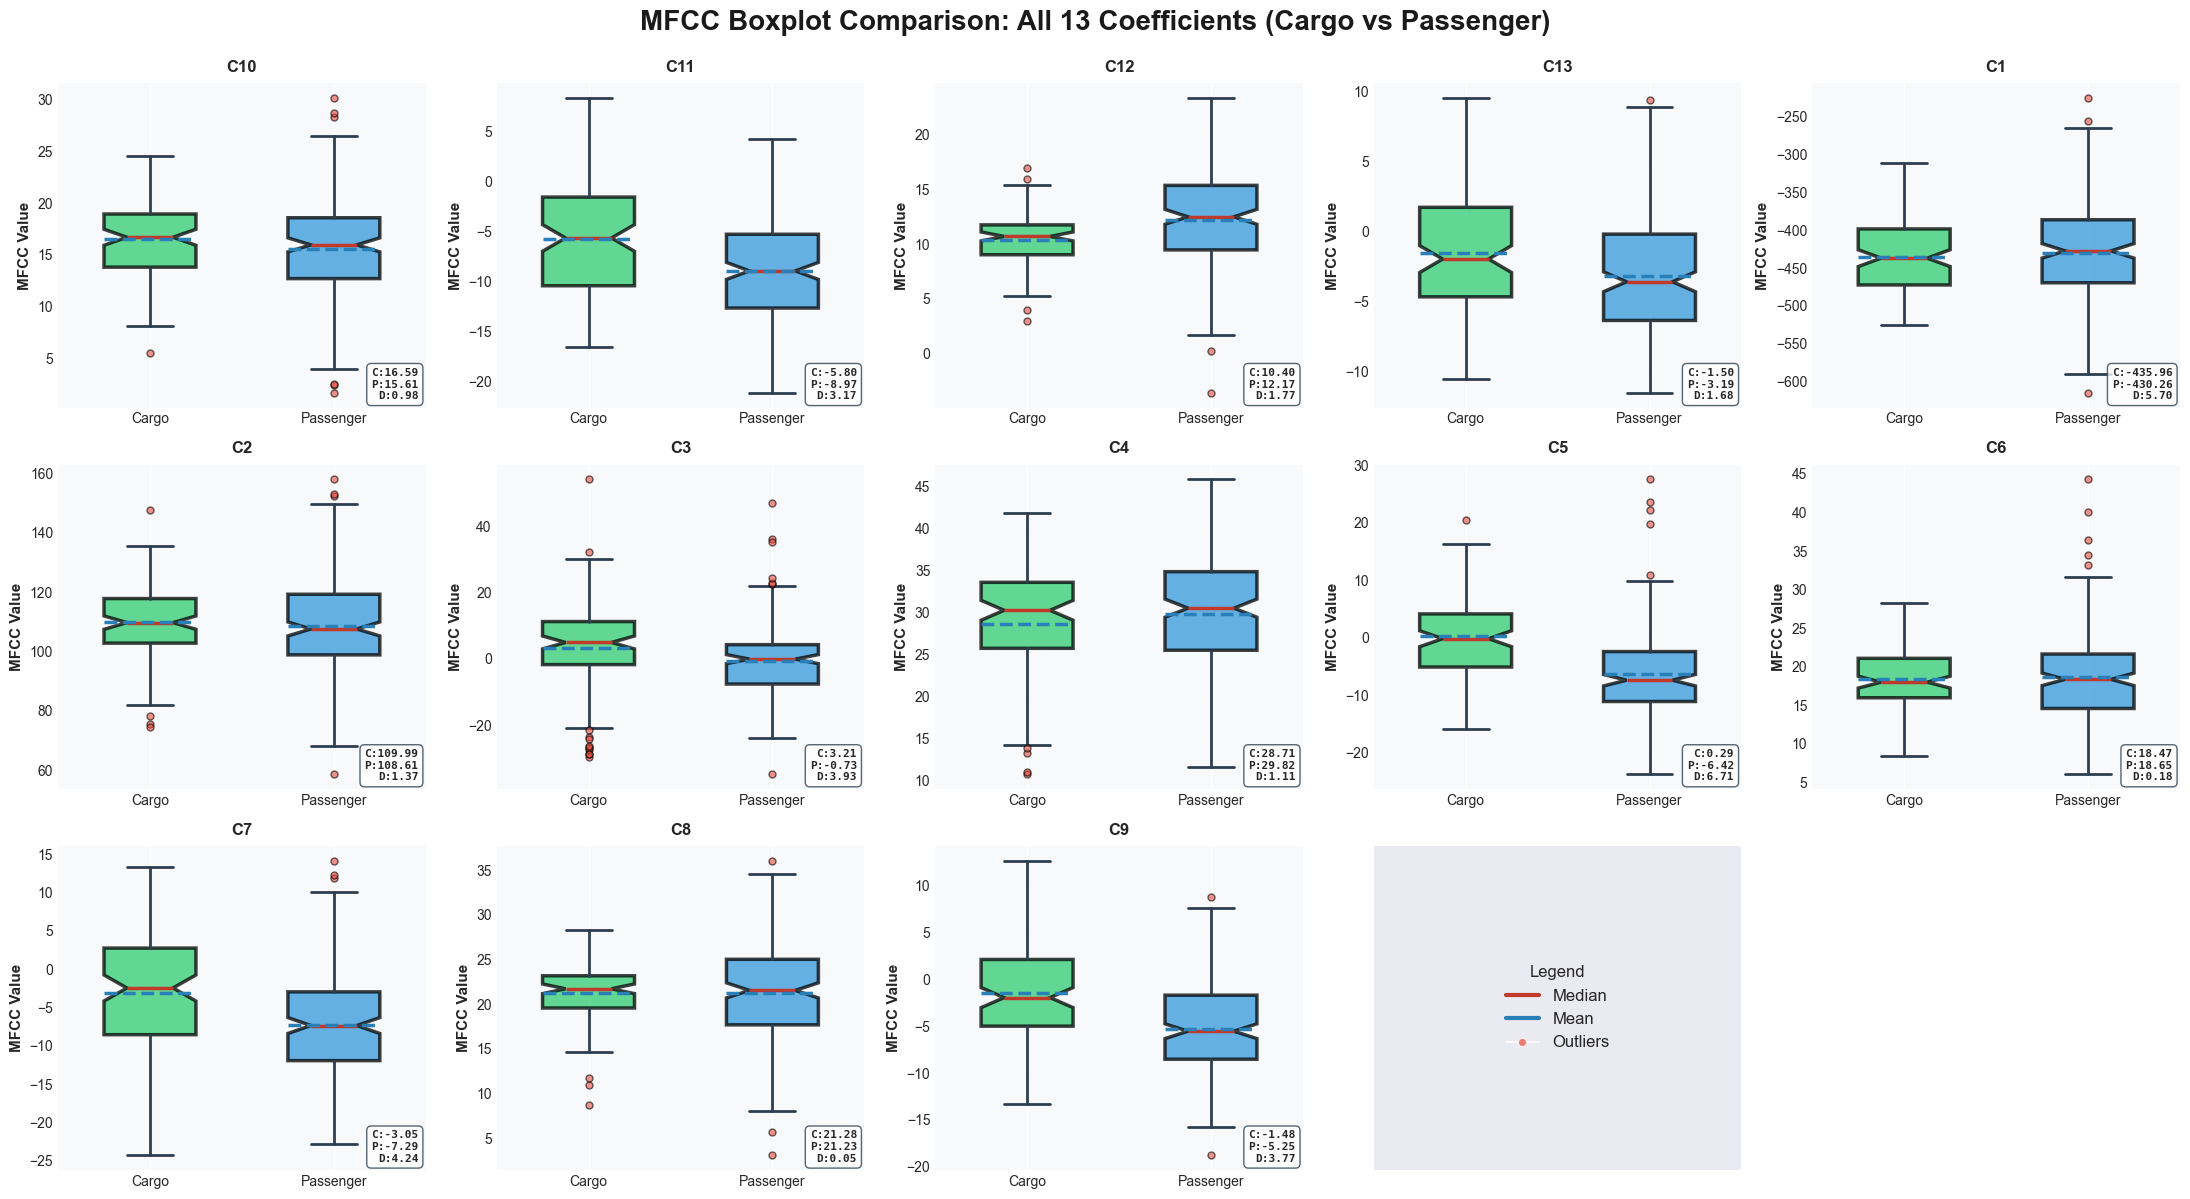


✓ MFCC BOXPLOT VISUALIZATION SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/25_mfcc_boxplot_comparison.png

✓ MFCC BOXPLOT SUMMARY (All 13 Coefficients):
Coeff    Cargo Mean      Passenger Mean  Difference     
C10      16.5870         15.6107         0.9763         
C11      -5.7984         -8.9729         3.1745         
C12      10.4025         12.1743         1.7718         
C13      -1.5025         -3.1873         1.6848         
C1       -435.9597       -430.2637       5.6960         
C2       109.9883        108.6134        1.3749         
C3       3.2078          -0.7254         3.9332         
C4       28.7121         29.8186         1.1065         
C5       0.2905          -6.4210         6.7115         
C6       18.4690         18.6455         0.1766         
C7       -3.0518         -7.2920         4.2401         
C8       21.2754         21.2273         0.0481         
C9       -1.4780         -5.2525         3.7745    

In [15]:
# Cell 25: MFCC Boxplot Comparison - All 13 Coefficients (FIXED)
# Purpose: Show MFCC feature distributions for all coefficients
# Focus: All 13 MFCC coefficients mean values

print("\n" + "="*80)
print("CELL 25: MFCC BOXPLOT COMPARISON (ALL 13 COEFFICIENTS)")
print("="*80)

if 'df_mfcc' not in locals():
    print("⚠️ ERROR: df_mfcc not found. Run Cell 24 first.")
else:
    print(f"\n✓ MFCC BOXPLOT DATA:")
    cargo_mfcc = df_mfcc[df_mfcc['class'] == 'Cargo']
    passenger_mfcc = df_mfcc[df_mfcc['class'] == 'Passenger']
    
    print(f"  Cargo recordings: {len(cargo_mfcc)}")
    print(f"  Passenger recordings: {len(passenger_mfcc)}")
    
    # Extract all 13 MFCC coefficients - check column structure
    mfcc_cols = [col for col in df_mfcc.columns if col.startswith('mfcc_') and '_mean' in col]
    mfcc_cols = sorted(mfcc_cols)
    print(f"  Sample MFCC columns: {mfcc_cols[:3]}")
    print(f"  MFCC columns found: {len(mfcc_cols)}")
    
    # Create figure with boxplots for all 13 MFCC features
    fig, axes = plt.subplots(3, 5, figsize=(22, 12))
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle('MFCC Boxplot Comparison: All 13 Coefficients (Cargo vs Passenger)', 
                 fontsize=20, fontweight='bold', color='#1a1a1a', y=0.995)
    
    # Color scheme
    cargo_color = '#2ecc71'
    passenger_color = '#3498db'
    
    # Flatten axes for easier iteration
    axes_flat = axes.flatten()
    
    # Legend (define once)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='#c0392b', lw=3, label='Median'),
        Line2D([0], [0], color='#2980b9', lw=3, label='Mean'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', 
               markersize=6, label='Outliers', alpha=0.7)
    ]
    
    # Store stats for summary
    mfcc_stats = []
    
    # ============================================================
    # BOXPLOTS FOR ALL 13 COEFFICIENTS
    # ============================================================
    for idx, coeff_col in enumerate(mfcc_cols):
        ax = axes_flat[idx]
        
        # Extract coefficient number from column name
        # Expected format: 'mfcc_c1_mean', 'mfcc_c2_mean', etc.
        parts = coeff_col.split('_')
        coeff_num = parts[1][1:]  # Get '1', '2', etc. from 'c1', 'c2'
        
        bp = ax.boxplot([cargo_mfcc[coeff_col], passenger_mfcc[coeff_col]], 
                         labels=['Cargo', 'Passenger'],
                         patch_artist=True,
                         widths=0.5,
                         showmeans=True,
                         meanline=True,
                         notch=True,
                         showcaps=True,
                         boxprops=dict(linewidth=2),
                         whiskerprops=dict(linewidth=2),
                         capprops=dict(linewidth=2),
                         medianprops=dict(linewidth=2.5),
                         meanprops=dict(linewidth=2.5))
        
        # Styling
        colors = [cargo_color, passenger_color]
        
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_linewidth(2.5)
            patch.set_alpha(0.75)
        
        for whisker in bp['whiskers']:
            whisker.set_linewidth(2)
            whisker.set_color('#2c3e50')
        
        for cap in bp['caps']:
            cap.set_linewidth(2)
            cap.set_color('#2c3e50')
        
        for median in bp['medians']:
            median.set_color('#c0392b')
            median.set_linewidth(2.5)
        
        for mean in bp['means']:
            mean.set_color('#2980b9')
            mean.set_linewidth(2.5)
        
        for flier in bp['fliers']:
            flier.set_markerfacecolor('#e74c3c')
            flier.set_marker('o')
            flier.set_markersize(5)
            flier.set_alpha(0.6)
        
        ax.set_ylabel('MFCC Value', fontweight='bold', fontsize=11)
        ax.set_title(f'C{coeff_num}', fontweight='bold', fontsize=12, pad=8)
        ax.grid(True, alpha=0.25, axis='y', linestyle='--', linewidth=0.8)
        ax.set_facecolor('#f8f9fa')
        ax.tick_params(labelsize=10)
        
        # Calculate statistics
        cargo_mean = cargo_mfcc[coeff_col].mean()
        passenger_mean = passenger_mfcc[coeff_col].mean()
        diff = abs(cargo_mean - passenger_mean)
        
        mfcc_stats.append({
            'coeff': f'C{coeff_num}',
            'cargo_mean': cargo_mean,
            'passenger_mean': passenger_mean,
            'difference': diff
        })
        
        # Add small stats text
        stats_mini = f"C:{cargo_mean:.2f}\nP:{passenger_mean:.2f}\nD:{diff:.2f}"
        ax.text(0.98, 0.02, stats_mini, transform=ax.transAxes,
                fontsize=8, verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffffff', 
                         edgecolor='#2c3e50', linewidth=1, alpha=0.8),
                family='monospace', fontweight='bold')
    
    # Hide the last two subplots (we have 13 coefficients, 15 subplots in 3x5)
    axes_flat[13].axis('off')
    axes_flat[14].axis('off')
    
    # Add legend to subplot 13
    axes_flat[13].legend(handles=legend_elements, fontsize=12, loc='center', 
                        framealpha=0.95, title='Legend', title_fontsize=12)
    axes_flat[13].axis('on')
    axes_flat[13].set_xticks([])
    axes_flat[13].set_yticks([])
    for spine in axes_flat[13].spines.values():
        spine.set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/25_mfcc_boxplot_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ MFCC BOXPLOT VISUALIZATION SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/25_mfcc_boxplot_comparison.png")
    print(f"\n✓ MFCC BOXPLOT SUMMARY (All 13 Coefficients):")
    print(f"{'Coeff':<8} {'Cargo Mean':<15} {'Passenger Mean':<15} {'Difference':<15}")
    print("="*53)
    for stat in mfcc_stats:
        print(f"{stat['coeff']:<8} {stat['cargo_mean']:<15.4f} {stat['passenger_mean']:<15.4f} {stat['difference']:<15.4f}")

print("\n" + "="*80)


CELL 26: MFCC HEATMAP (ALL 13 COEFFICIENTS)

✓ MFCC HEATMAP DATA:
  Cargo recordings: 109
  Passenger recordings: 185
  MFCC columns found: 13


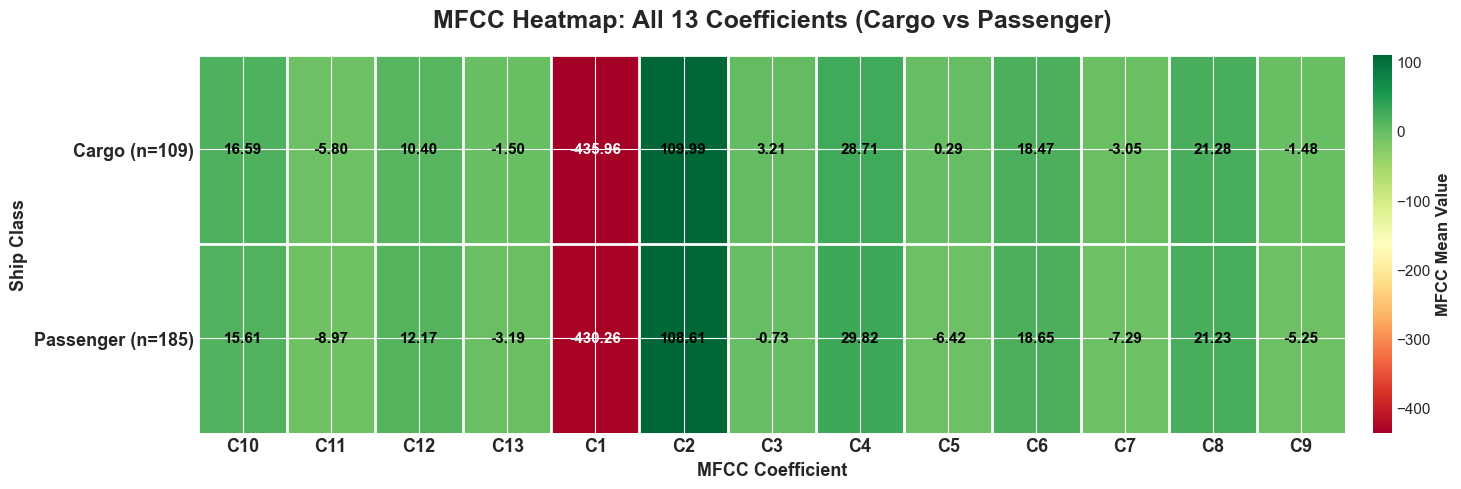


✓ MFCC HEATMAP VISUALIZATION SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/26_mfcc_heatmap.png

✓ MFCC HEATMAP SUMMARY:
Coefficient     Cargo Mean      Passenger Mean  Difference     
C10             16.5870         15.6107         0.9763         
C11             -5.7984         -8.9729         3.1745         
C12             10.4025         12.1743         1.7718         
C13             -1.5025         -3.1873         1.6848         
C1              -435.9597       -430.2637       5.6960         
C2              109.9883        108.6134        1.3749         
C3              3.2078          -0.7254         3.9332         
C4              28.7121         29.8186         1.1065         
C5              0.2905          -6.4210         6.7115         
C6              18.4690         18.6455         0.1766         
C7              -3.0518         -7.2920         4.2401         
C8              21.2754         21.2273         0.0481   

In [16]:
# Cell 26: MFCC Heatmap - All 13 Coefficients
# Purpose: Show MFCC feature distributions as heatmap for easy comparison
# Focus: Mean values of all 13 MFCC coefficients side-by-side

print("\n" + "="*80)
print("CELL 26: MFCC HEATMAP (ALL 13 COEFFICIENTS)")
print("="*80)

if 'df_mfcc' not in locals():
    print("⚠️ ERROR: df_mfcc not found. Run Cell 24 first.")
else:
    print(f"\n✓ MFCC HEATMAP DATA:")
    cargo_mfcc = df_mfcc[df_mfcc['class'] == 'Cargo']
    passenger_mfcc = df_mfcc[df_mfcc['class'] == 'Passenger']
    
    print(f"  Cargo recordings: {len(cargo_mfcc)}")
    print(f"  Passenger recordings: {len(passenger_mfcc)}")
    
    # Extract all 13 MFCC coefficients
    mfcc_cols = [col for col in df_mfcc.columns if col.startswith('mfcc_') and '_mean' in col]
    mfcc_cols = sorted(mfcc_cols)
    print(f"  MFCC columns found: {len(mfcc_cols)}")
    
    # Prepare data for heatmap
    # Get mean values for each coefficient and class
    cargo_means = [cargo_mfcc[col].mean() for col in mfcc_cols]
    passenger_means = [passenger_mfcc[col].mean() for col in mfcc_cols]
    
    # Extract coefficient numbers for labels
    coeff_labels = []
    for col in mfcc_cols:
        parts = col.split('_')
        coeff_num = parts[1][1:]  # Get '1', '2', etc. from 'c1', 'c2'
        coeff_labels.append(f'C{coeff_num}')
    
    # Create heatmap data (2 rows: Cargo, Passenger)
    heatmap_data = np.array([cargo_means, passenger_means])
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 5))
    fig.patch.set_facecolor('#ffffff')
    
    # Create heatmap
    im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', interpolation='nearest')
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(coeff_labels)))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(coeff_labels, fontsize=13, fontweight='bold')
    ax.set_yticklabels(['Cargo (n=109)', 'Passenger (n=185)'], fontsize=13, fontweight='bold')
    
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center", rotation_mode="anchor")
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label('MFCC Mean Value', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=11)
    
    # Add text annotations
    for i in range(2):
        for j in range(len(coeff_labels)):
            value = heatmap_data[i, j]
            text_color = 'white' if abs(value) > np.max(np.abs(heatmap_data)) * 0.5 else 'black'
            text = ax.text(j, i, f'{value:.2f}',
                          ha="center", va="center", color=text_color,
                          fontsize=11, fontweight='bold')
    
    ax.set_title('MFCC Heatmap: All 13 Coefficients (Cargo vs Passenger)', 
                 fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('MFCC Coefficient', fontsize=13, fontweight='bold')
    ax.set_ylabel('Ship Class', fontsize=13, fontweight='bold')
    
    # Add grid
    ax.set_xticks(np.arange(len(coeff_labels)) - 0.5, minor=True)
    ax.set_yticks(np.arange(2) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", size=0)
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/26_mfcc_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ MFCC HEATMAP VISUALIZATION SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/26_mfcc_heatmap.png")
    print(f"\n✓ MFCC HEATMAP SUMMARY:")
    print(f"{'Coefficient':<15} {'Cargo Mean':<15} {'Passenger Mean':<15} {'Difference':<15}")
    print("="*60)
    for label, cargo_val, passenger_val in zip(coeff_labels, cargo_means, passenger_means):
        diff = abs(cargo_val - passenger_val)
        print(f"{label:<15} {cargo_val:<15.4f} {passenger_val:<15.4f} {diff:<15.4f}")

print("\n" + "="*80)


CELL 27: MEAN MFCC PER CLASS (LINE PLOT)

✓ MEAN MFCC LINE PLOT DATA:
  Cargo recordings: 109
  Passenger recordings: 185
  MFCC columns found: 13


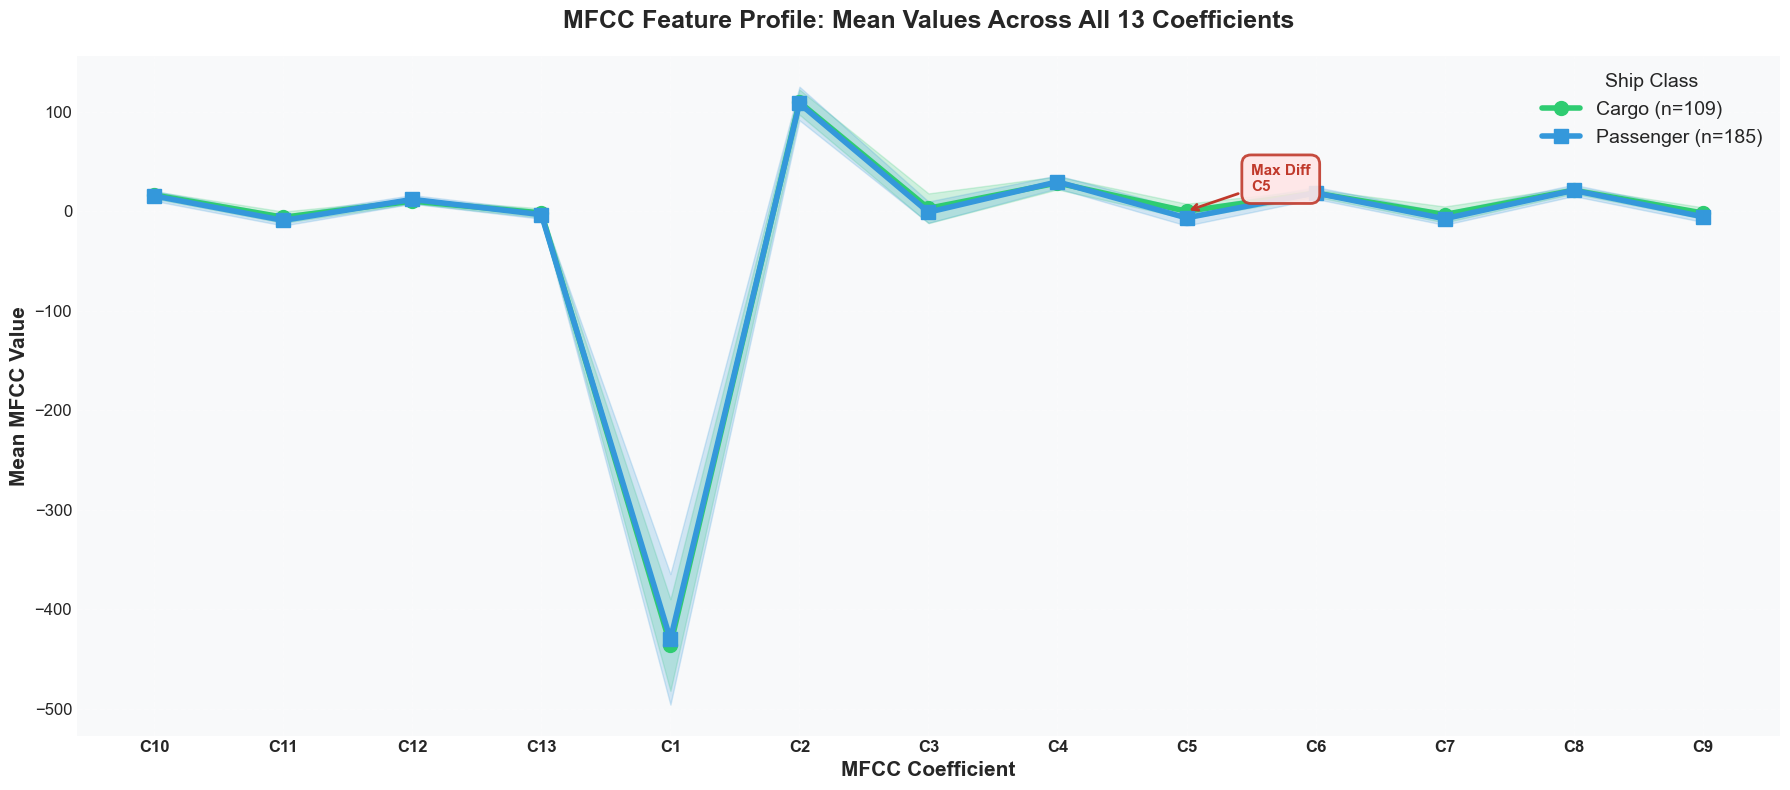


✓ MFCC LINE PLOT VISUALIZATION SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/27_mfcc_mean_per_class_lineplot.png

✓ MFCC LINE PLOT SUMMARY:
Coefficient     Cargo Mean      Passenger Mean  Difference     
C10             16.5870         15.6107         0.9763         
C11             -5.7984         -8.9729         3.1745         
C12             10.4025         12.1743         1.7718         
C13             -1.5025         -3.1873         1.6848         
C1              -435.9597       -430.2637       5.6960         
C2              109.9883        108.6134        1.3749         
C3              3.2078          -0.7254         3.9332         
C4              28.7121         29.8186         1.1065         
C5              0.2905          -6.4210         6.7115         
C6              18.4690         18.6455         0.1766         
C7              -3.0518         -7.2920         4.2401         
C8              21.2754         21.22

In [17]:
# Cell 27: Mean MFCC Per Class - Line Plot
# Purpose: Show MFCC feature progression across all 13 coefficients
# Focus: Mean values with confidence intervals for each class

print("\n" + "="*80)
print("CELL 27: MEAN MFCC PER CLASS (LINE PLOT)")
print("="*80)

if 'df_mfcc' not in locals():
    print("⚠️ ERROR: df_mfcc not found. Run Cell 24 first.")
else:
    print(f"\n✓ MEAN MFCC LINE PLOT DATA:")
    cargo_mfcc = df_mfcc[df_mfcc['class'] == 'Cargo']
    passenger_mfcc = df_mfcc[df_mfcc['class'] == 'Passenger']
    
    print(f"  Cargo recordings: {len(cargo_mfcc)}")
    print(f"  Passenger recordings: {len(passenger_mfcc)}")
    
    # Extract all 13 MFCC coefficients
    mfcc_cols = [col for col in df_mfcc.columns if col.startswith('mfcc_') and '_mean' in col]
    mfcc_cols = sorted(mfcc_cols)
    print(f"  MFCC columns found: {len(mfcc_cols)}")
    
    # Prepare data for line plot
    cargo_means = []
    cargo_stds = []
    passenger_means = []
    passenger_stds = []
    
    coeff_labels = []
    coeff_numbers = []
    
    for col in mfcc_cols:
        # Get means and stds
        cargo_means.append(cargo_mfcc[col].mean())
        cargo_stds.append(cargo_mfcc[col].std())
        passenger_means.append(passenger_mfcc[col].mean())
        passenger_stds.append(passenger_mfcc[col].std())
        
        # Extract coefficient number
        parts = col.split('_')
        coeff_num = int(parts[1][1:])
        coeff_numbers.append(coeff_num)
        coeff_labels.append(f'C{coeff_num}')
    
    cargo_means = np.array(cargo_means)
    cargo_stds = np.array(cargo_stds)
    passenger_means = np.array(passenger_means)
    passenger_stds = np.array(passenger_stds)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(18, 8))
    fig.patch.set_facecolor('#ffffff')
    
    # Plot lines with confidence intervals
    cargo_color = '#2ecc71'
    passenger_color = '#3498db'
    
    x_pos = np.arange(len(coeff_labels))
    
    # Plot Cargo
    ax.plot(x_pos, cargo_means, color=cargo_color, linewidth=4, marker='o', 
            markersize=10, label='Cargo (n=109)', zorder=3)
    ax.fill_between(x_pos, cargo_means - cargo_stds, cargo_means + cargo_stds, 
                     color=cargo_color, alpha=0.2, zorder=1)
    
    # Plot Passenger
    ax.plot(x_pos, passenger_means, color=passenger_color, linewidth=4, marker='s', 
            markersize=10, label='Passenger (n=185)', zorder=3)
    ax.fill_between(x_pos, passenger_means - passenger_stds, passenger_means + passenger_stds, 
                     color=passenger_color, alpha=0.2, zorder=1)
    
    # Styling
    ax.set_xlabel('MFCC Coefficient', fontsize=15, fontweight='bold')
    ax.set_ylabel('Mean MFCC Value', fontsize=15, fontweight='bold')
    ax.set_title('MFCC Feature Profile: Mean Values Across All 13 Coefficients', 
                 fontsize=18, fontweight='bold', pad=20)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(coeff_labels, fontsize=13, fontweight='bold')
    ax.tick_params(labelsize=12)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    
    # Legend
    ax.legend(fontsize=14, loc='best', framealpha=0.95, edgecolor='#2c3e50', 
             title='Ship Class', title_fontsize=14)
    
    # Background color
    ax.set_facecolor('#f8f9fa')
    
    # Add annotations for key differences
    differences = np.abs(cargo_means - passenger_means)
    max_diff_idx = np.argmax(differences)
    
    # Highlight maximum difference
    ax.annotate(f'Max Diff\nC{coeff_numbers[max_diff_idx]}',
                xy=(x_pos[max_diff_idx], cargo_means[max_diff_idx]),
                xytext=(x_pos[max_diff_idx] + 0.5, cargo_means[max_diff_idx] + 20),
                fontsize=11, fontweight='bold', color='#c0392b',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#ffe6e6', 
                         edgecolor='#c0392b', linewidth=2, alpha=0.9),
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2))
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/27_mfcc_mean_per_class_lineplot.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ MFCC LINE PLOT VISUALIZATION SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/27_mfcc_mean_per_class_lineplot.png")
    print(f"\n✓ MFCC LINE PLOT SUMMARY:")
    print(f"{'Coefficient':<15} {'Cargo Mean':<15} {'Passenger Mean':<15} {'Difference':<15}")
    print("="*60)
    for label, cargo_val, passenger_val in zip(coeff_labels, cargo_means, passenger_means):
        diff = abs(cargo_val - passenger_val)
        print(f"{label:<15} {cargo_val:<15.4f} {passenger_val:<15.4f} {diff:<15.4f}")
    
    print(f"\n✓ KEY FINDINGS:")
    print(f"  Maximum difference at: C{coeff_numbers[max_diff_idx]}")
    print(f"  Difference magnitude: {differences[max_diff_idx]:.4f}")

print("\n" + "="*80)

In [18]:
# Cell 28: CHROMA (CHROMATIC PITCH) FEATURE EXTRACTION (FIXED v3)
# Purpose: Extract Chroma features from validated recordings

print("\n" + "="*80)
print("CELL 28: CHROMA (CHROMATIC PITCH) FEATURE EXTRACTION")
print("="*80)

if 'audio_files' not in locals() or 'df_meta' not in locals():
    print("⚠️ ERROR: Phase 1 data not found. Run Cell 1 first.")
else:
    print(f"\n✓ CHROMA DEFINITION & METHOD:")
    print(f"  Chroma = Chromatic pitch features")
    print(f"  Definition: Energy distribution across 12 pitch classes")
    print(f"  Ship relevance: Harmonic content of engine signatures")
    print(f"  Extraction: Per-frame Chroma from STFT magnitude")
    print(f"  Bins: 12 (standard chromatic scale: C, C#, D, D#, E, F, F#, G, G#, A, A#, B)")
    print(f"  Aggregation per bin: mean, std, max, min, median")
    print(f"  Total features: 12 × 5 stats = 60 features")
    
    print(f"\n✓ PROCESSING {len(audio_files)} VALIDATED RECORDINGS:")
    
    chroma_features = []
    sr = 32000  # Sampling rate
    
    for idx in range(len(audio_files)):
        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(audio_files)} recordings")
        
        try:
            # Extract audio array and class from dictionary
            audio = audio_files[idx]['audio'].astype(np.float32)
            ship_class = audio_files[idx]['class']
            
            # Extract Chroma features
            chroma = librosa.feature.chroma_stft(y=audio, sr=sr, hop_length=512)
            
            # Aggregate statistics for each of 12 chroma bins
            feature_dict = {'index': idx, 'class': ship_class}
            
            for bin_idx in range(12):
                bin_data = chroma[bin_idx, :]
                feature_dict[f'chroma_b{bin_idx+1}_mean'] = bin_data.mean()
                feature_dict[f'chroma_b{bin_idx+1}_std'] = bin_data.std()
                feature_dict[f'chroma_b{bin_idx+1}_max'] = bin_data.max()
                feature_dict[f'chroma_b{bin_idx+1}_min'] = bin_data.min()
                feature_dict[f'chroma_b{bin_idx+1}_median'] = np.median(bin_data)
            
            chroma_features.append(feature_dict)
        
        except Exception as e:
            print(f"  ⚠️ Error processing index {idx}: {str(e)}")
    
    # Create DataFrame
    df_chroma = pd.DataFrame(chroma_features)
    print(f"\n✓ CHROMA EXTRACTION RESULTS:")
    print(f"  Successfully processed: {len(df_chroma)}/{len(audio_files)}")
    print(f"  Expected: {len(audio_files)}")
    print(f"  Failed: {len(audio_files) - len(df_chroma)}")
    
    if len(df_chroma) > 0:
        # Display sample statistics
        print(f"\n✓ CHROMA FEATURE STATISTICS:")
        chroma_mean_cols = [col for col in df_chroma.columns if '_mean' in col]
        for col in chroma_mean_cols[:3]:
            print(f"  {col}: μ={df_chroma[col].mean():.6f}, σ={df_chroma[col].std():.6f}")
        
        print(f"\n✓ CHROMA FEATURE EXTRACTION COMPLETE")
    else:
        print(f"\n⚠️ No chroma features extracted. Check audio format.")

print("\n" + "="*80)


CELL 28: CHROMA (CHROMATIC PITCH) FEATURE EXTRACTION

✓ CHROMA DEFINITION & METHOD:
  Chroma = Chromatic pitch features
  Definition: Energy distribution across 12 pitch classes
  Ship relevance: Harmonic content of engine signatures
  Extraction: Per-frame Chroma from STFT magnitude
  Bins: 12 (standard chromatic scale: C, C#, D, D#, E, F, F#, G, G#, A, A#, B)
  Aggregation per bin: mean, std, max, min, median
  Total features: 12 × 5 stats = 60 features

✓ PROCESSING 294 VALIDATED RECORDINGS:
  Processed 50/294 recordings
  Processed 100/294 recordings
  Processed 150/294 recordings
  Processed 200/294 recordings
  Processed 250/294 recordings

✓ CHROMA EXTRACTION RESULTS:
  Successfully processed: 294/294
  Expected: 294
  Failed: 0

✓ CHROMA FEATURE STATISTICS:
  chroma_b1_mean: μ=0.850099, σ=0.108059
  chroma_b2_mean: μ=0.850464, σ=0.101379
  chroma_b3_mean: μ=0.831994, σ=0.097599

✓ CHROMA FEATURE EXTRACTION COMPLETE




CELL 29: CHROMA BOXPLOT COMPARISON (ALL 12 PITCH BINS)

✓ CHROMA BOXPLOT DATA:
  Cargo recordings: 109
  Passenger recordings: 185
  CHROMA columns found: 12


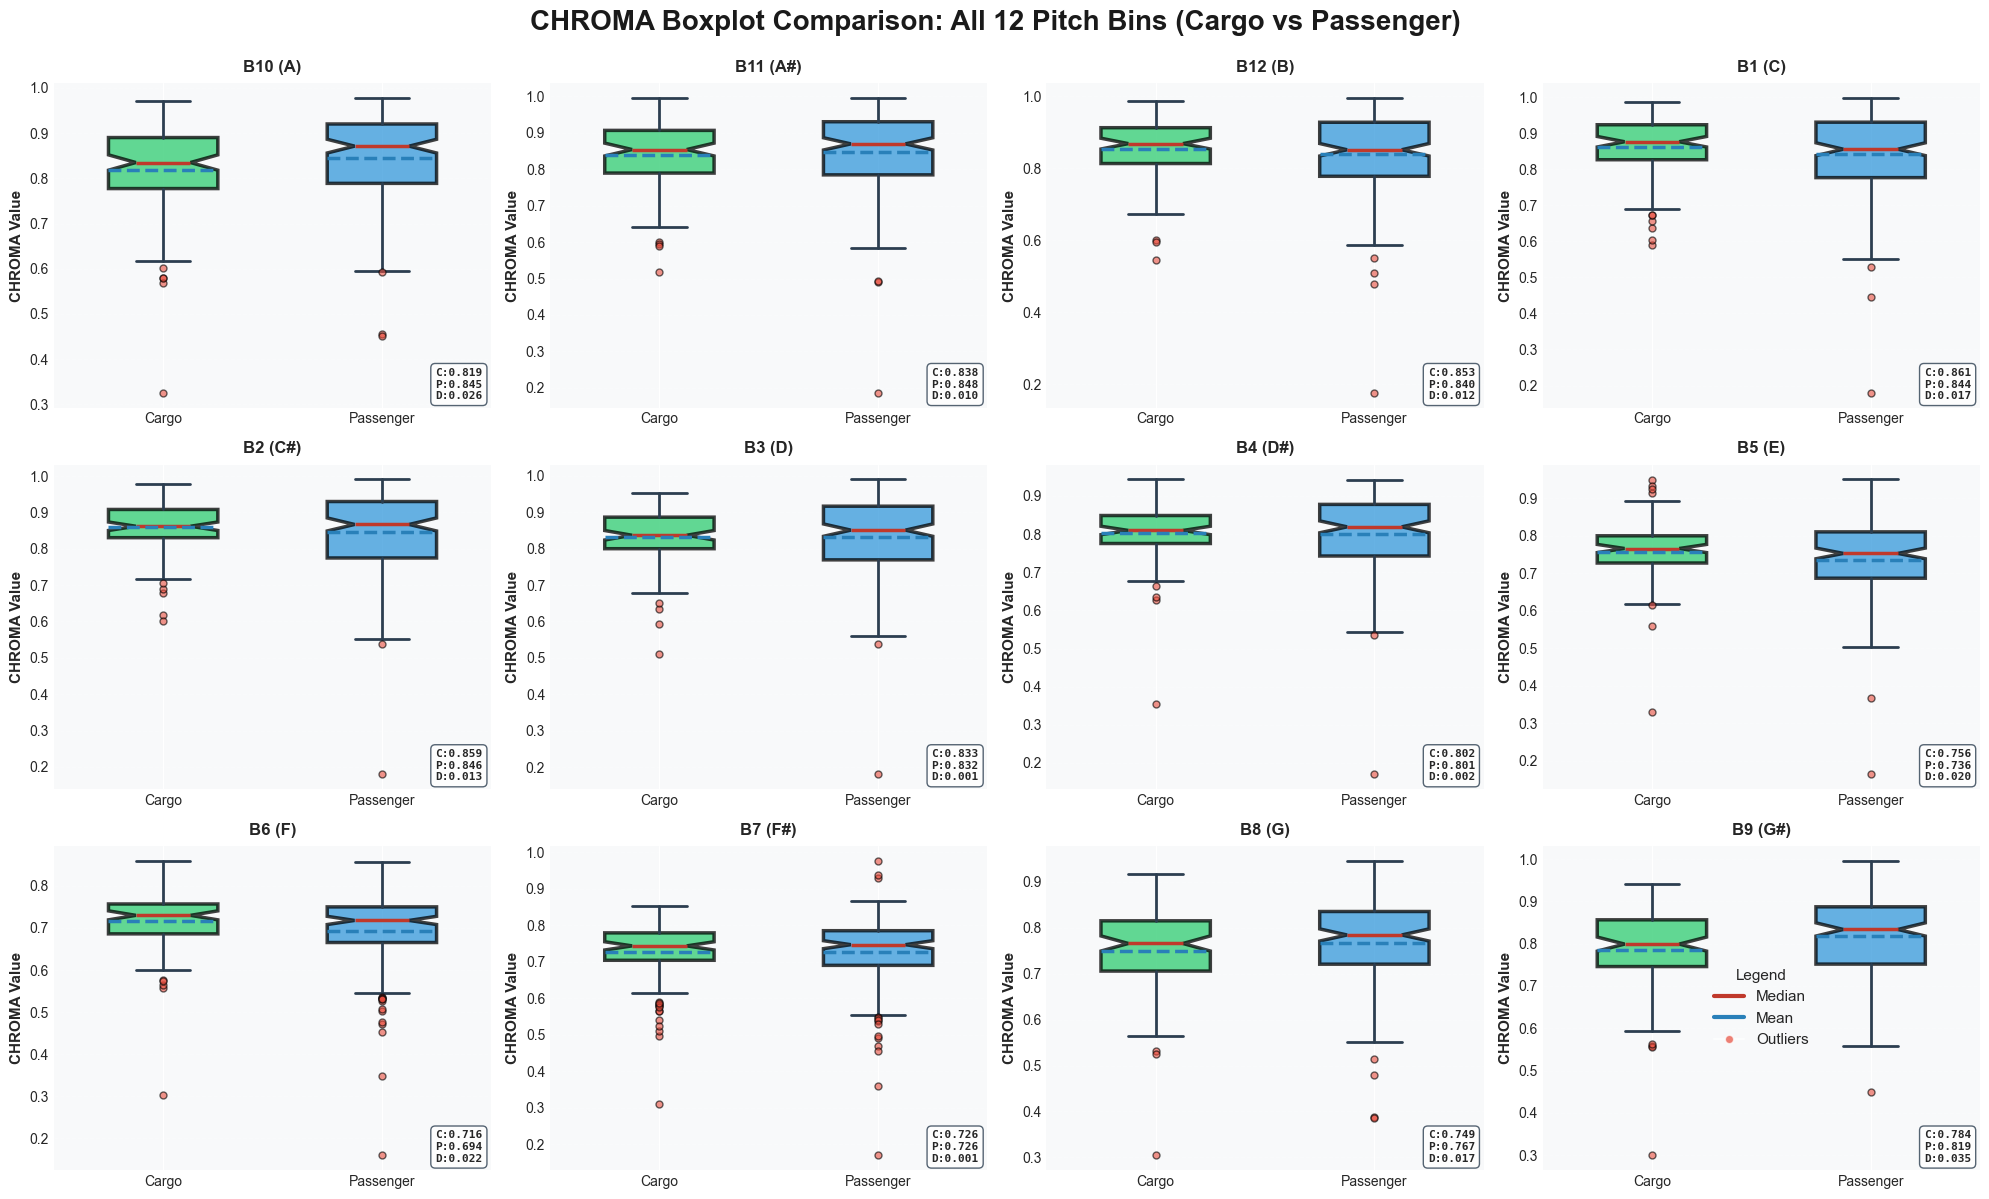


✓ CHROMA BOXPLOT VISUALIZATION SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/29_chroma_boxplot_comparison.png

✓ CHROMA BOXPLOT SUMMARY (All 12 Pitch Bins):
Bin      Pitch    Cargo Mean      Passenger Mean  Difference     
B10      A        0.819017        0.844594        0.025578       
B11      A#       0.837833        0.847921        0.010089       
B12      B        0.852516        0.840138        0.012377       
B1       C        0.860891        0.843741        0.017150       
B2       C#       0.858587        0.845678        0.012909       
B3       D        0.832599        0.831638        0.000962       
B4       D#       0.802193        0.800501        0.001692       
B5       E        0.756324        0.736013        0.020311       
B6       F        0.715848        0.693863        0.021985       
B7       F#       0.726179        0.725587        0.000592       
B8       G        0.749259        0.766715        0.017455    

In [19]:
# Cell 29: CHROMA Boxplot Comparison - All 12 Pitch Bins
# Purpose: Show CHROMA feature distributions for all 12 pitch classes
# Focus: All 12 CHROMA bins mean values

print("\n" + "="*80)
print("CELL 29: CHROMA BOXPLOT COMPARISON (ALL 12 PITCH BINS)")
print("="*80)

if 'df_chroma' not in locals():
    print("⚠️ ERROR: df_chroma not found. Run Cell 28 first.")
else:
    print(f"\n✓ CHROMA BOXPLOT DATA:")
    cargo_chroma = df_chroma[df_chroma['class'] == 'Cargo']
    passenger_chroma = df_chroma[df_chroma['class'] == 'Passenger']
    
    print(f"  Cargo recordings: {len(cargo_chroma)}")
    print(f"  Passenger recordings: {len(passenger_chroma)}")
    
    # Extract all 12 CHROMA bins
    chroma_cols = [col for col in df_chroma.columns if col.startswith('chroma_') and '_mean' in col]
    chroma_cols = sorted(chroma_cols)
    print(f"  CHROMA columns found: {len(chroma_cols)}")
    
    # Create figure with boxplots for all 12 CHROMA features
    fig, axes = plt.subplots(3, 4, figsize=(20, 12))
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle('CHROMA Boxplot Comparison: All 12 Pitch Bins (Cargo vs Passenger)', 
                 fontsize=20, fontweight='bold', color='#1a1a1a', y=0.995)
    
    # Color scheme
    cargo_color = '#2ecc71'
    passenger_color = '#3498db'
    
    # Flatten axes for easier iteration
    axes_flat = axes.flatten()
    
    # Legend (define once)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='#c0392b', lw=3, label='Median'),
        Line2D([0], [0], color='#2980b9', lw=3, label='Mean'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', 
               markersize=6, label='Outliers', alpha=0.7)
    ]
    
    # Pitch class names
    pitch_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    
    # Store stats for summary
    chroma_stats = []
    
    # ============================================================
    # BOXPLOTS FOR ALL 12 CHROMA BINS
    # ============================================================
    for idx, chroma_col in enumerate(chroma_cols):
        ax = axes_flat[idx]
        
        # Extract bin number from column name
        # Expected format: 'chroma_b1_mean', 'chroma_b2_mean', etc.
        parts = chroma_col.split('_')
        bin_num = int(parts[1][1:])
        pitch_name = pitch_names[bin_num - 1]
        
        bp = ax.boxplot([cargo_chroma[chroma_col], passenger_chroma[chroma_col]], 
                         labels=['Cargo', 'Passenger'],
                         patch_artist=True,
                         widths=0.5,
                         showmeans=True,
                         meanline=True,
                         notch=True,
                         showcaps=True,
                         boxprops=dict(linewidth=2),
                         whiskerprops=dict(linewidth=2),
                         capprops=dict(linewidth=2),
                         medianprops=dict(linewidth=2.5),
                         meanprops=dict(linewidth=2.5))
        
        # Styling
        colors = [cargo_color, passenger_color]
        
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_linewidth(2.5)
            patch.set_alpha(0.75)
        
        for whisker in bp['whiskers']:
            whisker.set_linewidth(2)
            whisker.set_color('#2c3e50')
        
        for cap in bp['caps']:
            cap.set_linewidth(2)
            cap.set_color('#2c3e50')
        
        for median in bp['medians']:
            median.set_color('#c0392b')
            median.set_linewidth(2.5)
        
        for mean in bp['means']:
            mean.set_color('#2980b9')
            mean.set_linewidth(2.5)
        
        for flier in bp['fliers']:
            flier.set_markerfacecolor('#e74c3c')
            flier.set_marker('o')
            flier.set_markersize(5)
            flier.set_alpha(0.6)
        
        ax.set_ylabel('CHROMA Value', fontweight='bold', fontsize=11)
        ax.set_title(f'B{bin_num} ({pitch_name})', fontweight='bold', fontsize=12, pad=8)
        ax.grid(True, alpha=0.25, axis='y', linestyle='--', linewidth=0.8)
        ax.set_facecolor('#f8f9fa')
        ax.tick_params(labelsize=10)
        
        # Calculate statistics
        cargo_mean = cargo_chroma[chroma_col].mean()
        passenger_mean = passenger_chroma[chroma_col].mean()
        diff = abs(cargo_mean - passenger_mean)
        
        chroma_stats.append({
            'bin': f'B{bin_num}',
            'pitch': pitch_name,
            'cargo_mean': cargo_mean,
            'passenger_mean': passenger_mean,
            'difference': diff
        })
        
        # Add small stats text
        stats_mini = f"C:{cargo_mean:.3f}\nP:{passenger_mean:.3f}\nD:{diff:.3f}"
        ax.text(0.98, 0.02, stats_mini, transform=ax.transAxes,
                fontsize=8, verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffffff', 
                         edgecolor='#2c3e50', linewidth=1, alpha=0.8),
                family='monospace', fontweight='bold')
    
    # Add legend to last subplot
    axes_flat[11].legend(handles=legend_elements, fontsize=11, loc='center', 
                        framealpha=0.95, title='Legend', title_fontsize=11)
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/29_chroma_boxplot_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ CHROMA BOXPLOT VISUALIZATION SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/29_chroma_boxplot_comparison.png")
    print(f"\n✓ CHROMA BOXPLOT SUMMARY (All 12 Pitch Bins):")
    print(f"{'Bin':<8} {'Pitch':<8} {'Cargo Mean':<15} {'Passenger Mean':<15} {'Difference':<15}")
    print("="*61)
    for stat in chroma_stats:
        print(f"{stat['bin']:<8} {stat['pitch']:<8} {stat['cargo_mean']:<15.6f} {stat['passenger_mean']:<15.6f} {stat['difference']:<15.6f}")

print("\n" + "="*80)


CELL 30: CHROMA HEATMAP (ALL 12 PITCH BINS)

✓ CHROMA HEATMAP DATA:
  Cargo recordings: 109
  Passenger recordings: 185
  CHROMA columns found: 12


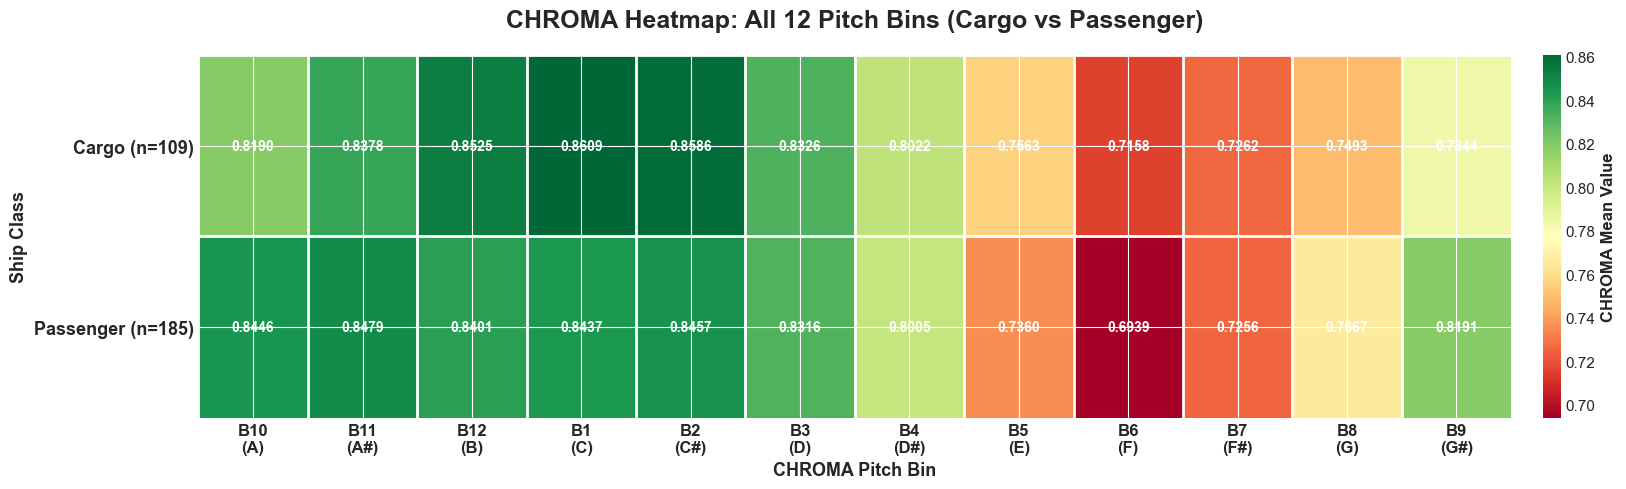


✓ CHROMA HEATMAP VISUALIZATION SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/30_chroma_heatmap.png

✓ CHROMA HEATMAP SUMMARY:
Bin      Pitch    Cargo Mean      Passenger Mean  Difference     
B1       C        0.819017        0.844594        0.025578       
B2       C#       0.837833        0.847921        0.010089       
B3       D        0.852516        0.840138        0.012377       
B4       D#       0.860891        0.843741        0.017150       
B5       E        0.858587        0.845678        0.012909       
B6       F        0.832599        0.831638        0.000962       
B7       F#       0.802193        0.800501        0.001692       
B8       G        0.756324        0.736013        0.020311       
B9       G#       0.715848        0.693863        0.021985       
B10      A        0.726179        0.725587        0.000592       
B11      A#       0.749259        0.766715        0.017455       
B12      B        0.784403 

In [20]:
# Cell 30: CHROMA Heatmap - All 12 Pitch Bins
# Purpose: Show CHROMA feature distributions as heatmap for easy comparison
# Focus: Mean values of all 12 CHROMA pitch bins side-by-side

print("\n" + "="*80)
print("CELL 30: CHROMA HEATMAP (ALL 12 PITCH BINS)")
print("="*80)

if 'df_chroma' not in locals():
    print("⚠️ ERROR: df_chroma not found. Run Cell 28 first.")
else:
    print(f"\n✓ CHROMA HEATMAP DATA:")
    cargo_chroma = df_chroma[df_chroma['class'] == 'Cargo']
    passenger_chroma = df_chroma[df_chroma['class'] == 'Passenger']
    
    print(f"  Cargo recordings: {len(cargo_chroma)}")
    print(f"  Passenger recordings: {len(passenger_chroma)}")
    
    # Extract all 12 CHROMA bins
    chroma_cols = [col for col in df_chroma.columns if col.startswith('chroma_') and '_mean' in col]
    chroma_cols = sorted(chroma_cols)
    print(f"  CHROMA columns found: {len(chroma_cols)}")
    
    # Prepare data for heatmap
    # Get mean values for each bin and class
    cargo_means = [cargo_chroma[col].mean() for col in chroma_cols]
    passenger_means = [passenger_chroma[col].mean() for col in chroma_cols]
    
    # Pitch class names
    pitch_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    
    # Extract bin numbers for labels
    bin_labels = []
    for col in chroma_cols:
        parts = col.split('_')
        bin_num = int(parts[1][1:])
        bin_labels.append(f'B{bin_num}\n({pitch_names[bin_num - 1]})')
    
    # Create heatmap data (2 rows: Cargo, Passenger)
    heatmap_data = np.array([cargo_means, passenger_means])
    
    # Create figure
    fig, ax = plt.subplots(figsize=(18, 5))
    fig.patch.set_facecolor('#ffffff')
    
    # Create heatmap
    im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', interpolation='nearest')
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(bin_labels)))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(bin_labels, fontsize=12, fontweight='bold')
    ax.set_yticklabels(['Cargo (n=109)', 'Passenger (n=185)'], fontsize=13, fontweight='bold')
    
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center", rotation_mode="anchor")
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label('CHROMA Mean Value', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=11)
    
    # Add text annotations
    for i in range(2):
        for j in range(len(bin_labels)):
            value = heatmap_data[i, j]
            text_color = 'white' if abs(value) > np.max(np.abs(heatmap_data)) * 0.5 else 'black'
            text = ax.text(j, i, f'{value:.4f}',
                          ha="center", va="center", color=text_color,
                          fontsize=10, fontweight='bold')
    
    ax.set_title('CHROMA Heatmap: All 12 Pitch Bins (Cargo vs Passenger)', 
                 fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('CHROMA Pitch Bin', fontsize=13, fontweight='bold')
    ax.set_ylabel('Ship Class', fontsize=13, fontweight='bold')
    
    # Add grid
    ax.set_xticks(np.arange(len(bin_labels)) - 0.5, minor=True)
    ax.set_yticks(np.arange(2) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", size=0)
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/30_chroma_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ CHROMA HEATMAP VISUALIZATION SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/30_chroma_heatmap.png")
    print(f"\n✓ CHROMA HEATMAP SUMMARY:")
    print(f"{'Bin':<8} {'Pitch':<8} {'Cargo Mean':<15} {'Passenger Mean':<15} {'Difference':<15}")
    print("="*61)
    for idx, (cargo_val, passenger_val) in enumerate(zip(cargo_means, passenger_means)):
        bin_num = idx + 1
        pitch = pitch_names[idx]
        diff = abs(cargo_val - passenger_val)
        print(f"B{bin_num:<7} {pitch:<8} {cargo_val:<15.6f} {passenger_val:<15.6f} {diff:<15.6f}")

print("\n" + "="*80)


CELL 31: MEAN CHROMA PER CLASS (LINE PLOT)

✓ MEAN CHROMA LINE PLOT DATA:
  Cargo recordings: 109
  Passenger recordings: 185
  CHROMA columns found: 12


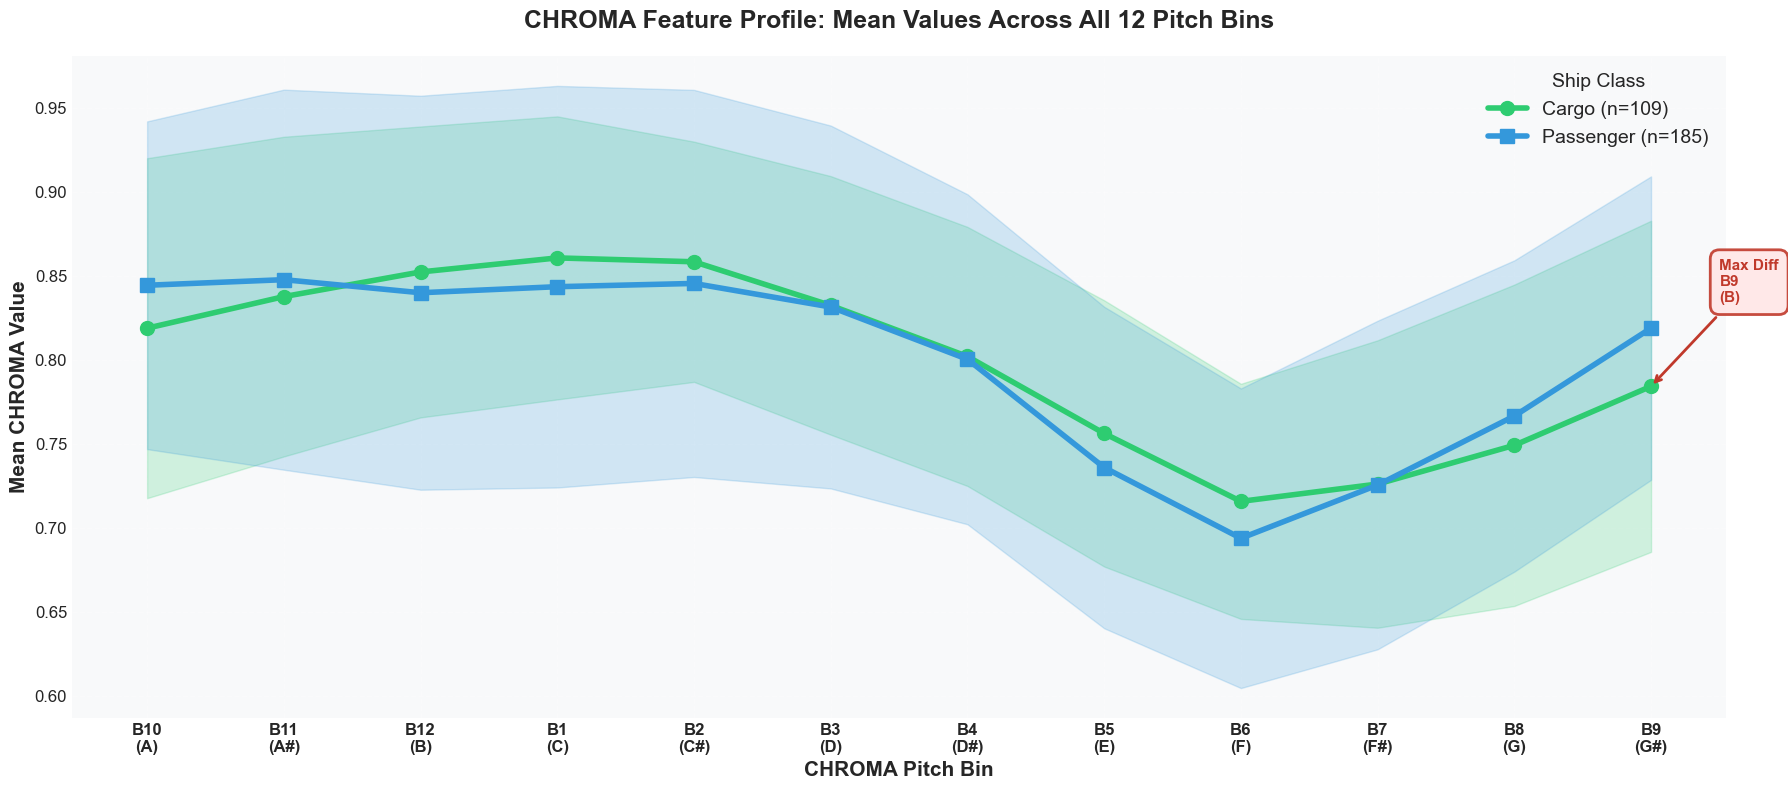


✓ CHROMA LINE PLOT VISUALIZATION SAVED:
  Location: C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features/31_chroma_mean_per_class_lineplot.png

✓ CHROMA LINE PLOT SUMMARY:
Bin      Pitch    Cargo Mean      Passenger Mean  Difference     
B10      C        0.819017        0.844594        0.025578       
B11      C#       0.837833        0.847921        0.010089       
B12      D        0.852516        0.840138        0.012377       
B1       D#       0.860891        0.843741        0.017150       
B2       E        0.858587        0.845678        0.012909       
B3       F        0.832599        0.831638        0.000962       
B4       F#       0.802193        0.800501        0.001692       
B5       G        0.756324        0.736013        0.020311       
B6       G#       0.715848        0.693863        0.021985       
B7       A        0.726179        0.725587        0.000592       
B8       A#       0.749259        0.766715        0.017455       
B9     

In [21]:
# Cell 31: Mean CHROMA Per Class - Line Plot
# Purpose: Show CHROMA feature progression across all 12 pitch bins
# Focus: Mean values with confidence intervals for each class

print("\n" + "="*80)
print("CELL 31: MEAN CHROMA PER CLASS (LINE PLOT)")
print("="*80)

if 'df_chroma' not in locals():
    print("⚠️ ERROR: df_chroma not found. Run Cell 28 first.")
else:
    print(f"\n✓ MEAN CHROMA LINE PLOT DATA:")
    cargo_chroma = df_chroma[df_chroma['class'] == 'Cargo']
    passenger_chroma = df_chroma[df_chroma['class'] == 'Passenger']
    
    print(f"  Cargo recordings: {len(cargo_chroma)}")
    print(f"  Passenger recordings: {len(passenger_chroma)}")
    
    # Extract all 12 CHROMA bins
    chroma_cols = [col for col in df_chroma.columns if col.startswith('chroma_') and '_mean' in col]
    chroma_cols = sorted(chroma_cols)
    print(f"  CHROMA columns found: {len(chroma_cols)}")
    
    # Prepare data for line plot
    cargo_means = []
    cargo_stds = []
    passenger_means = []
    passenger_stds = []
    
    bin_labels = []
    bin_numbers = []
    
    pitch_names_full = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    
    for col in chroma_cols:
        # Get means and stds
        cargo_means.append(cargo_chroma[col].mean())
        cargo_stds.append(cargo_chroma[col].std())
        passenger_means.append(passenger_chroma[col].mean())
        passenger_stds.append(passenger_chroma[col].std())
        
        # Extract bin number
        parts = col.split('_')
        bin_num = int(parts[1][1:])
        bin_numbers.append(bin_num)
        bin_labels.append(f'B{bin_num}\n({pitch_names_full[bin_num - 1]})')
    
    cargo_means = np.array(cargo_means)
    cargo_stds = np.array(cargo_stds)
    passenger_means = np.array(passenger_means)
    passenger_stds = np.array(passenger_stds)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(18, 8))
    fig.patch.set_facecolor('#ffffff')
    
    # Plot lines with confidence intervals
    cargo_color = '#2ecc71'
    passenger_color = '#3498db'
    
    x_pos = np.arange(len(bin_labels))
    
    # Plot Cargo
    ax.plot(x_pos, cargo_means, color=cargo_color, linewidth=4, marker='o', 
            markersize=10, label='Cargo (n=109)', zorder=3)
    ax.fill_between(x_pos, cargo_means - cargo_stds, cargo_means + cargo_stds, 
                     color=cargo_color, alpha=0.2, zorder=1)
    
    # Plot Passenger
    ax.plot(x_pos, passenger_means, color=passenger_color, linewidth=4, marker='s', 
            markersize=10, label='Passenger (n=185)', zorder=3)
    ax.fill_between(x_pos, passenger_means - passenger_stds, passenger_means + passenger_stds, 
                     color=passenger_color, alpha=0.2, zorder=1)
    
    # Styling
    ax.set_xlabel('CHROMA Pitch Bin', fontsize=15, fontweight='bold')
    ax.set_ylabel('Mean CHROMA Value', fontsize=15, fontweight='bold')
    ax.set_title('CHROMA Feature Profile: Mean Values Across All 12 Pitch Bins', 
                 fontsize=18, fontweight='bold', pad=20)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(bin_labels, fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=12)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    
    # Legend
    ax.legend(fontsize=14, loc='best', framealpha=0.95, edgecolor='#2c3e50', 
             title='Ship Class', title_fontsize=14)
    
    # Background color
    ax.set_facecolor('#f8f9fa')
    
    # Add annotations for key differences
    differences = np.abs(cargo_means - passenger_means)
    max_diff_idx = np.argmax(differences)
    
    # Highlight maximum difference
    ax.annotate(f'Max Diff\nB{bin_numbers[max_diff_idx]}\n({pitch_names_full[max_diff_idx]})',
                xy=(x_pos[max_diff_idx], cargo_means[max_diff_idx]),
                xytext=(x_pos[max_diff_idx] + 0.5, cargo_means[max_diff_idx] + 0.05),
                fontsize=11, fontweight='bold', color='#c0392b',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#ffe6e6', 
                         edgecolor='#c0392b', linewidth=2, alpha=0.9),
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2))
    
    plt.tight_layout()
    plt.savefig(f'{PHASE2_OUTPUT}/31_chroma_mean_per_class_lineplot.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ CHROMA LINE PLOT VISUALIZATION SAVED:")
    print(f"  Location: {PHASE2_OUTPUT}/31_chroma_mean_per_class_lineplot.png")
    print(f"\n✓ CHROMA LINE PLOT SUMMARY:")
    print(f"{'Bin':<8} {'Pitch':<8} {'Cargo Mean':<15} {'Passenger Mean':<15} {'Difference':<15}")
    print("="*61)
    for idx, (cargo_val, passenger_val) in enumerate(zip(cargo_means, passenger_means)):
        bin_num = bin_numbers[idx]
        pitch = pitch_names_full[idx]
        diff = abs(cargo_val - passenger_val)
        print(f"B{bin_num:<7} {pitch:<8} {cargo_val:<15.6f} {passenger_val:<15.6f} {diff:<15.6f}")
    
    print(f"\n✓ KEY FINDINGS:")
    print(f"  Maximum difference at: B{bin_numbers[max_diff_idx]} ({pitch_names_full[max_diff_idx]})")
    print(f"  Difference magnitude: {differences[max_diff_idx]:.6f}")

print("\n" + "="*80)

In [22]:
# Add this at the END of Phase2_FeatureExtraction.ipynb
# Save all feature dataframes as pickle files for Phase 3

import pickle
import os

print("\n" + "="*80)
print("SAVING PHASE 2 FEATURE DATAFRAMES FOR PHASE 3")
print("="*80)

PHASE2_OUTPUT = r'C:\Users\Syed Ittisaf Tazwar\Desktop\DeepShip_Project_V2\outputs\Phase2_features'
os.makedirs(PHASE2_OUTPUT, exist_ok=True)

# Save ZCR dataframe
with open(f'{PHASE2_OUTPUT}/df_zcr.pkl', 'wb') as f:
    pickle.dump(df_zcr, f)
print(f"✓ Saved df_zcr.pkl ({len(df_zcr)} records, {len(df_zcr.columns)} columns)")

# Save RMS dataframe
with open(f'{PHASE2_OUTPUT}/df_rms.pkl', 'wb') as f:
    pickle.dump(df_rms, f)
print(f"✓ Saved df_rms.pkl ({len(df_rms)} records, {len(df_rms.columns)} columns)")

# Save MFCC dataframe
with open(f'{PHASE2_OUTPUT}/df_mfcc.pkl', 'wb') as f:
    pickle.dump(df_mfcc, f)
print(f"✓ Saved df_mfcc.pkl ({len(df_mfcc)} records, {len(df_mfcc.columns)} columns)")

# Save CHROMA dataframe
with open(f'{PHASE2_OUTPUT}/df_chroma.pkl', 'wb') as f:
    pickle.dump(df_chroma, f)
print(f"✓ Saved df_chroma.pkl ({len(df_chroma)} records, {len(df_chroma.columns)} columns)")

print("\n" + "="*80)
print("✓ ALL FEATURE DATAFRAMES SAVED FOR PHASE 3")
print("="*80 + "\n")


SAVING PHASE 2 FEATURE DATAFRAMES FOR PHASE 3
✓ Saved df_zcr.pkl (294 records, 10 columns)
✓ Saved df_rms.pkl (294 records, 12 columns)
✓ Saved df_mfcc.pkl (294 records, 68 columns)
✓ Saved df_chroma.pkl (294 records, 62 columns)

✓ ALL FEATURE DATAFRAMES SAVED FOR PHASE 3

